##Objective:

###To introduce the Time series analysis and Forecasting for improvement in logistic operations and introducing time and date factors for predicting shipments within a day with several dates.

In [ ]:
import pandas as pd
import numpy as np
import scipy as sc
import math
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
import sklearn as skl
import tensorflow as tf
from tensorflow.keras import models, layers

In [ ]:
sent= pd.read_csv("/content/sentiment_complete.csv")

In [ ]:
ts = pd.read_csv("/content/DIC-Outward MIS Report A+B+C (2024 TO 2025) New -   18_03_2025.csv")

In [ ]:
ts1= pd.read_csv("/content/DIC-Outward MIS Report A+B+C (2024 TO 2025) New - 19_03_2025.csv")

In [ ]:
ts= pd.concat([ts, ts1])

In [ ]:
sent.head()

,OrderID,Date_x,Country_x,City_x,Latitude_x,Longtitude_x,ProductCategoryName_x,ProductID_x,Product_x,Quantity_x,...,year,Month,Day,Year_Month,Location_ID,Sentiment,Class,Product_detail_y,Revenue_y,Price
0,order-00e5d11e-2c62-4f24-8a36-b5a9a7f89181,NaT,3,0,0.0000,0.0000,4,0,12,NaN,...,NaN,NaN,NaN,NaT,NaN,86.0,3,NaN,NaN,NaN
1,order-0124ec8d-2fa3-432e-802c-15cf09e66f2f,NaT,3,5,NaN,NaN,4,0,12,NaN,...,2021.0,1.0,Mon,2021-01-01,"United States, San Diego",40.0,0,Stilettos (product-7bef3e02-033c-4259-93da-a25...,203.68,NaN
2,order-02d3f33b-cf80-4c77-97dc-9c0997d93958,NaT,3,5,NaN,NaN,4,0,12,NaN,...,2021.0,1.0,Mon,2021-01-01,"Portugal, Lisbon",86.0,2,Brogues (product-124ef52a-c7c3-48af-b315-33a14...,370.50,NaN
3,order-0320c249-8c62-4018-b23b-31e2a46858c4,2020-01-22,2,4,40.6943,-73.9249,0,3,2,7.0,...,NaN,NaN,NaN,NaT,NaN,86.0,3,NaN,NaN,NaN
4,order-03b78162-aa02-40aa-bb5d-8978e7e57f5e,NaT,3,5,NaN,NaN,4,0,12,NaN,...,2021.0,1.0,Sat,2021-01-01,"Portugal, Lisbon",87.0,2,Flats (product-f709c12a-ffe5-48b1-a3d2-f247acf...,254.21,NaN


In [ ]:
ts.head()

,S.R NO.,Lane,DISPATCHED FROM,SHIFT,GATE PASS NO.,GATE IN DATE,GATE IN TIME,DOCK IN DATE,DOCK IN TIME,DOCK OUT DATE,...,Description,SIZE,KILO METER,Adhoc/Regular,DRIVER NAME,Contact No.,Seal No.,Prealert Status,VEHICLE LOAD BY,Report Created By
0,1,LOCAL,DEL/DIC-DEL/SRF-DEL/NDP-Phase3NoidaHub_DEL_PL-...,A,8813527.0,18-Mar-2025,8:20,18-Mar-2025,8:35,18-Mar-2025,...,DIC,22 FT,93056,REGULAR,PUNIT,8.920699e+09,WE 15006107/15006101,DONE,ANUJ,SAURABH SAINI
1,2,LOCAL,DEL/DIC-DEL/SRF-DEL/NDP-Phase3NoidaHub_DEL_PL-...,A,8813527.0,18-Mar-2025,8:20,18-Mar-2025,8:35,18-Mar-2025,...,DIC,22 FT,93056,REGULAR,PUNIT,8.920699e+09,WE 15006107/15006101,DONE,ANUJ,SAURABH SAINI
2,3,LOCAL,DEL/DIC-DEL/SRF-DEL/NDP-Phase3NoidaHub_DEL_PL-...,A,8813527.0,18-Mar-2025,8:20,18-Mar-2025,8:35,18-Mar-2025,...,DIC,22 FT,93056,REGULAR,PUNIT,8.920699e+09,WE 15006107/15006101,DONE,ANUJ,SAURABH SAINI
3,4,LOCAL,DEL/DIC-DEL/SRF-DEL/NDP-Phase3NoidaHub_DEL_PL-...,A,8813527.0,18-Mar-2025,8:20,18-Mar-2025,8:35,18-Mar-2025,...,DIC,22 FT,93056,REGULAR,PUNIT,8.920699e+09,WE 15006107/15006101,DONE,ANUJ,SAURABH SAINI
4,5,LOCAL,DEL/DIC-DEL/SRF-DEL/NDP-Phase3NoidaHub_DEL_PL-...,A,8813527.0,18-Mar-2025,8:20,18-Mar-2025,8:35,18-Mar-2025,...,DIC,22 FT,93056,REGULAR,PUNIT,8.920699e+09,WE 15006107/15006101,DONE,ANUJ,SAURABH SAINI


In [ ]:
ts.columns

Index(['S.R  NO.', 'Lane', 'DISPATCHED FROM', 'SHIFT', 'GATE PASS NO.',
       'GATE IN DATE', 'GATE IN TIME', 'DOCK IN DATE', 'DOCK IN TIME',
       'DOCK OUT DATE', 'DOCK OUT TIME', 'GATE OUT DATE', 'GATE OUT TIME',
       'CUT OFF TIME', 'COC', 'CM', 'Bag Qty\n(As Per ERP)',
       'Large Shipment \nBag(QTY)', 'IT & STOCK & EKL BAG', 'TOTAL BAGS',
       'SHIPMENT', 'WT.', 'Trip ID', 'SPILL OVER BAG DETAIL', 'Vendor Name',
       'Vehicle No', 'DOCK NO', 'Description', 'SIZE', 'KILO METER',
       'Adhoc/Regular', 'DRIVER NAME', 'Contact No.', 'Seal No.',
       'Prealert Status', 'VEHICLE LOAD BY', 'Report Created By'],
      dtype='object')

In [ ]:
ts_ = ts.sort_values(by=["CUT OFF TIME","DOCK IN TIME"],ascending= True).reset_index(drop=True)

In [ ]:
ts_["CUT OFF TIME"].head()

,CUT OFF TIME
0,10:00
1,10:00
2,10:00
3,10:00
4,10:00


Other Features based on logistics(DOCK IN TIME to reduce breach issue) as well as for prediction of "y":
1. Season 2. Working day(S/W/A/R/etc.)  3. Temperature 4. Temperature(Feels like) 5. Humidity 6. Windspeed 7. Air Quality 8. Precipitation
------------------------------------------------------------------------------
For prediction of y and to include date-time related features, one could also include along with above:

9. year 10. Month 11. Day 12. Hour, minute,seconds 11. official holiday, national holiday, company holiday, Regional holidays, etc. 12. weekday 13. weekend/non-weekend 14. shift wise holidays

In [ ]:
import plotly.express as px
# Create a line chart
fig = px.line(ts, y="CUT OFF TIME", x="KILO METER", title='CUT OFF TIME vs KILO METER')
# Display the chart
fig.show()

In [ ]:
import plotly.express as px
# Create a line chart
fig = px.line(ts, y="DOCK IN TIME", x="SIZE", title='DOCK IN TIME vs SIZE')
# Display the chart
fig.show()

In [ ]:
import plotly.express as px
# Create a line chart
fig = px.line(ts, y="DOCK IN TIME", x="SIZE", title='Bag Qty\n(As Per ERP)')
# Display the chart
fig.show()

In [ ]:
import plotly.express as px
# Create a line chart
fig = px.line(ts_, x="DOCK IN TIME", y="TOTAL BAGS", title='DOCK IN TIME vs SIZE')
# Display the chart
fig.show()

In [ ]:

#changing the format of time into proper format
ts_["CUT_OFF_TIME"]= pd.to_datetime(ts_["CUT OFF TIME"], format='mixed').dt.time

In [ ]:


# Removed problematic independent sorting of CUT_OFF_TIME column
# ts_["CUT_OFF_TIME"]= ts_["CUT_OFF_TIME"].sort_values(ascending= True)

In [ ]:
#Replacing special character
ts["CUT OFF TIME_"]= ts["CUT OFF TIME"].str.replace(";",":")

In [ ]:
#Plotting "CUTOFF TIME" vs "SHIPMENT"
import plotly.express as px
# Create a line chart
fig = px.line(ts_, x="CUT_OFF_TIME", y="SHIPMENT", title='CUT OFF TIME vs SHIPMENT')
# Display the chart
fig.show()

Here, we are considering input variable as "CUTOFF" and Target variable as"SHIPMENT". As Time series analysis requires parameters like ds and y, so we can consider it for further process.

In [ ]:
#To check for missing values
ts_.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1997 entries, 0 to 1996
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   S.R  NO.                  1997 non-null   int64  
 1   Lane                      1951 non-null   object 
 2   DISPATCHED FROM           1950 non-null   object 
 3   SHIFT                     1950 non-null   object 
 4   GATE PASS NO.             1950 non-null   object 
 5   GATE IN DATE              1950 non-null   object 
 6   GATE IN TIME              1950 non-null   object 
 7   DOCK IN DATE              1950 non-null   object 
 8   DOCK IN TIME              1950 non-null   object 
 9   DOCK OUT DATE             1950 non-null   object 
 10  DOCK OUT TIME             1950 non-null   object 
 11  GATE OUT DATE             1950 non-null   object 
 12  GATE OUT TIME             1950 non-null   object 
 13  CUT OFF TIME              1918 non-null   object 
 14  COC     


As we see that data is non-stationary, to move ahead with calculations and analysis process and further modeling process, one need to convert it into stationary form.

In [ ]:
#Starting with first order differencing
ts_["Diff1"]= ts_["SHIPMENT"].diff()
ts_["Diff1"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1997 entries, 0 to 1996
Series name: Diff1
Non-Null Count  Dtype  
--------------  -----  
1947 non-null   float64
dtypes: float64(1)
memory usage: 15.7 KB


array([[<Axes: title={'center': 'SHIPMENT'}>,
        <Axes: title={'center': 'Diff1'}>]], dtype=object)

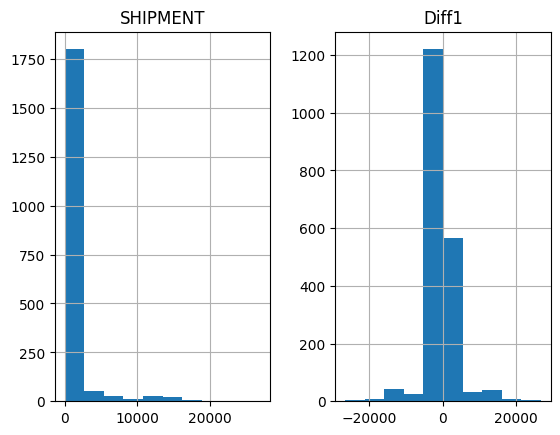

In [ ]:
#Relationship between "SHIPMENT" and "Diff1"
ts_[["SHIPMENT","Diff1"]].hist()

In [ ]:
ts_["SHIPMENT"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1997 entries, 0 to 1996
Series name: SHIPMENT
Non-Null Count  Dtype  
--------------  -----  
1949 non-null   float64
dtypes: float64(1)
memory usage: 15.7 KB


In [ ]:
#Filling missing values by interpolating with linear method
#b= ts_["Diff1"].interpolate()
ts_["Diff1_"]=ts_["Diff1"].interpolate(method="linear")
ts_["Diff1_"]= ts_["Diff1_"].fillna(0)
ts_["Diff1_"]

,Diff1_
0,0.0
1,-600.0
2,-14.0
3,515.0
4,-434.0
...,...
1992,3731.0
1993,3731.0
1994,3731.0
1995,3731.0


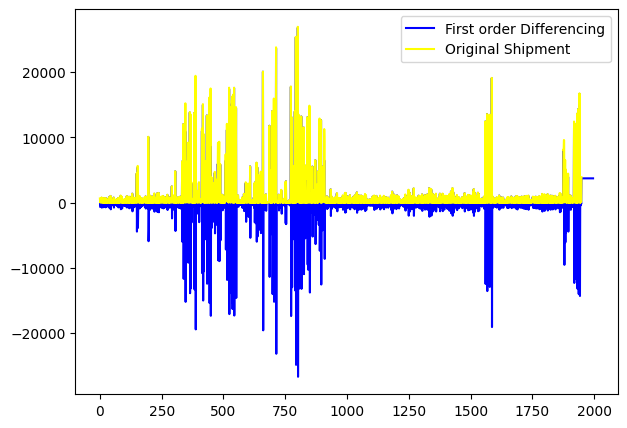

In [ ]:
#Filling missing values by interpolating with linear method
#b= ts_["Diff1"].interpolate()
ts_["Diff1_"]=ts_["Diff1"].interpolate(method="linear")

#Relationship brtween original shipment and after 1st order differencing
fig,ax= plt.subplots(figsize=(7,5))
ts_.loc[:, "Diff1_"].plot(ax=ax, color="blue", label="First order Differencing")
ts_.loc[:, "SHIPMENT"].plot(ax=ax, color="Yellow", label="Original Shipment")
plt.legend()
plt.show()


In [ ]:
#Filling missing values with 0
#ts_["Diff1"].fillna(0).head()

In [ ]:
#Plotting SHIPMENT and first order differencing after imputing with 0
ts_["Differen1"]= ts_["Diff1"].fillna(0)
ts_["Differen1"]

,Differen1
0,0.0
1,-600.0
2,-14.0
3,515.0
4,-434.0
...,...
1992,0.0
1993,0.0
1994,0.0
1995,0.0


In [ ]:
#Filling missing values by interpolating with linear method
#b= ts_["Diff1"].interpolate()
ts_["Diff1_"]=ts_["Diff1"].interpolate(method="linear")
ts_["Diff1_"].head()

,Diff1_
0,NaN
1,-600.0
2,-14.0
3,515.0
4,-434.0


<Axes: xlabel='Differen1', ylabel='Diff1_'>

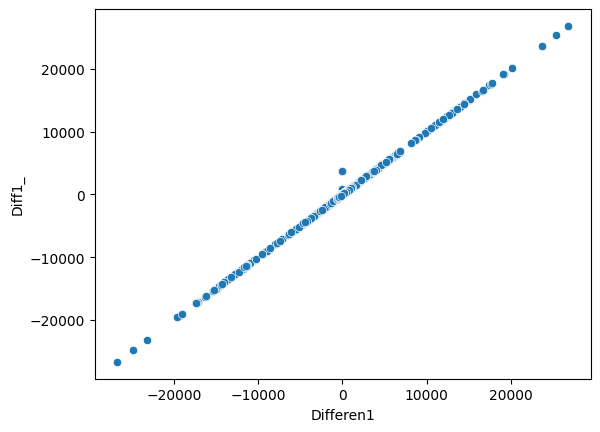

In [ ]:
#Relationship between "SHIPMENT" and "Diff1"
ts_[["Differen1","Diff1_"]]
sns.scatterplot(x="Differen1", y="Diff1_", data=ts_)

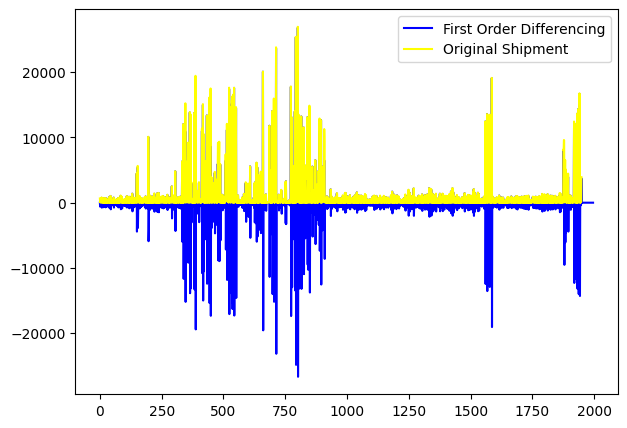

In [ ]:
#Plotting SHIPMENT and first order differencing after imputing with 0
ts_["Differen1"]= ts_["Diff1"].fillna(0)

#Relationship after Imputation wrt SHIPMENT
fig, ax= plt.subplots(figsize=(7,5))
ts_.loc[:,"Differen1"].plot(ax=ax, color="Blue", label="First Order Differencing")
ts_.loc[:,"SHIPMENT"].plot(ax=ax, color="Yellow", label="Original Shipment")
plt.legend()
plt.show()

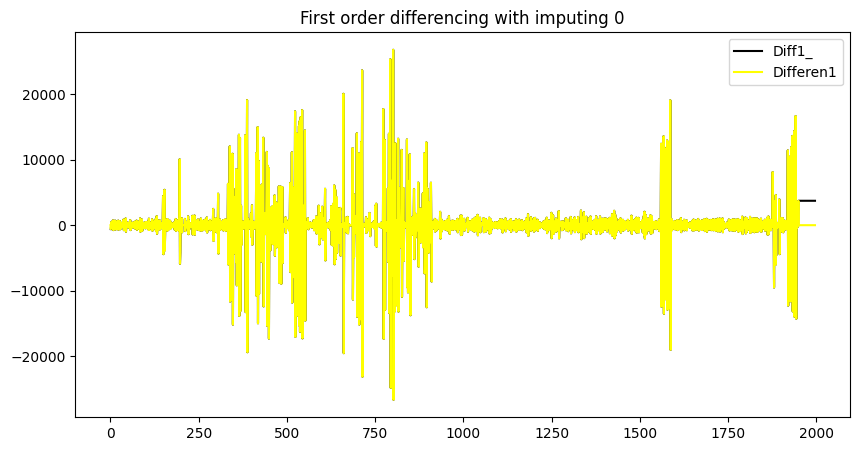

In [ ]:
#Plotting after above imputations in first order differencing
fig, ax=plt.subplots(figsize=(10,5))
ts_.loc[:,"Diff1_"].plot(ax=ax, color="Black", title="First order differencing with linear imputation")
ts_.loc[:,"Differen1"].plot(ax=ax, color="Yellow", title="First order differencing with imputing 0")
plt.legend()
plt.show()

As the initial and the last values from the above two columns(Diff1_ and Differen1) contains "NaN", one could see from above that one of them is capturing the value 0 within a specific range while other (linear interpolated) has a specific value of 3731 within that particular range.

As the value in differencing are in negative so can consider either absolute or log of the values .

In [ ]:
#SHIPMENT VS First order Differencing
ts_[["SHIPMENT","Diff1"]]

,SHIPMENT,Diff1
0,653.0,NaN
1,53.0,-600.0
2,39.0,-14.0
3,554.0,515.0
4,120.0,-434.0
...,...,...
1992,NaN,NaN
1993,NaN,NaN
1994,NaN,NaN
1995,NaN,NaN


In [ ]:
#Performing Second order Differencing
ts_["Diff2"]= ts_["Diff1"].diff()
ts_["Diff2"].head()

,Diff2
0,NaN
1,NaN
2,586.0
3,529.0
4,-949.0


array([[<Axes: title={'center': 'Differen1'}>,
        <Axes: title={'center': 'Diff2_'}>]], dtype=object)

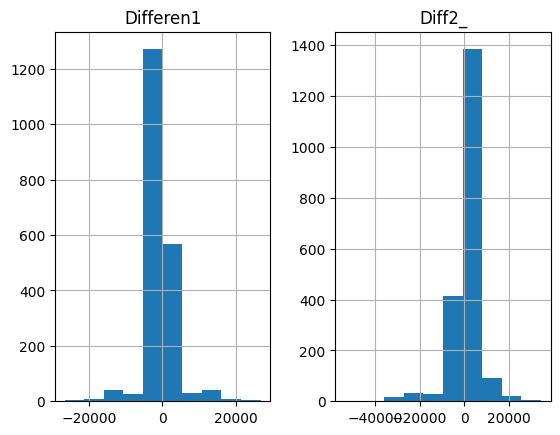

In [ ]:
#Second order Differencing
ts_["Diff2_"]=ts_["Diff2"].fillna(0)
ts_[["Differen1", "Diff2_"]].hist()

In [ ]:
#Interpretation of above visuals
ts_[["Differen1","Diff2_"]].head()

,Differen1,Diff2_
0,0.0,0.0
1,-600.0,0.0
2,-14.0,586.0
3,515.0,529.0
4,-434.0,-949.0


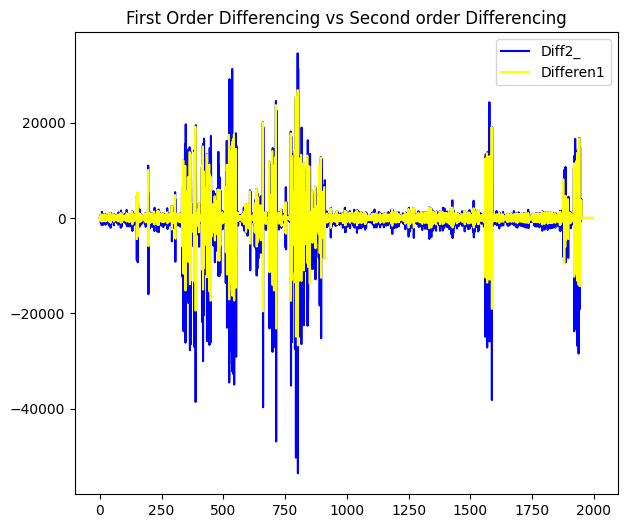

In [ ]:
#Visualizing first order differencing and second order differencing
fig, ax= plt.subplots(figsize=(7,6))
ts_.loc[:,"Diff2_"].plot(ax=ax, color="Blue")
ts_.loc[:,"Differen1"].plot(ax=ax, color="Yellow" , title="First Order Differencing vs Second order Differencing")
plt.legend()
plt.show()

From above plot,

Second Order Differencing has high values than First Order Differencing.

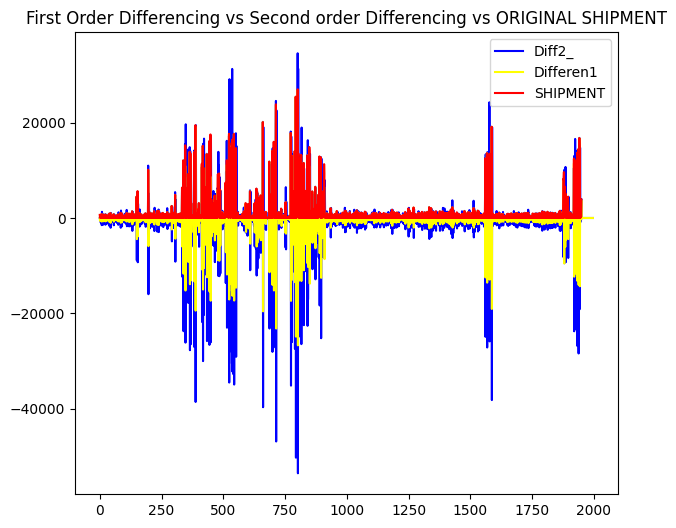

In [ ]:
#Visualizing first order differencing and second order differencing
fig, ax= plt.subplots(figsize=(7,6))
ts_.loc[:,"Diff2_"].plot(ax=ax, color="Blue")
ts_.loc[:,"Differen1"].plot(ax=ax, color="Yellow" , title="First Order Differencing vs Second order Differencing vs ORIGINAL SHIPMENT")
ts_.loc[:,"SHIPMENT"].plot(ax=ax, color="Red")
plt.legend()
plt.show()

From above,

Second order differencing captures huge range of values as compared to Original shipment.

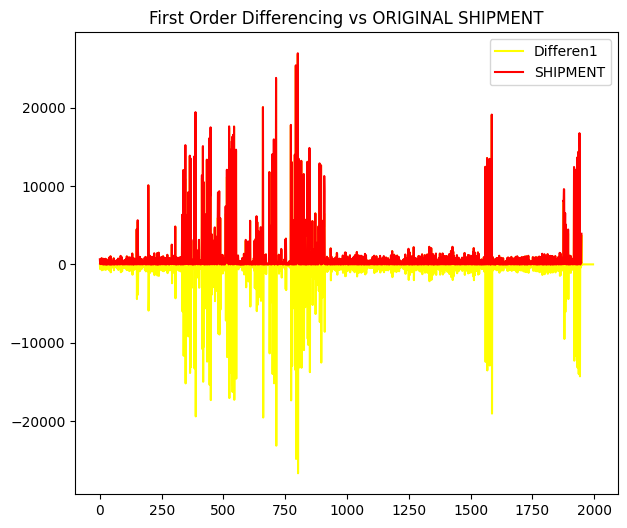

In [ ]:
#Visualizing first order differencing and second order differencing
fig, ax= plt.subplots(figsize=(7,6))
#ts_.loc[:,"Diff2_"].plot(ax=ax, color="Blue")
ts_.loc[:,"Differen1"].plot(ax=ax, color="Yellow" , title="First Order Differencing vs ORIGINAL SHIPMENT")
ts_.loc[:,"SHIPMENT"].plot(ax=ax, color="Red")
plt.legend()
plt.show()

As one can see from above,

that the Original Shipment overlaps almost with First order differencing on the positive x-axis.
Calculating higher order differencing to find relationship with Original shipment.

In [ ]:
#Third order differencing
ts_["Diff3"]= ts_["Diff2"].diff()
ts_["Diff3_"]= ts_["Diff3"].fillna(0)
ts_["Diff3_"].head()

,Diff3_
0,0.0
1,0.0
2,0.0
3,-57.0
4,-1478.0


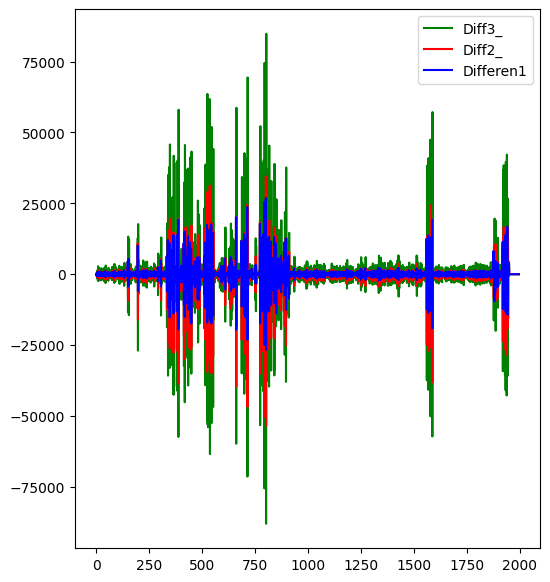

In [ ]:
##Relationship between 1st order, 2nd order, 3rd order values
fig, ax=plt.subplots(figsize=(6,7))
ts_.loc[:,"Diff3_"].plot(ax=ax, color="Green")
ts_.loc[:,"Diff2_"].plot(ax=ax, color="Red")
ts_.loc[:,"Differen1"].plot(ax=ax, color="Blue")
plt.legend()
plt.show()

As one can see from above that,

Higher the order, Higher the variation in differencing.

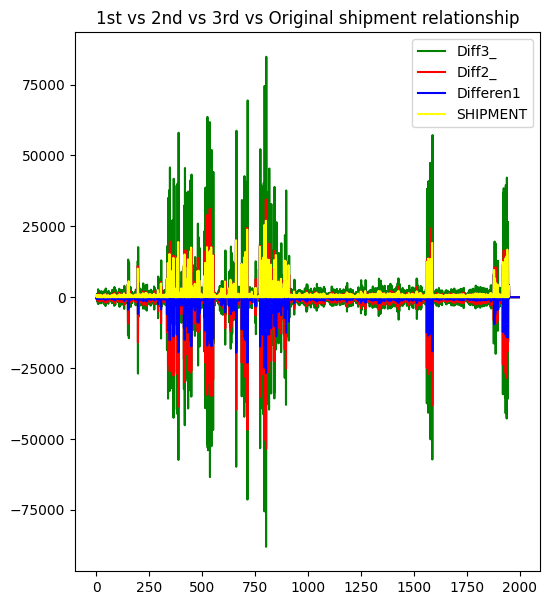

In [ ]:
##Relationship between 1st order, 2nd order, 3rd order and original shipment values
fig, ax=plt.subplots(figsize=(6,7))
ts_.loc[:,"Diff3_"].plot(ax=ax, color="Green")
ts_.loc[:,"Diff2_"].plot(ax=ax, color="Red")
ts_.loc[:,"Differen1"].plot(ax=ax, color="Blue")
ts_.loc[:,"SHIPMENT"].plot(ax=ax, color="Yellow", title="1st vs 2nd vs 3rd vs Original shipment relationship")
plt.legend()
plt.show()

From above plot,

One can say that the patterns of Original shipment closely match with the positive x-axis values of First order differencing values.

In [ ]:
import plotly.express as px
import plotly.express as px
# Create a line chart
fig = px.line(ts_, x="CUT_OFF_TIME", y="Diff1", title='CUT OFF TIME vs First order differencing')
# Display the chart
fig.show()

In [ ]:
import plotly.express as px
import plotly.express as px
# Create a line chart
fig = px.line(ts_, x="CUT_OFF_TIME", y="Diff2", title='CUT OFF TIME vs SHIPMENT')
# Display the chart
fig.show()

In [ ]:
#Absolute values of Differencing using 1st order
ts_["Diff1_absolute"]= abs(ts_["Differen1"])
ts_["Diff1_absolute"].head()

,Diff1_absolute
0,0.0
1,600.0
2,14.0
3,515.0
4,434.0


<Axes: xlabel='Diff1', ylabel='Diff1_absolute'>

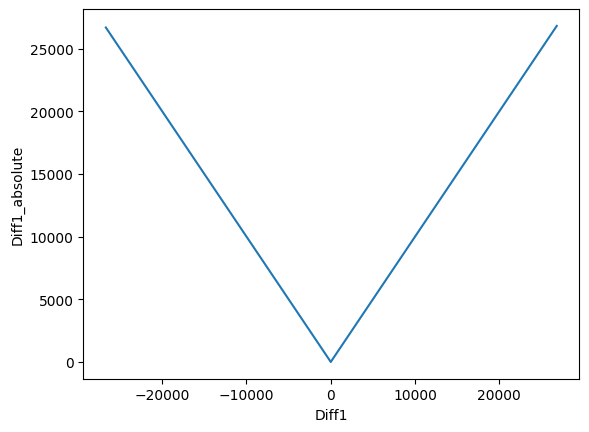

In [ ]:
#Relationship between first order Differencing and absolute value of first order differencing
sns.lineplot(x="Diff1", y="Diff1_absolute", data= ts_)

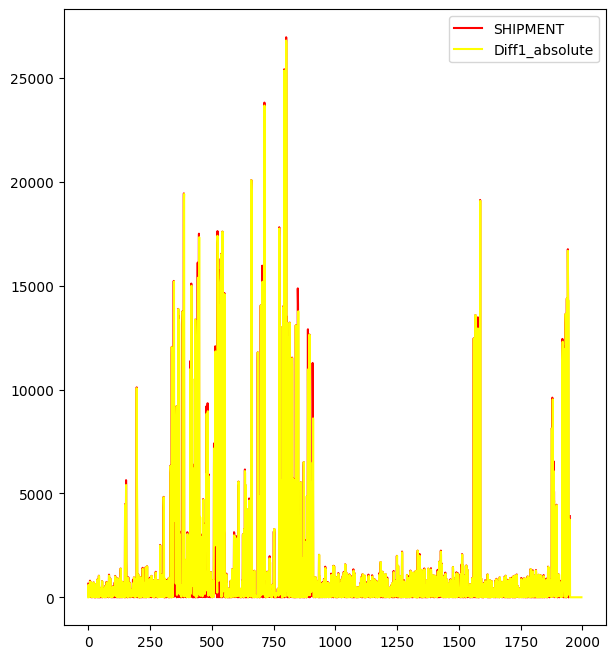

In [ ]:
#Relationship between first order differencing, absolute values of first order, and original shipment
fig,ax=plt.subplots(figsize=(7,8))
#ts_.loc[:,"Differen1"].plot(ax=ax, color="Blue")
ts_.loc[:,"SHIPMENT"].plot(ax=ax, color="Red")
ts_.loc[:,"Diff1_absolute"].plot(ax=ax, color="Yellow")
plt.legend()
plt.show()

Interpretation:

Absolute value of first order differencing has highest overlapping with Original Shipment, with original shipment values higher than absolute 1st order differention value.

 II) SECOND METHOD: Log order differencing to make data stationary

In [ ]:
#Implementing log differencing to make dataset stationary
ts_["Diff1_log"]= np.log(ts_["SHIPMENT"])
ts_["Diff1_log"]= ts_["Diff1_log"].fillna(0)
ts_["Diff1_log"].head()

,Diff1_log
0,6.481577
1,3.970292
2,3.663562
3,6.317165
4,4.787492


array([[<Axes: title={'center': 'Diff1_log'}>,
        <Axes: title={'center': 'SHIPMENT'}>],
       [<Axes: title={'center': 'Diff1_absolute'}>, <Axes: >]],
      dtype=object)

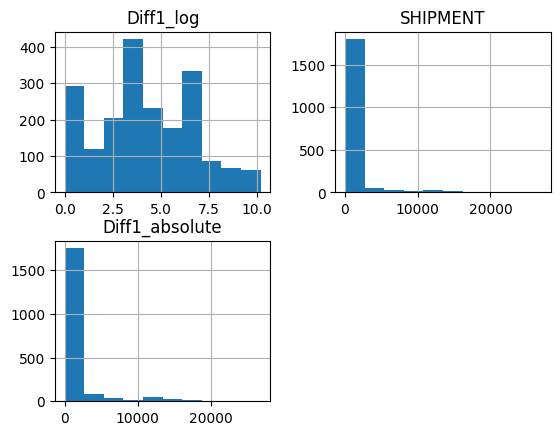

In [ ]:
#Relationship between log transformation, original shipment and absolute values of first order differencing
ts_[["Diff1_log","SHIPMENT","Diff1_absolute"]].hist()

In [ ]:
#Standardization on SHIPMENT and log transformed value for better analysis
from sklearn.preprocessing import StandardScaler
scaling= StandardScaler()
ts_["Diff1_log_"]= scaling.fit_transform(pd.DataFrame(ts_["Diff1_log"]))
ts_["SHIPMENT_"]= scaling.fit_transform(pd.DataFrame(ts_["SHIPMENT"]))

In [ ]:
#Standardization on Absolute value of first order differencing value of original shipment
ts_["Diff1_absolute_"]= scaling.fit_transform(pd.DataFrame(ts_["Diff1_absolute"]))

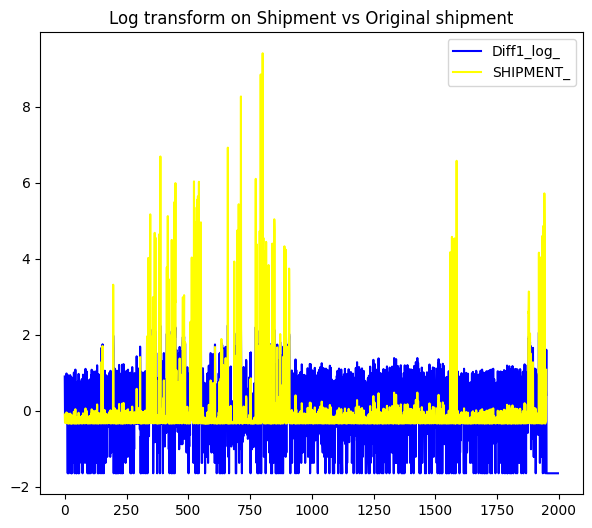

In [ ]:
##Relationship between log implementation of ORIGINAL SHIPMENT and ORIGINAL SHIPMENT
fig, ax= plt.subplots(figsize=(7,6))
ts_.loc[:,"Diff1_log_"].plot(ax=ax, color="Blue")
ts_.loc[:,"SHIPMENT_"].plot(ax=ax, color="Yellow", title="Log transform on Shipment vs Original shipment")
ax.legend()
plt.show()

In [ ]:
#Taking absolute value of log transformation value of Differencing.
ts_["Diff1_log_absolute"]= abs(ts_["Diff1_log_"])

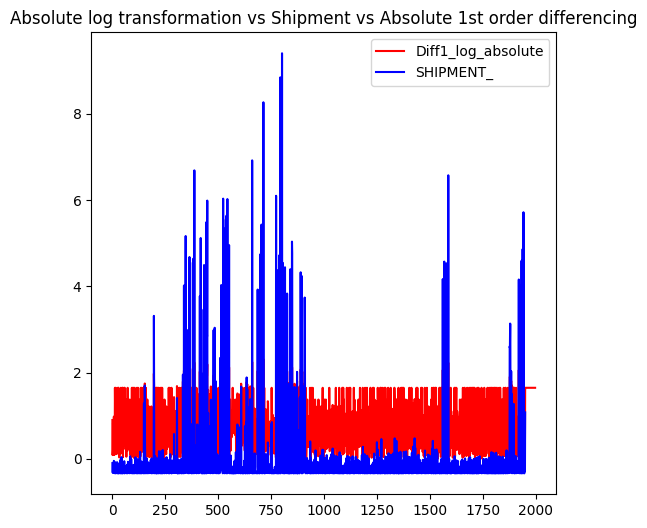

In [ ]:
fig,ax= plt.subplots(figsize=(6,6))
ts_.loc[:,"Diff1_log_absolute"].plot(ax=ax, color="Red")
ts_.loc[:,"SHIPMENT_"].plot(ax=ax, color="Blue", title="Absolute log transformation vs Shipment vs Absolute 1st order differencing")
plt.legend()
plt.show()

INTERPRETATION:

1. Log-order transformation hovers below 2 whereas Original shipment reaches toward 10 after Standardizing.

2. Further, log-order transformation has successfully transformed the above Shipment dataset from non-stationary to stationary form.

## FURTHER PREPROCESSING STEPS

array([[<Axes: title={'center': 'SHIPMENT'}>,
        <Axes: title={'center': 'SHIPMENT_linear'}>]], dtype=object)

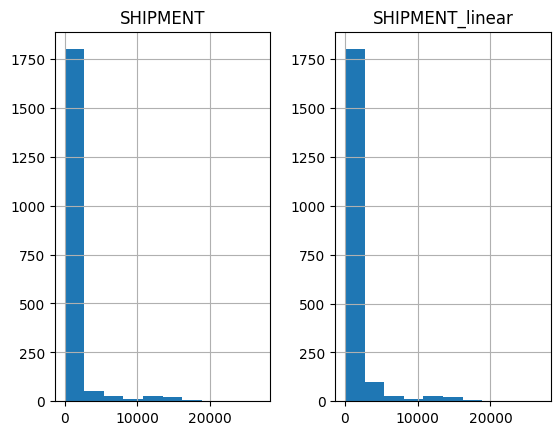

In [ ]:
#LINEAR INTERPOLATION IMPUTATION IN SHIPMENT COLUMN
ts_["SHIPMENT_linear"]= ts_["SHIPMENT"].interpolate(method="linear")
ts_[["SHIPMENT","SHIPMENT_linear"]].hist()

In [ ]:
#importing packages
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

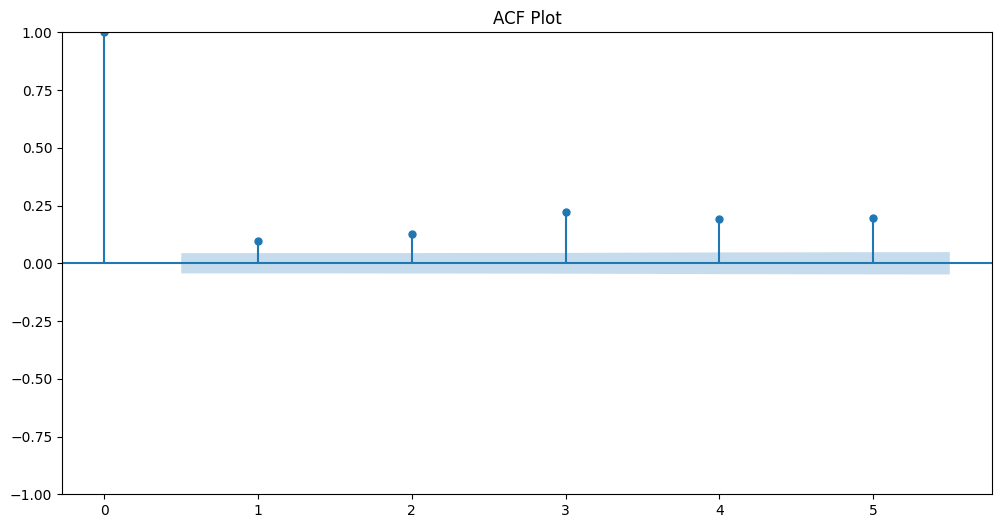

In [ ]:
# ACF and PACF plots for determining ARIMA orders
plt.figure(figsize=(12, 6))
plot_acf(ts_['SHIPMENT_linear'], lags=5, ax=plt.gca())
plt.title('ACF Plot')
plt.show()

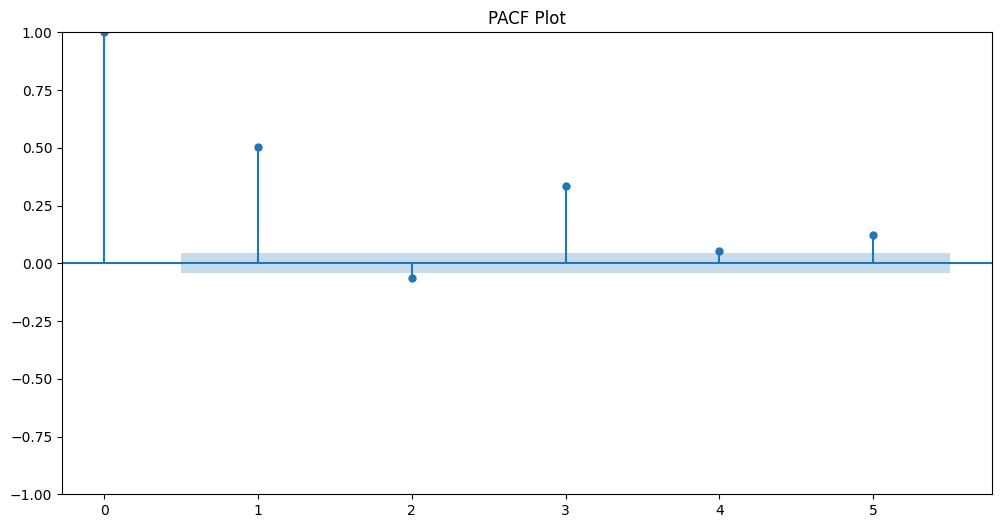

In [ ]:
#PACF Plot for absolute first order differencing
plt.figure(figsize=(12, 6))
plot_pacf(ts_['Diff1_absolute'], lags=5, ax=plt.gca())
plt.title('PACF Plot')
plt.show()

In [ ]:
#IMPUTING SHIPMENT COLUMN WITH 0
ts_["SHIPMENT_NA"]=ts_["SHIPMENT"].fillna(0).astype("int")

In [ ]:
#Missing values count in ts_ dataframe
ts_.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1997 entries, 0 to 1996
Data columns (total 53 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   S.R  NO.                  1997 non-null   int64  
 1   Lane                      1951 non-null   object 
 2   DISPATCHED FROM           1950 non-null   object 
 3   SHIFT                     1950 non-null   object 
 4   GATE PASS NO.             1950 non-null   object 
 5   GATE IN DATE              1950 non-null   object 
 6   GATE IN TIME              1950 non-null   object 
 7   DOCK IN DATE              1950 non-null   object 
 8   DOCK IN TIME              1950 non-null   object 
 9   DOCK OUT DATE             1950 non-null   object 
 10  DOCK OUT TIME             1950 non-null   object 
 11  GATE OUT DATE             1950 non-null   object 
 12  GATE OUT TIME             1950 non-null   object 
 13  CUT OFF TIME              1918 non-null   object 
 14  COC     

In [ ]:
#Importing other packages
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense, Input

In [ ]:
#Checking for missing values
ts_["SHIPMENT_linear"].isna().sum()

np.int64(0)

In [ ]:
#Imputing SHIPMENT Column with linear method
ts_["SHIPMENT_linear"]= ts_["SHIPMENT"].interpolate(method="linear")
ts_["SHIPMENT_linear"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1997 entries, 0 to 1996
Series name: SHIPMENT_linear
Non-Null Count  Dtype  
--------------  -----  
1997 non-null   float64
dtypes: float64(1)
memory usage: 15.7 KB


In [ ]:
#Checking for Stationarity
adfuller(ts_["SHIPMENT_linear"])

(np.float64(-4.8499271378675335),
 np.float64(4.360699168453404e-05),
 25,
 1971,
 {'1%': np.float64(-3.4336720887549483),
  '5%': np.float64(-2.863007508094813),
  '10%': np.float64(-2.567551240570721)},
 np.float64(36588.96392374368))

Here the Test-statistic: 4.84992713786751 and p-value: 4.360699168453847e-05

AS P-value<0.05, we can accept the null-hypothesis, where null hypothesis states that the time series is Stationary.

##Let's check for SHIPMENT before and after imputation with linear method

array([[<Axes: title={'center': 'SHIPMENT'}>,
        <Axes: title={'center': 'SHIPMENT_linear'}>]], dtype=object)

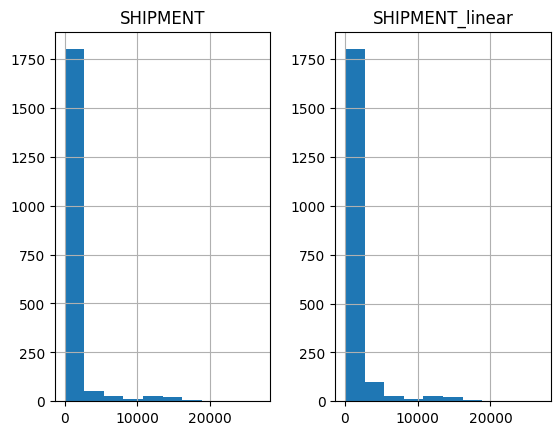

In [ ]:
#Before and after imputation of values in SHIPMENT column
ts_[["SHIPMENT","SHIPMENT_linear"]].hist()

In [ ]:
#Filling missing values by linear interpolation
ts_["TOTAL BAGS"]= ts_["TOTAL BAGS"].interpolate(method="linear")
ts_["TOTAL BAGS"].head()

,TOTAL BAGS
0,28.0
1,4.0
2,39.0
3,21.0
4,5.0


In [ ]:
##Describing the overall statistics of Target variable(SHIPMENT) and TOTAL BAGS
ts_[["SHIPMENT_linear","TOTAL BAGS"]].describe(include="all")

,SHIPMENT_linear,TOTAL BAGS
count,1997.000000,1997.000000
mean,998.882323,65.676515
std,2773.561603,139.051585
min,1.000000,1.000000
25%,17.000000,4.000000
50%,61.000000,18.000000
75%,638.000000,43.000000
max,26964.000000,1001.000000


ABOVE INTERPRETATION:

As ETS doesn't consist 0 or negative values, so one need to use imputation techniques based on the variation in the dataset.

Here, I'm using AutoEncoder to fill missing values and other non-linear methods to fill the missing values present in the dataset.

##Imputation using AutoEncoders

In [ ]:
#Here we don't have missing values,
#hence no need to perform non-linear encoding techniiques

### Applying ETS for Decomposition

As, the value from first order differencing contains negative values, can move ahead with "Additive" model or can select "Absolute value of first order differencing" then could go ahead with other form of ETS model(i.e., Multiplicative).

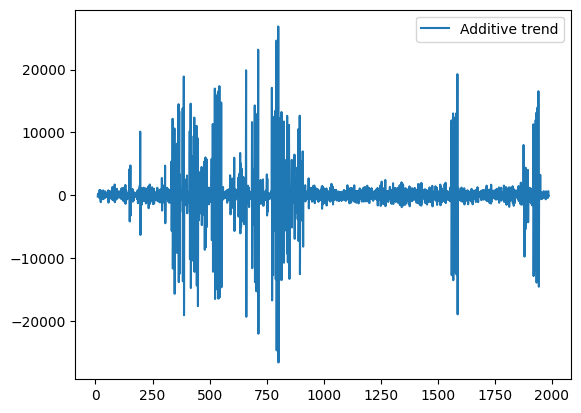

In [ ]:
#Decomposition of dataset into Error, Trend and Seasonality
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Fill NaN values in 'Diff1' before decomposition
diff1_series = ts_['Differen1'].fillna(0)

#As we are dealing with property of multiplicity due to presence of zero and negative values.
# Transforming those values by shifting with a constant number, say 1.
diff1_series_ = diff1_series + abs(diff1_series.min()) + 1

# ETS Decomposition
#result = seasonal_decompose(diff1_series_, model ='multiplicative',period=20)
result_ = seasonal_decompose(diff1_series, model ='additive',period= 20)


# ETS plot
plt.plot(result_.resid, label="Additive trend")
plt.legend()

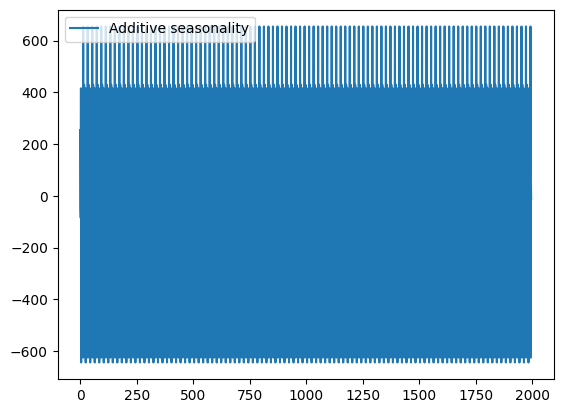

In [ ]:
plt.plot(result_.seasonal, label="Additive seasonality")
plt.legend()

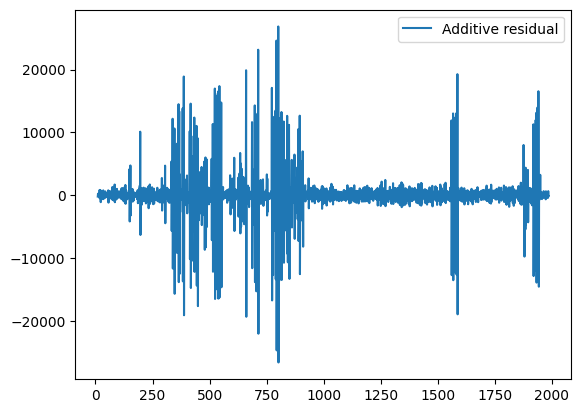

In [ ]:
plt.plot(result_.resid, label="Additive residual")
plt.legend()

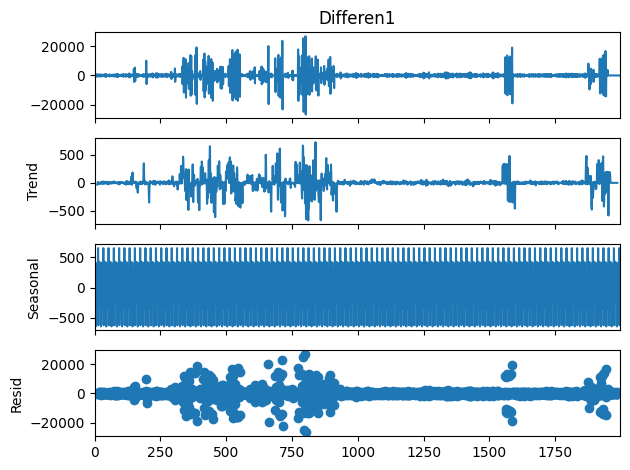

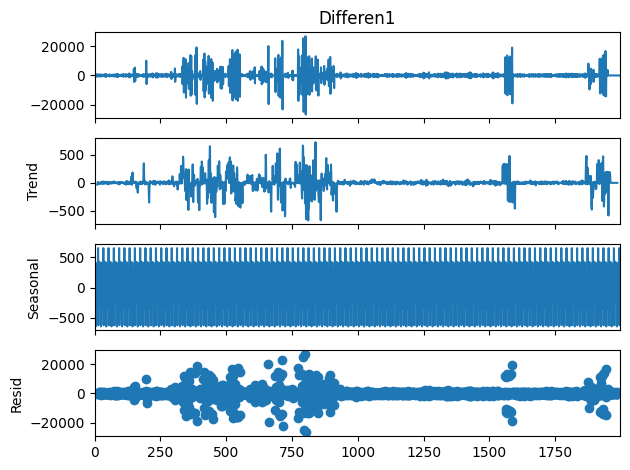

In [ ]:
#ETS Decomposition on First order differencing when model ia additive
result_1 = seasonal_decompose(diff1_series, model ='additive',period= 20)
result_1.plot()

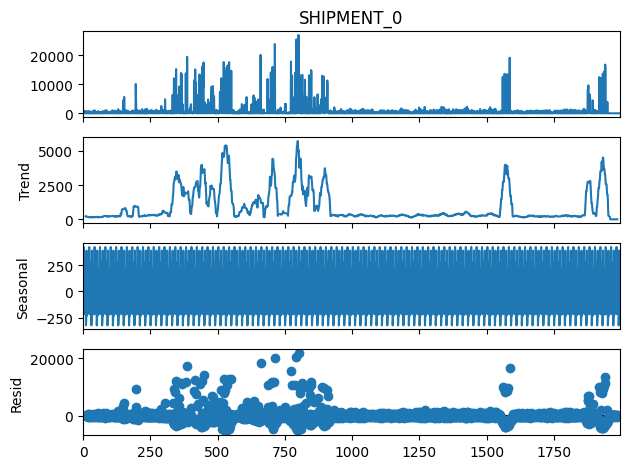

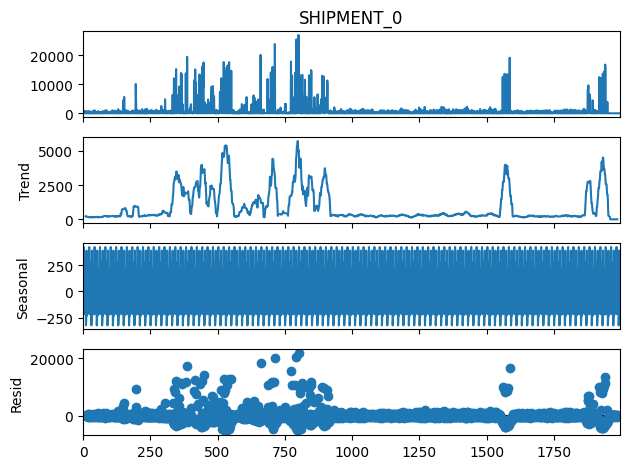

In [ ]:
# ETS Decomposition when imputing with 0, in SHIPMENT with additive seasonality
ts_["SHIPMENT_0"]= ts_["SHIPMENT"].fillna(0)
result2 = seasonal_decompose(ts_["SHIPMENT_0"], model ='additive',period= 20)
result2.plot()

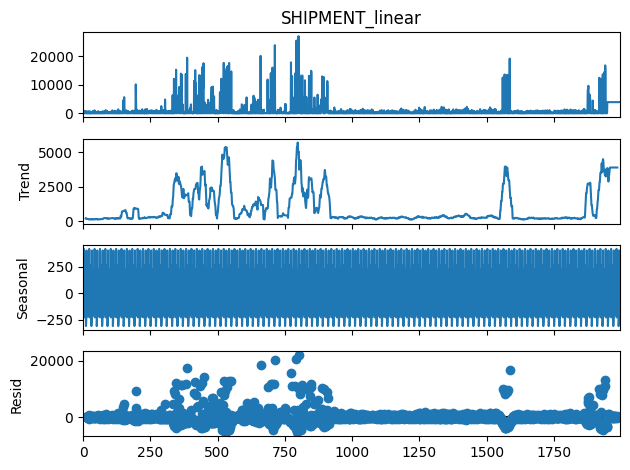

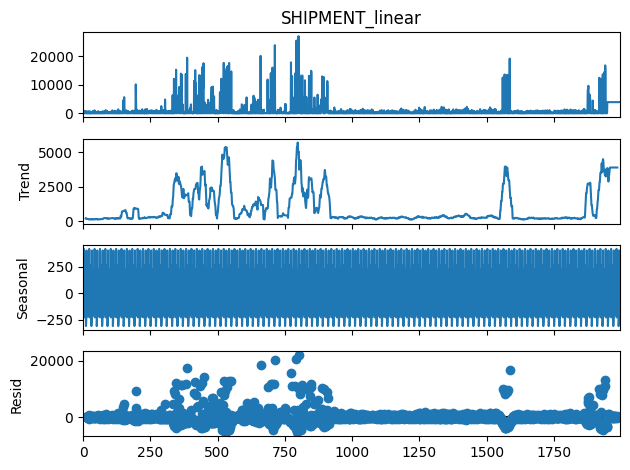

In [ ]:
# ETS Decomposition on linear imputation on SHIPMENT with additive seaosnlaity
result3= seasonal_decompose(ts_["SHIPMENT_linear"], model="additive", period= 20)
result3.plot()

###3. MOVING AVERAGE and EXPONENTIAL MOVING AVERAGE on given Dataset.

Moving averages are mathematical techniques used to analyze time-series data. They represent the average value of a variable over a specified period, with the "moving" aspect referring to the continuous update of the average as new data points arrive.

In [ ]:
#Simple Moving average for 7 days
window_size= 7
window=ts_["SHIPMENT_linear"].rolling(window=window_size).mean()
ts_["moving_Average"]= window
window.head(10)


,SHIPMENT_linear
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
5,NaN
6,214.285714
7,235.000000
8,233.714286
9,312.285714


 SMA: It calculates the average of a fixed window of data points. For example, a 7-day SMA considers the average of the last 7 days' values

In [ ]:
#Equating simple moving average values into new column
ts_["moving_Average"]= window
ts_["Moving_Average"]= ts_["moving_Average"].dropna()
window1= window.dropna()

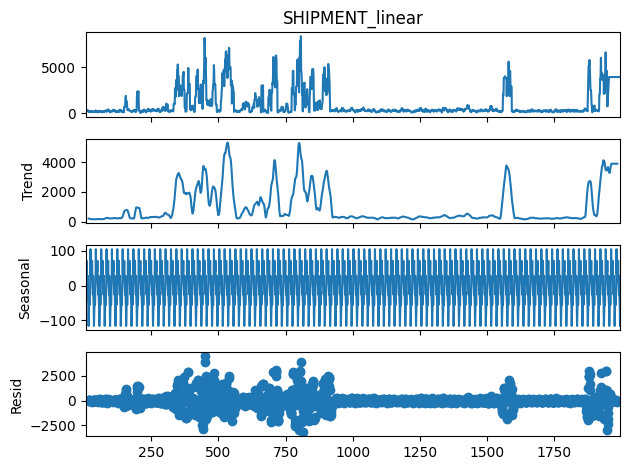

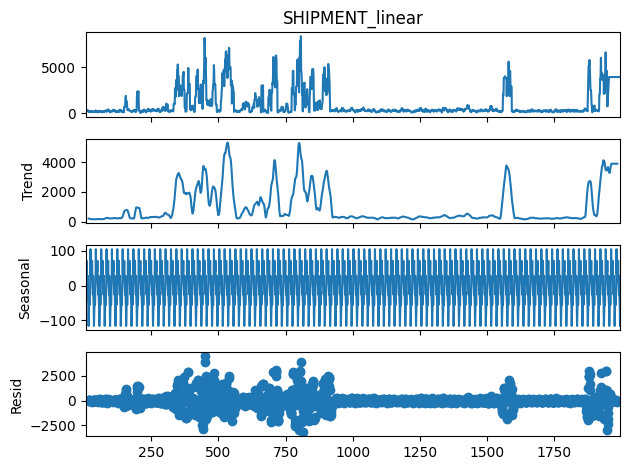

In [ ]:
result2 = seasonal_decompose(window1, model ='additive',period= 20)
result2.plot()

EMA: Unlike SMA, EMA assigns different weights to recent and older data points. It reacts more swiftly to recent changes, making it suitable for trend-following strategies.

In [ ]:
##Exponential moving average on given dataset for 20 days
exp_window= 20
exp= ts_["SHIPMENT_linear"].ewm(span=exp_window).mean()
ts_["exp_movingaverage"]= exp
exp.head(10)

,SHIPMENT_linear
0,653.000000
1,338.000000
2,228.208993
3,322.259819
4,273.334890
5,221.791389
6,189.688040
7,294.837819
8,254.602206
9,304.959616


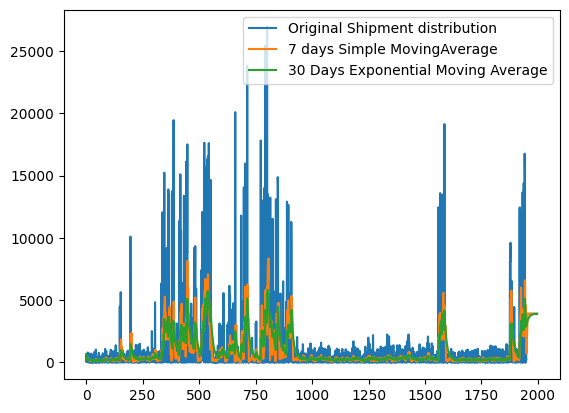

In [ ]:
##Distribution of original shipment values vs 7 days moving average vs 30 days exponential moving average.
plt.plot(figsize=(27,16))
plt.plot(ts_["SHIPMENT_linear"], label="Original Shipment distribution")
plt.legend()
plt.plot(window, label='7 days Simple MovingAverage') #mean value
plt.legend()
plt.plot(exp, label='30 Days Exponential Moving Average') #mean value
plt.legend()

##MODEL IMPLEMENTATION

In [ ]:
pip install utilsforecast

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 4.5 MB/s eta 0:00:00


In [ ]:
from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *

In [ ]:
!pip install statsforecast

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 501.0/501.0 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.6/348.6 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 4.1 MB/s eta 0:00:00


In [ ]:
from statsforecast import StatsForecast
from statsforecast.models import Naive, HistoricAverage, WindowAverage, SeasonalNaive

In [ ]:
ts_.columns

Index(['S.R  NO.', 'Lane', 'DISPATCHED FROM', 'SHIFT', 'GATE PASS NO.',
       'GATE IN DATE', 'GATE IN TIME', 'DOCK IN DATE', 'DOCK IN TIME',
       'DOCK OUT DATE', 'DOCK OUT TIME', 'GATE OUT DATE', 'GATE OUT TIME',
       'CUT OFF TIME', 'COC', 'CM', 'Bag Qty\n(As Per ERP)',
       'Large Shipment \nBag(QTY)', 'IT & STOCK & EKL BAG', 'TOTAL BAGS',
       'SHIPMENT', 'WT.', 'Trip ID', 'SPILL OVER BAG DETAIL', 'Vendor Name',
       'Vehicle No', 'DOCK NO', 'Description', 'SIZE', 'KILO METER',
       'Adhoc/Regular', 'DRIVER NAME', 'Contact No.', 'Seal No.',
       'Prealert Status', 'VEHICLE LOAD BY', 'Report Created By',
       'CUT_OFF_TIME', 'Diff1', 'Diff1_', 'Differen1', 'Diff2', 'Diff2_',
       'Diff3', 'Diff3_', 'Diff1_absolute', 'Diff1_log', 'Diff1_log_',
       'SHIPMENT_', 'Diff1_absolute_', 'Diff1_log_absolute', 'SHIPMENT_linear',
       'SHIPMENT_NA', 'SHIPMENT_0', 'moving_Average', 'Moving_Average',
       'exp_movingaverage'],
      dtype='object')

In [ ]:
minute= 30

models=[
Naive(),
HistoricAverage(),
WindowAverage(window_size=30),
SeasonalNaive(season_length=30)]
# Removed freq="min" as timestamps are not consistently minute-frequency
stats= StatsForecast(models=models, freq=None)

In [ ]:
ts_.columns

Index(['S.R  NO.', 'Lane', 'DISPATCHED FROM', 'SHIFT', 'GATE PASS NO.',
       'GATE IN DATE', 'GATE IN TIME', 'DOCK IN DATE', 'DOCK IN TIME',
       'DOCK OUT DATE', 'DOCK OUT TIME', 'GATE OUT DATE', 'GATE OUT TIME',
       'CUT OFF TIME', 'COC', 'CM', 'Bag Qty\n(As Per ERP)',
       'Large Shipment \nBag(QTY)', 'IT & STOCK & EKL BAG', 'TOTAL BAGS',
       'SHIPMENT', 'WT.', 'Trip ID', 'SPILL OVER BAG DETAIL', 'Vendor Name',
       'Vehicle No', 'DOCK NO', 'Description', 'SIZE', 'KILO METER',
       'Adhoc/Regular', 'DRIVER NAME', 'Contact No.', 'Seal No.',
       'Prealert Status', 'VEHICLE LOAD BY', 'Report Created By',
       'CUT_OFF_TIME', 'Diff1', 'Diff1_', 'Differen1', 'Diff2', 'Diff2_',
       'Diff3', 'Diff3_', 'Diff1_absolute', 'Diff1_log', 'Diff1_log_',
       'SHIPMENT_', 'Diff1_absolute_', 'Diff1_log_absolute', 'SHIPMENT_linear',
       'SHIPMENT_NA', 'SHIPMENT_0', 'moving_Average', 'Moving_Average',
       'exp_movingaverage'],
      dtype='object')

In [ ]:
!pip install datetime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.2/47.2 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.7/270.7 kB 17.3 MB/s eta 0:00:00


In [ ]:
!pip install timedelta-isoformat

In [ ]:
from datetime import datetime
from datetime import timedelta
from timedelta_isoformat import timedelta
#from timedelta_isoformat import timedelta
import datetime as dt
ts_["ds"]= pd.to_datetime(ts_['CUT OFF TIME'], format="%H:%M:%S", errors="coerce").dt.strftime('%H:%M:%S')

In [ ]:
TS= ts_[["GATE IN DATE","CUT OFF TIME", "SHIPMENT_linear", "CUT_OFF_TIME", 'Differen1', 'Diff2','ds']]

In [ ]:
TS.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1997 entries, 0 to 1996
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   GATE IN DATE     1950 non-null   object 
 1   CUT OFF TIME     1918 non-null   object 
 2   SHIPMENT_linear  1997 non-null   float64
 3   CUT_OFF_TIME     1918 non-null   object 
 4   Differen1        1997 non-null   float64
 5   Diff2            1945 non-null   float64
 6   ds               1260 non-null   object 
dtypes: float64(3), object(4)
memory usage: 109.3+ KB


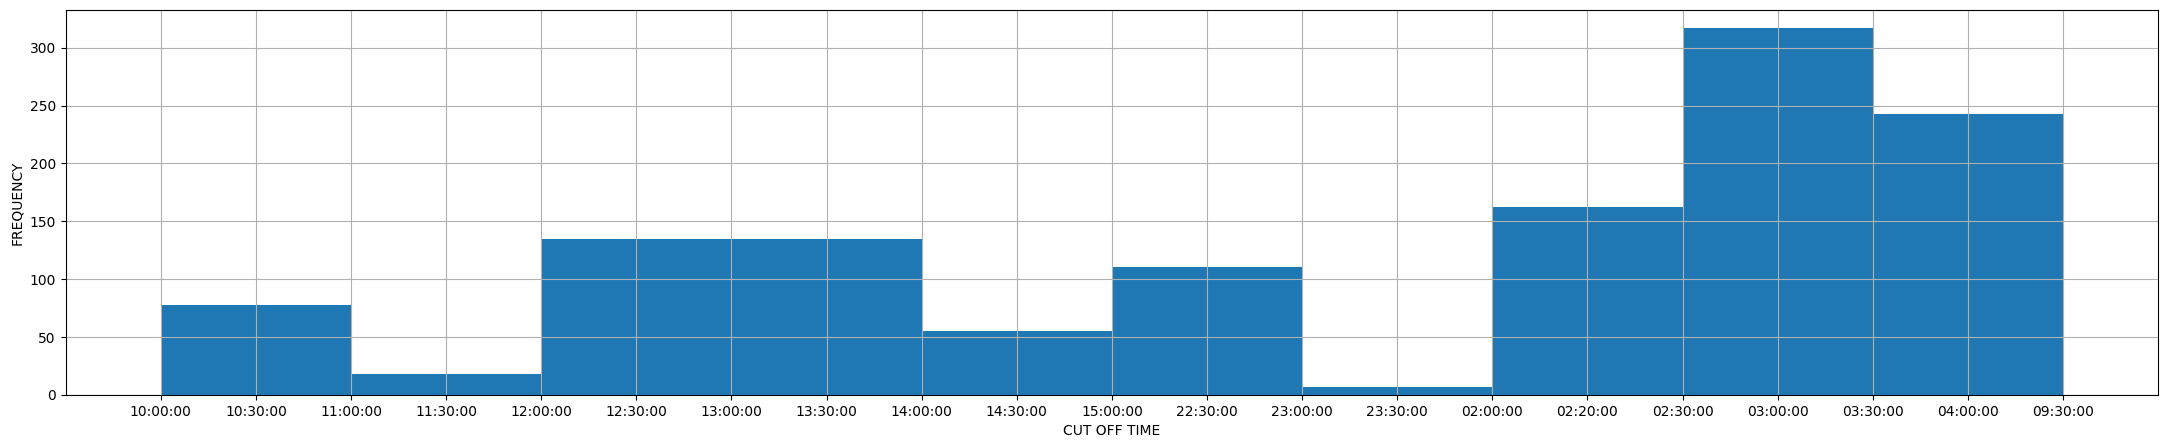

In [ ]:
fig,ax= plt.subplots(figsize=(27,5))
TS.ds.hist()
plt.xlabel("CUT OFF TIME")
plt.ylabel("FREQUENCY")
plt.show()

In [ ]:
# Ensure 'GATE IN DATE' is in datetime format
TS['GATE IN DATE'] = pd.to_datetime(TS['GATE IN DATE'], format='%d-%b-%Y', errors='coerce')

# Combine 'GATE IN DATE' with 'CUT_OFF_TIME' to create a proper datetime 'ds' column
# ts_['CUT_OFF_TIME'] is already a datetime.time object
TS['ds'] = TS.apply(lambda row: row['GATE IN DATE'].replace(
    hour=row['CUT_OFF_TIME'].hour,
    minute=row['CUT_OFF_TIME'].minute,
    second=row['CUT_OFF_TIME'].second
) if pd.notna(row['GATE IN DATE']) and pd.notna(row['CUT_OFF_TIME']) else pd.NaT, axis=1)

# Renaming 'SHIPMENT' to 'y' for StatsForecast
TS['y'] = TS['SHIPMENT_linear']

#Unique id to form groups according to a specific condition
#Considering all the dataset into "Series1" group
TS['unique_id'] = 'series_1'

# Dropping rows where 'ds' or 'y' are NaN before aggregation and model fitting
TS = TS.dropna(subset=['ds', 'y'])

# Aggregate duplicate timestamps if they exist (multiple 'y' for same 'ds')
if TS[['unique_id', 'ds']].duplicated().any():
    print("Warning: Duplicate 'ds' values found for 'unique_id'. Aggregating 'y' by 'ds' (sum).")
    TS = TS.groupby(['unique_id', 'ds'], as_index=False)['y'].sum()
    # Re-assign 'unique_id' as groupby might change it if as_index was False, or for clarity.
    TS['unique_id'] = 'series_1'

# Sort by the new datetime index
TS = TS.sort_values(by='ds').reset_index(drop=True)

# As the Time series dataframe contains ds,y and unique id for further processing
# Selecting only the required columns for StatsForecast: 'unique_id', 'ds', and 'y'
TS_final = TS[['unique_id', 'ds', 'y']]

# Fitting the StatsForecast model
stats.fit(TS_final, id_col='unique_id', time_col='ds', target_col='y')

/tmp/ipykernel_1142/852307964.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_1142/852307964.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_1142/852307964.py:13: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_1142/8

StatsForecast(models=[Naive,HistoricAverage,WindowAverage,SeasonalNaive])

In [ ]:
from statsforecast import StatsForecast
from statsforecast.models import Naive, HistoricAverage, WindowAverage, SeasonalNaive
from statsforecast.models import AutoARIMA

models=[
Naive(),
HistoricAverage(),
WindowAverage(window_size=12),
SeasonalNaive(season_length=10),
AutoARIMA(seasonal= False, alias="ARIMA_no_Season"),
#AutoARIMA(season_length= 12, alias="ARIMA_Season")
]
stats = StatsForecast(models=models, freq='30min')

# Re-fitting the model with the correct frequency.
stats.fit(TS_final, id_col='unique_id', time_col='ds', target_col='y')

# predicting for the specified number of steps (minute)
future = stats.predict(h=minute)
future.columns

Index(['unique_id', 'ds', 'Naive', 'HistoricAverage', 'WindowAverage',
       'SeasonalNaive', 'ARIMA_no_Season'],
      dtype='object')

In [ ]:
future.head()

,unique_id,ds,Naive,HistoricAverage,WindowAverage,SeasonalNaive,ARIMA_no_Season
0,series_1,2025-03-19 23:30:00,16070.0,42242.9,52917.75,3179.0,28131.760504
1,series_1,2025-03-20 00:00:00,16070.0,42242.9,52917.75,95103.0,41465.041071
2,series_1,2025-03-20 00:30:00,16070.0,42242.9,52917.75,66168.0,41465.041071
3,series_1,2025-03-20 01:00:00,16070.0,42242.9,52917.75,131850.0,41465.041071
4,series_1,2025-03-20 01:30:00,16070.0,42242.9,52917.75,99417.0,41465.041071


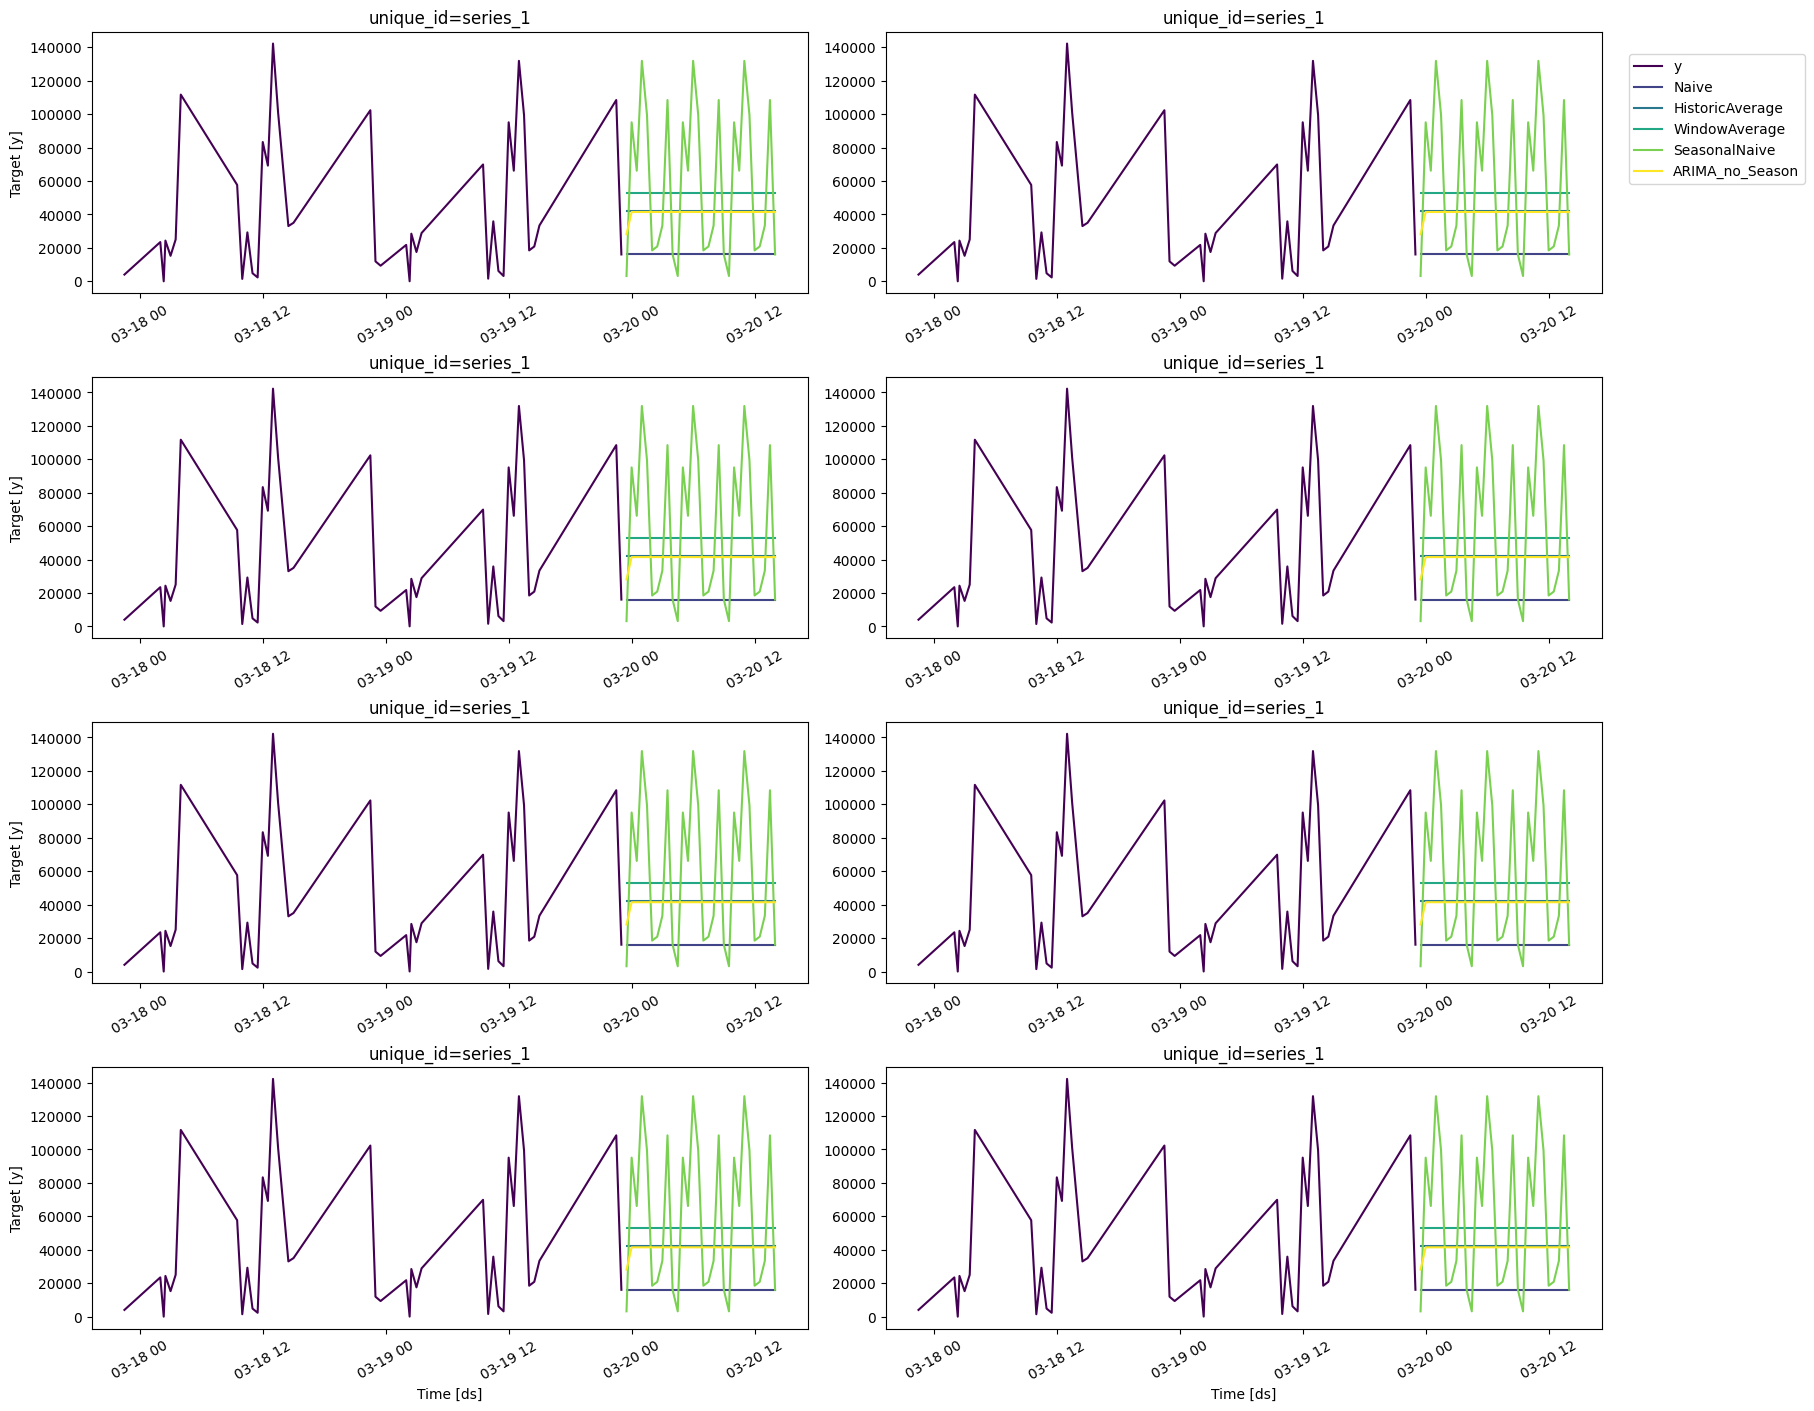

In [ ]:
plot_series(
    df=TS,
    forecasts_df= future,
    ids= TS["unique_id"],
    palette="viridis"

)

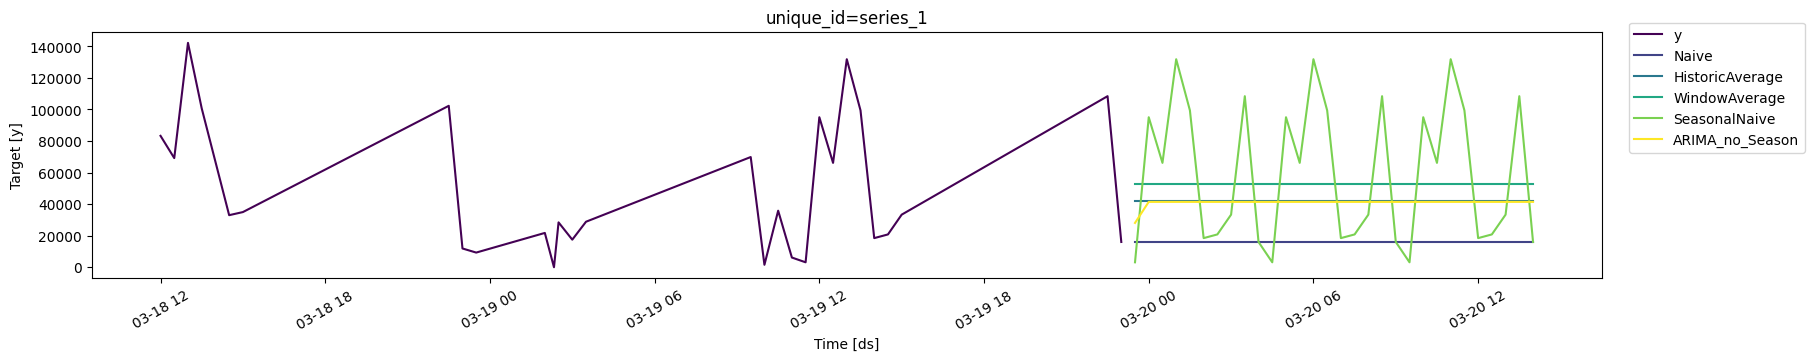

In [ ]:
#Broader view of above prediction
plot_series(
    df= TS,
    forecasts_df=future,
    palette="viridis",
    max_insample_length= 28
)

In [ ]:
TS.columns

Index(['unique_id', 'ds', 'y'], dtype='object')

##Forecast using ARIMA and its family

In [ ]:
from statsforecast import StatsForecast
from statsforecast.models import Naive, HistoricAverage, WindowAverage, SeasonalNaive
from statsforecast.models import AutoARIMA

models_arima=[
AutoARIMA(seasonal= False, alias="ARIMA_no_Season"),
AutoARIMA(season_length=24, alias="ARIMA_Season")
]
stats_arima = StatsForecast(models=models_arima, freq='30min')

# Re-fitting the model with the correct frequency.
stats_arima.fit(TS_final, id_col='unique_id', time_col='ds', target_col='y')

# predicting for the specified number of steps (minute)
future_arima = stats_arima.predict(h=minute)
future_arima.columns

Index(['unique_id', 'ds', 'ARIMA_no_Season', 'ARIMA_Season'], dtype='object')

In [ ]:
future_arima.head()

,unique_id,ds,ARIMA_no_Season,ARIMA_Season
0,series_1,2025-03-19 23:30:00,28131.760504,28131.760504
1,series_1,2025-03-20 00:00:00,41465.041071,41465.041071
2,series_1,2025-03-20 00:30:00,41465.041071,41465.041071
3,series_1,2025-03-20 01:00:00,41465.041071,41465.041071
4,series_1,2025-03-20 01:30:00,41465.041071,41465.041071


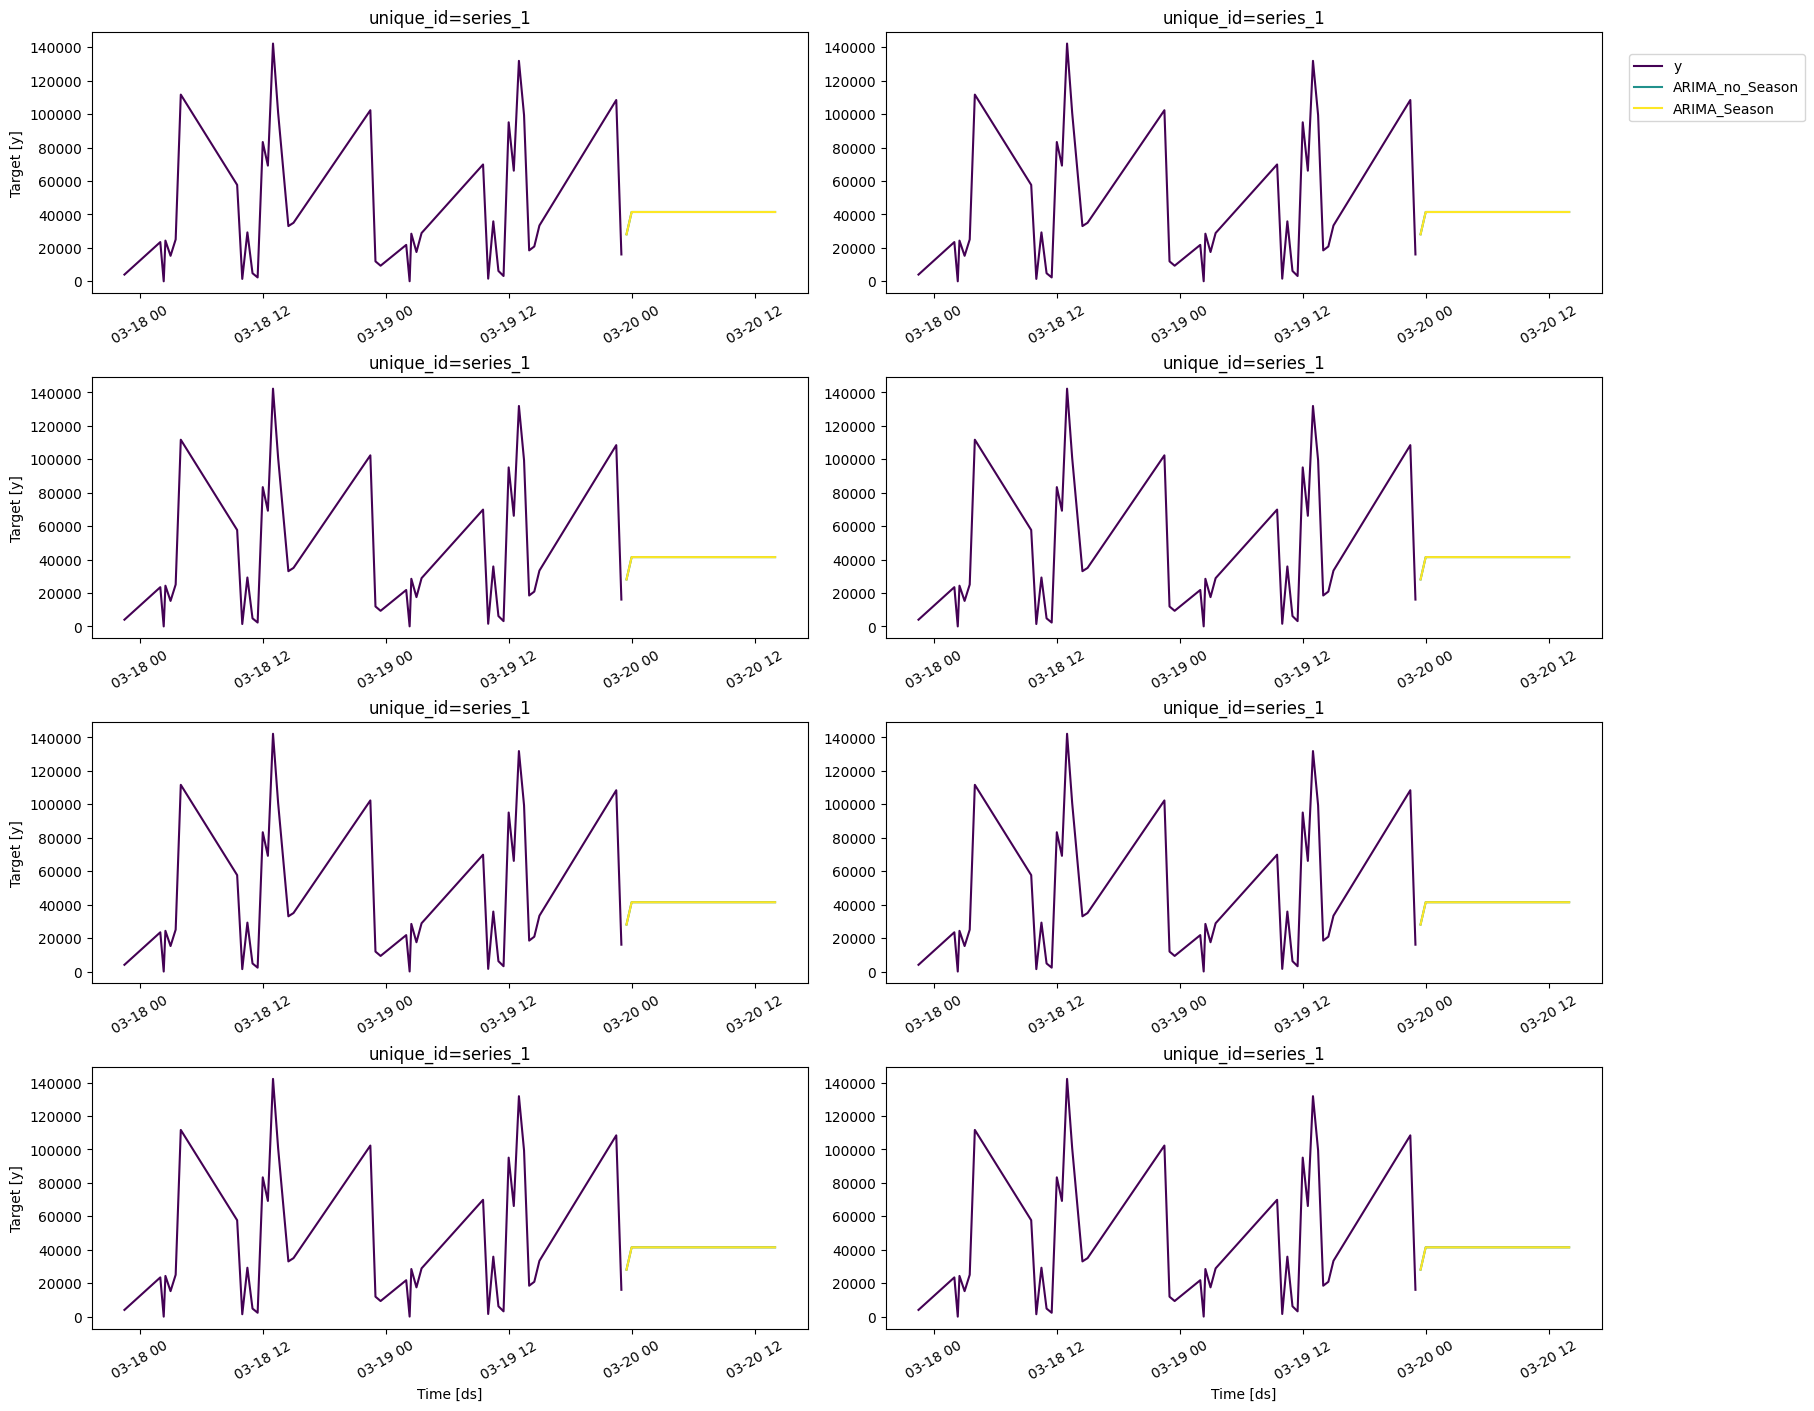

In [ ]:
TS["ds"]= pd.to_datetime(TS["ds"],errors="coerce")
plot_series(
    df=TS,
    forecasts_df= future_arima,
    ids= TS["unique_id"],
    palette="viridis"

)

##With multiple models of time series

In [ ]:
##Model 2 wth more specified models
from statsforecast import StatsForecast
from statsforecast.models import (
    HoltWinters,
    CrostonClassic as Croston,
    HistoricAverage,
    DynamicOptimizedTheta as DOT,
    SeasonalNaive
)

In [ ]:
# Create a list of models and instantiation parameters
models1 = [
    HoltWinters(),
    Croston(),
    SeasonalNaive(season_length=30),
    HistoricAverage(),
    DOT(season_length=12)
]

In [ ]:
# Instantiate StatsForecast class as sf
stat = StatsForecast(
    models=models1,
    freq="30min",
    fallback_model = SeasonalNaive(season_length=30),
    n_jobs=-1,
)

In [ ]:
!pip install statsmodels

In [ ]:
#!pip install SARIMAX

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsforecast.models import (
    HoltWinters,
    CrostonClassic as Croston,
    HistoricAverage,
    DynamicOptimizedTheta as DOT,
    SeasonalNaive,
    AutoARIMA,
)

models_for_stats1 = [
    HoltWinters(season_length=12), # Assuming daily seasonality with 2h frequency
    Croston(),
    SeasonalNaive(season_length=12),
    HistoricAverage(),
    DOT(season_length=12),
    AutoARIMA(season_length= 6),

]

stats1= StatsForecast(models=models_for_stats1, freq="2h")
stats1.fit(TS, id_col='unique_id', time_col='ds', target_col='y')

# predict for the specified number of steps (minute), including prediction intervals
future1 = stats1.predict(h=minute)
future1.columns

Index(['unique_id', 'ds', 'HoltWinters', 'CrostonClassic', 'SeasonalNaive',
       'HistoricAverage', 'DynamicOptimizedTheta', 'AutoARIMA'],
      dtype='object')

In [ ]:
future1.head()

,unique_id,ds,HoltWinters,CrostonClassic,SeasonalNaive,HistoricAverage,DynamicOptimizedTheta,AutoARIMA
0,series_1,2025-03-20 01:00:00,37229.164207,47866.155962,35872.0,42242.9,48612.020421,28131.760504
1,series_1,2025-03-20 03:00:00,31246.734580,47866.155962,6203.0,42242.9,48612.020421,41465.041071
2,series_1,2025-03-20 05:00:00,82744.180582,47866.155962,3179.0,42242.9,48612.020421,41465.041071
3,series_1,2025-03-20 07:00:00,73767.048115,47866.155962,95103.0,42242.9,48612.020421,41465.041071
4,series_1,2025-03-20 09:00:00,35405.202063,47866.155962,66168.0,42242.9,48612.020421,41465.041071


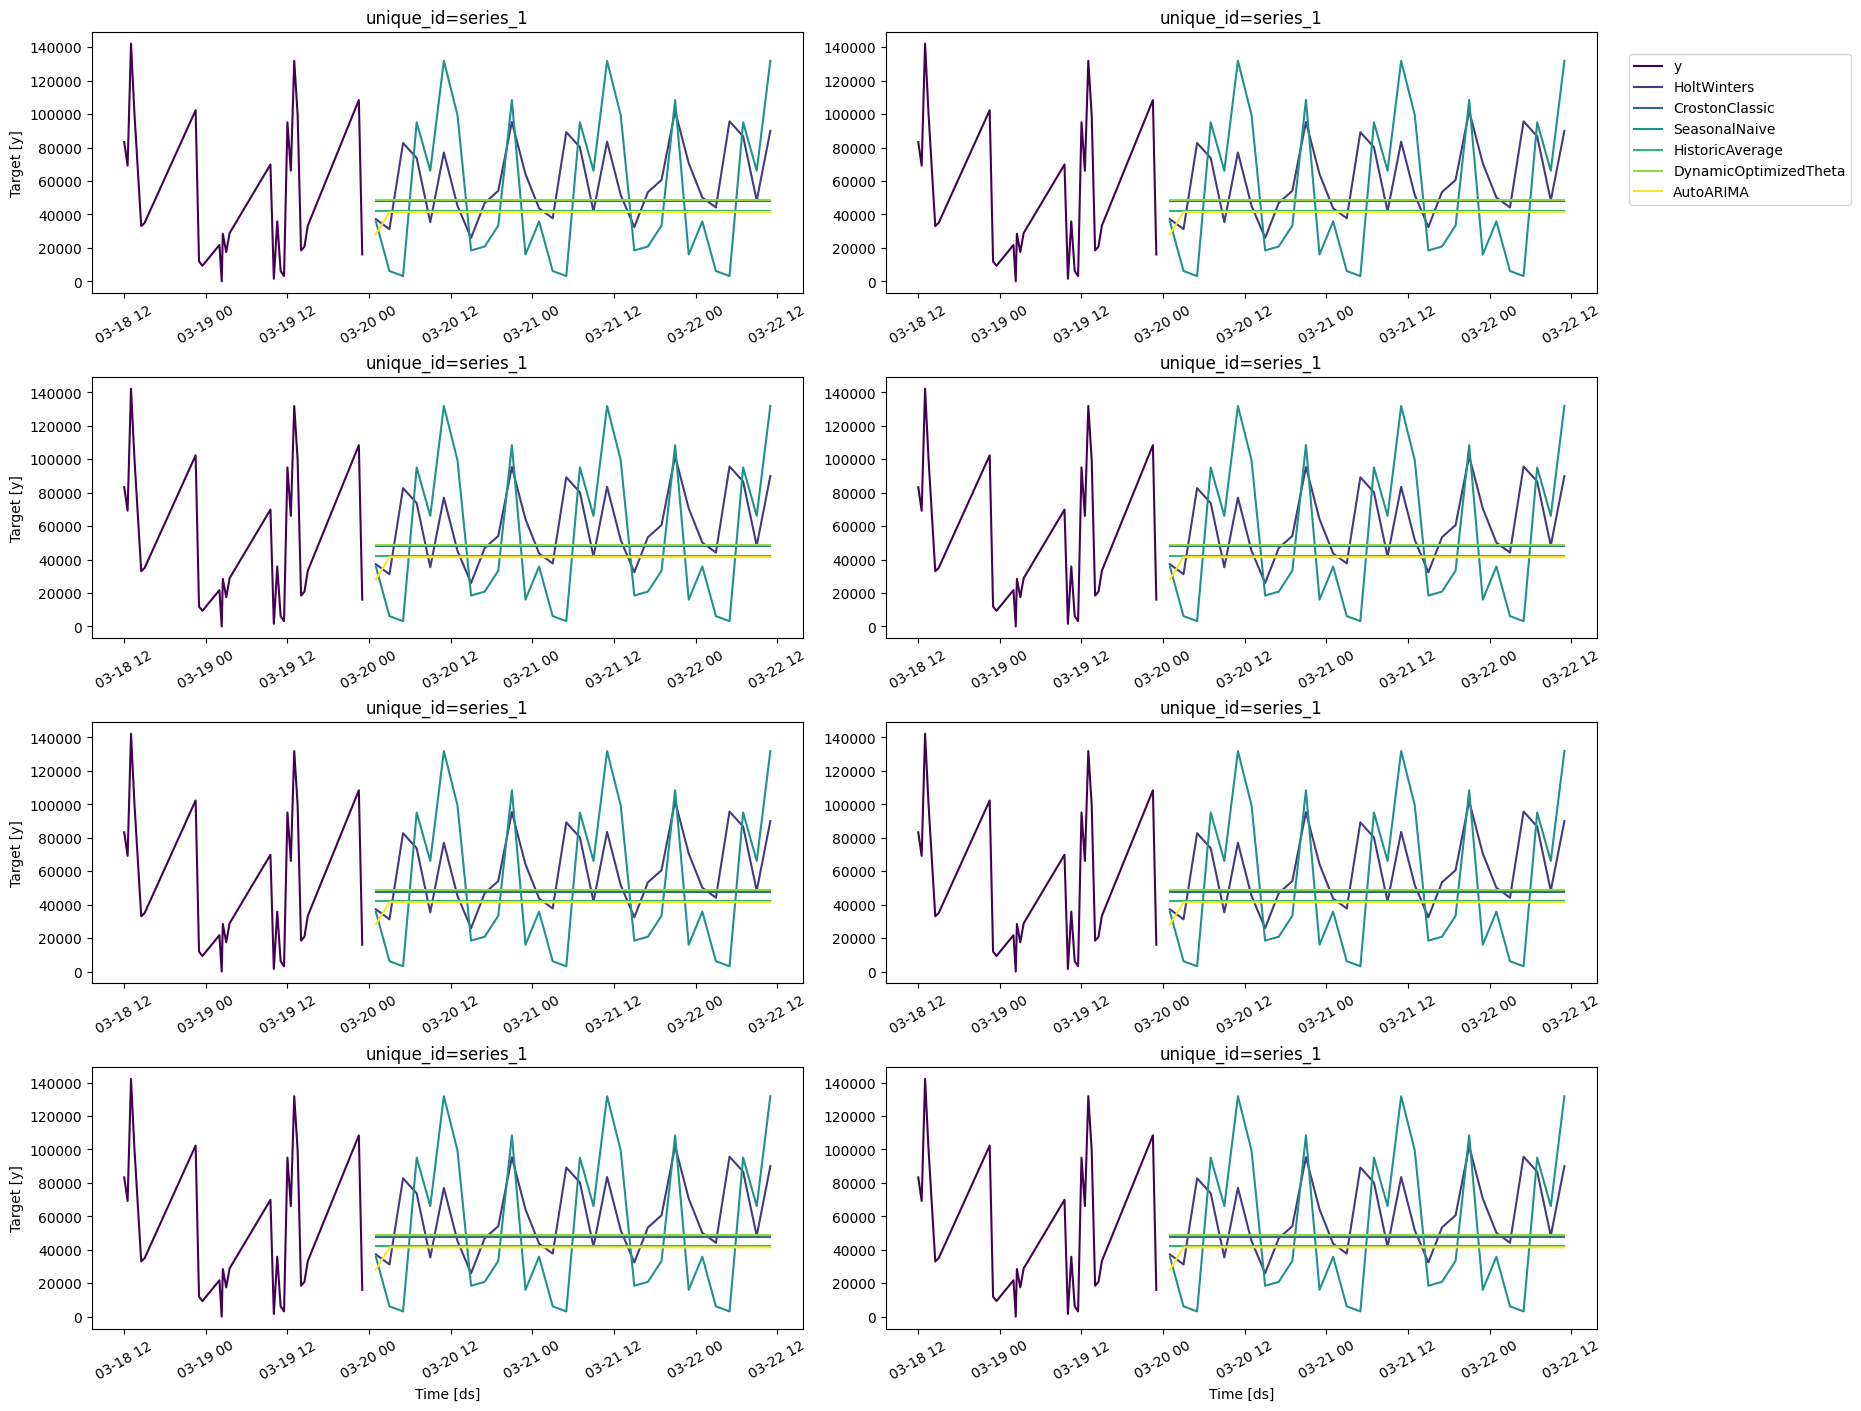

In [ ]:
#Visualizing above prediction with different models mentioned above
plot_series(
    df= TS,
    forecasts_df=future1,
    ids= TS["unique_id"],
    palette="viridis",
    max_insample_length= 28
)

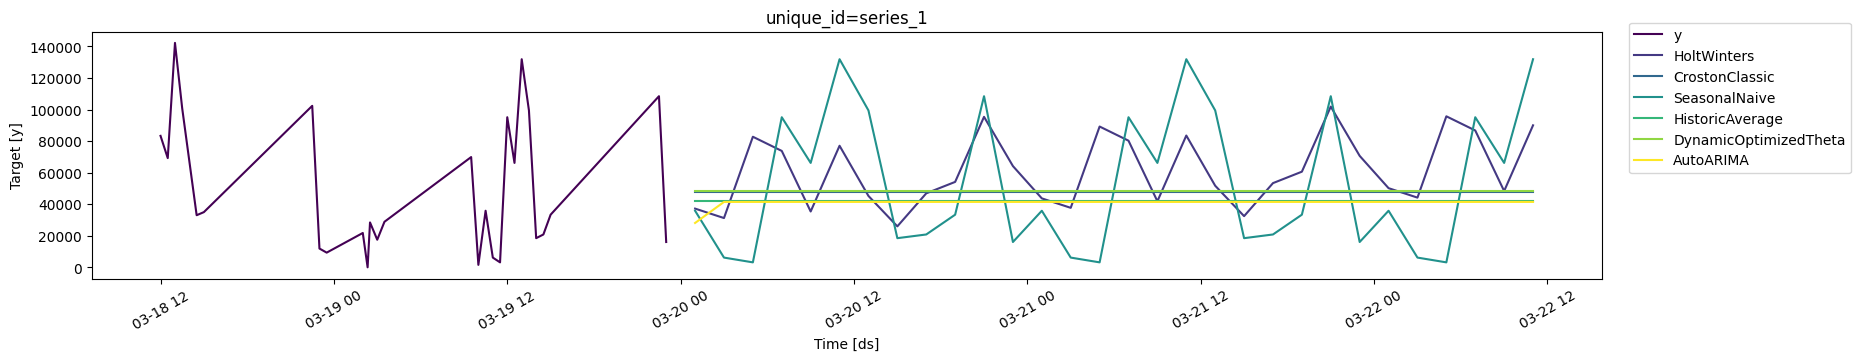

In [ ]:
#Broader view of above prediction
plot_series(
    df= TS,
    forecasts_df=future1,
    palette="viridis",
    max_insample_length= 28
)

In [ ]:
#Implementing Cross-Validation
TS= TS.astype("str")
TS["y"]= TS["y"].astype("float")
cv_df = stat.cross_validation(
    df=TS,
    h=6,
    step_size=10,
    n_windows=2
)
cv_df.tail()

/usr/local/lib/python3.12/dist-packages/statsforecast/utils.py:244: UserWarning:

Historical data (24) is shorter than season_length (30). Forecasts for positions without observations will be filled with NaN.



,unique_id,ds,cutoff,y,HoltWinters,CrostonClassic,SeasonalNaive,HistoricAverage,DynamicOptimizedTheta
7,series_1,2025-03-19 14:00:00,2025-03-19 13:00:00,18505.0,25053.0,47405.534912,25053.0,40972.882353,80126.102017
8,series_1,2025-03-19 14:30:00,2025-03-19 13:00:00,20844.0,111665.0,47405.534912,111665.0,40972.882353,80126.102017
9,series_1,2025-03-19 15:00:00,2025-03-19 13:00:00,33376.0,57665.0,47405.534912,57665.0,40972.882353,80126.102017
10,series_1,2025-03-19 22:30:00,2025-03-19 13:00:00,108426.0,1448.0,47405.534912,1448.0,40972.882353,80126.102017
11,series_1,2025-03-19 23:00:00,2025-03-19 13:00:00,16070.0,29265.0,47405.534912,29265.0,40972.882353,80126.102017


In [ ]:
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mse

In [ ]:
#Specifying Evaluation metrics to come up with the best model for prediction
def evaluate_cv(df, metric):
    models = df.columns.drop(['unique_id', 'ds', 'y', 'cutoff']).tolist()
    evals = evaluate(df, metrics=[metric], models=models)
    evals = evals.drop(columns=['metric'])
    evals['best_model'] = evals[models].idxmin(axis=1)
    return evals

Applying mse over the dataframe to get to know the error in a wider manner

In [ ]:
#Describing models for evaluation
model_cv_df = ['HoltWinters', 'CrostonClassic', 'SeasonalNaive', 'HistoricAverage', 'DynamicOptimizedTheta']

# Defining evaluation with above model description
evaluation_cv_results = evaluate(
    cv_df, # Cross validation dataframe as an input for evaluation
    metrics=[mse],
    models=model_cv_df
)
evaluation_cv_results
#evaluation_cv_results["best_model"]= evaluation_cv_results[model_cv_df].idxmin(axis=1)
#evaluate(df=evaluation_cv_results, metrics=[mse], models= model_cv_df)

,unique_id,cutoff,metric,HoltWinters,CrostonClassic,SeasonalNaive,HistoricAverage,DynamicOptimizedTheta
0,series_1,2025-03-19 02:30:00,mse,NaN,5.967399e+08,NaN,6.677288e+08,6.849243e+08
1,series_1,2025-03-19 13:00:00,mse,4.596958e+09,1.524698e+09,4.596958e+09,1.592247e+09,2.462218e+09


In [ ]:
evaluation_cv_results["best_model"]= evaluation_cv_results[model_cv_df].idxmin(axis=1)
evaluation_cv_results

,unique_id,cutoff,metric,HoltWinters,CrostonClassic,SeasonalNaive,HistoricAverage,DynamicOptimizedTheta,best_model
0,series_1,2025-03-19 02:30:00,mse,NaN,5.967399e+08,NaN,6.677288e+08,6.849243e+08,CrostonClassic
1,series_1,2025-03-19 13:00:00,mse,4.596958e+09,1.524698e+09,4.596958e+09,1.592247e+09,2.462218e+09,CrostonClassic


From above,

Seasonal Naive showed highest accurate result with respect to past intervals followed by Holt winters in this dataset while analysing the plot. Whereas, the least mean squared error was obtained in DynamicOptimizedTheta for index 0 and CrostonClassic for index 1, considering stepsize=10. Further, the results can be varied for other dates.

In [ ]:
#Prediction intervals on above models
future2=stat.forecast(df= TS,h=28, level=[90]).head()

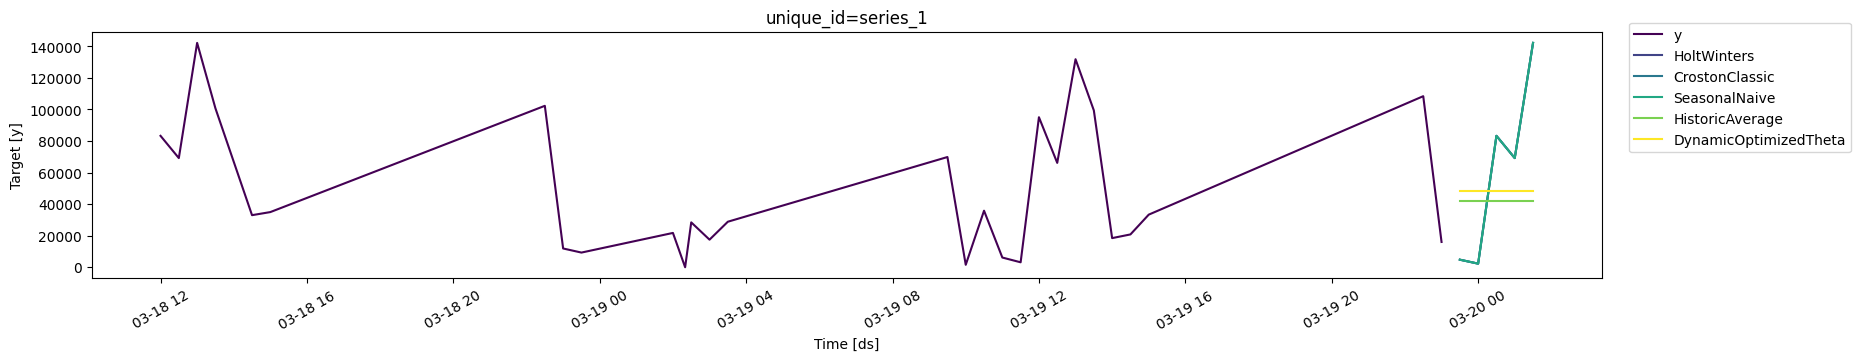

In [ ]:
#Broader view of above prediction
TS["ds"]= pd.to_datetime(TS["ds"], errors="coerce")
plot_series(
    df= TS,
    forecasts_df=future2,
    palette="viridis",
    max_insample_length= 28
)

In [ ]:
#stat.forecast(df= evaluation_cv_results,h= 28)

In [ ]:
# Dropping "Cutoff" column from cv_df column
cv_df1= cv_df.drop("cutoff",axis=1)

In [ ]:
##Plotting Model-"SeasonalNaive" with confidence interval=90%
cv_df1["ds"]=cv_df1["ds"].astype("str")
b=stat.forecast(df= cv_df1,h=minute, level=[90])
b.head()

/usr/local/lib/python3.12/dist-packages/statsforecast/utils.py:244: UserWarning:

Historical data (12) is shorter than season_length (30). Forecasts for positions without observations will be filled with NaN.



,unique_id,ds,HoltWinters,HoltWinters-lo-90,HoltWinters-hi-90,CrostonClassic,CrostonClassic-lo-90,CrostonClassic-hi-90,SeasonalNaive,SeasonalNaive-lo-90,SeasonalNaive-hi-90,HistoricAverage,HistoricAverage-lo-90,HistoricAverage-hi-90,DynamicOptimizedTheta,DynamicOptimizedTheta-lo-90,DynamicOptimizedTheta-hi-90
0,series_1,2025-03-19 23:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38049.75,-22518.302663,98617.802663,38843.597603,-21461.326172,103254.812500
1,series_1,2025-03-20 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38049.75,-22518.302663,98617.802663,38843.597603,-21830.441406,104725.359375
2,series_1,2025-03-20 00:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38049.75,-22518.302663,98617.802663,38843.597603,-28745.767578,98806.875000
3,series_1,2025-03-20 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38049.75,-22518.302663,98617.802663,38843.597603,-35514.125000,102844.117188
4,series_1,2025-03-20 01:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38049.75,-22518.302663,98617.802663,38843.597603,-28186.408203,89521.226562


In [ ]:
#Dropping "unique_id" column from cv_df
cv_df= cv_df.drop("unique_id", axis=1)

In [ ]:
##Extracting hour, minute and second from "ds" column
import datetime as dt
cv_df["hour"]= cv_df["ds"].dt.hour
cv_df["min"]= cv_df["ds"].dt.minute
#cv_df1["Day_of_week"]= cv_df["ds"].dt.dayofweek # for day of week
#cv_df1["Day_of_week"]= cv_df["ds"].dt.dayofmonth # for day of month

In [ ]:
cv_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   ds                     12 non-null     datetime64[ns]
 1   cutoff                 12 non-null     datetime64[ns]
 2   y                      12 non-null     float64       
 3   HoltWinters            6 non-null      float64       
 4   CrostonClassic         12 non-null     float64       
 5   SeasonalNaive          6 non-null      float64       
 6   HistoricAverage        12 non-null     float64       
 7   DynamicOptimizedTheta  12 non-null     float64       
 8   hour                   12 non-null     int32         
 9   min                    12 non-null     int32         
dtypes: datetime64[ns](2), float64(6), int32(2)
memory usage: 996.0 bytes


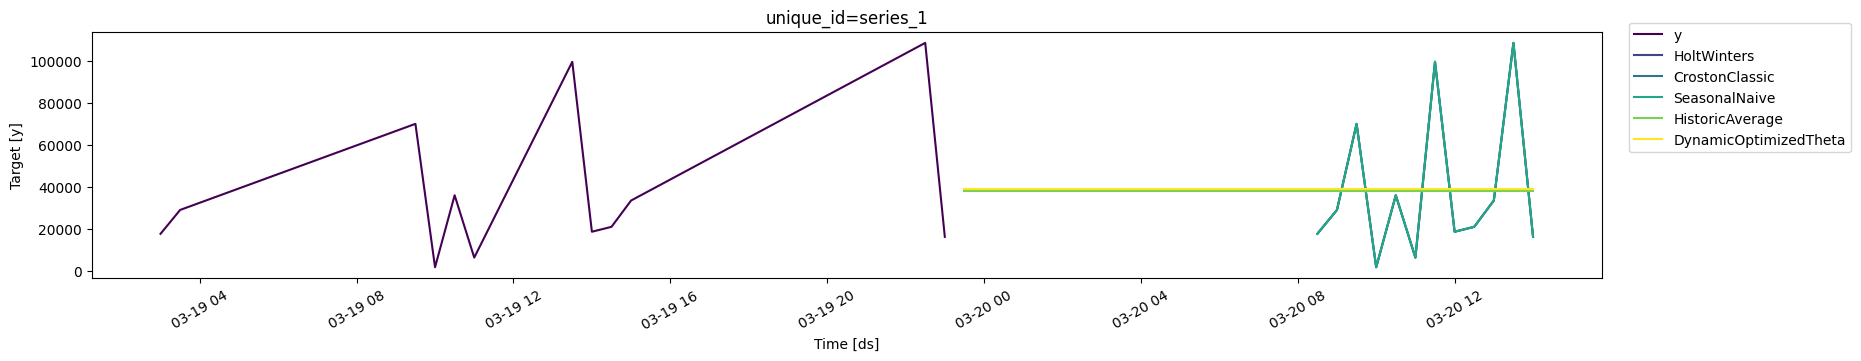

In [ ]:
#Broader view of above prediction
cv_df1["ds"]= pd.to_datetime(cv_df1["ds"],errors="coerce")
plot_series(
    df= cv_df1,
    forecasts_df=b,
    palette="viridis",
    max_insample_length= 28
)

In [ ]:
cv_df2= cv_df.drop(columns=["ds","cutoff"])

In [ ]:
#Scaling the data
from sklearn.preprocessing import StandardScaler
sc= StandardScaler()
cv_df_scaled= sc.fit_transform(cv_df2)
cv_df_scaled= pd.DataFrame(cv_df_scaled)

In [ ]:
b= b.astype("str")

In [ ]:
cv_df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   unique_id              12 non-null     object        
 1   ds                     12 non-null     datetime64[ns]
 2   y                      12 non-null     float64       
 3   HoltWinters            6 non-null      float64       
 4   CrostonClassic         12 non-null     float64       
 5   SeasonalNaive          6 non-null      float64       
 6   HistoricAverage        12 non-null     float64       
 7   DynamicOptimizedTheta  12 non-null     float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 900.0+ bytes


Changing Datatype in order to concatenate

In [ ]:
b["unique_id"]= b["unique_id"].astype("str")
b["ds"]= b["ds"].astype("str")
cv_df1["HoltWinters"]= cv_df1["HoltWinters"].astype("float")
cv_df1["CrostonClassic"]= cv_df1["CrostonClassic"].astype("float")
cv_df1["SeasonalNaive"]= cv_df1["SeasonalNaive"].astype("float")
cv_df1["HistoricAverage"]= cv_df1["HistoricAverage"].astype("float")
cv_df1["DynamicOptimizedTheta"]= cv_df1["DynamicOptimizedTheta"].astype("float")

In [ ]:
b["ds"]= b["ds"].astype("str")
b["HoltWinters"]= b["HoltWinters"].astype("float")
b["HoltWinters-lo-90"]= b['HoltWinters-lo-90'].astype("float")
b["HoltWinters-hi-90"]= b['HoltWinters-hi-90'].astype("float")
b["CrostonClassic"]= b["CrostonClassic"].astype("float")
b["CrostonClassic-lo-90"]= b["CrostonClassic-lo-90"].astype("float")
b["CrostonClassic-hi-90"]= b["CrostonClassic-lo-90"].astype("float")
b["SeasonalNaive"]= b["SeasonalNaive"].astype("float")
b["SeasonalNaive-lo-90"]= b["SeasonalNaive-lo-90"].astype("float")
b["SeasonalNaive-hi-90"]= b["SeasonalNaive-hi-90"].astype("float")
b["HistoricAverage"]= b["HistoricAverage"].astype("float")
b["HistoricAverage-lo-90"]= b["HistoricAverage-lo-90"].astype("float")
b["HistoricAverage-hi-90"]=b["HistoricAverage-hi-90"].astype("float")
b["DynamicOptimizedTheta"]= b["DynamicOptimizedTheta"].astype("float")
b["DynamicOptimizedTheta-lo-90"]= b["DynamicOptimizedTheta-lo-90"].astype("float")
b["DynamicOptimizedTheta-hi-90"]= b["DynamicOptimizedTheta-hi-90"].astype("float")

In [ ]:
b.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   unique_id                    30 non-null     object 
 1   ds                           30 non-null     object 
 2   HoltWinters                  12 non-null     float64
 3   HoltWinters-lo-90            12 non-null     float64
 4   HoltWinters-hi-90            12 non-null     float64
 5   CrostonClassic               12 non-null     float64
 6   CrostonClassic-lo-90         12 non-null     float64
 7   CrostonClassic-hi-90         12 non-null     float64
 8   SeasonalNaive                12 non-null     float64
 9   SeasonalNaive-lo-90          12 non-null     float64
 10  SeasonalNaive-hi-90          12 non-null     float64
 11  HistoricAverage              30 non-null     float64
 12  HistoricAverage-lo-90        30 non-null     float64
 13  HistoricAverage-hi-90 

In [ ]:
cv_df1["ds"]= cv_df1["ds"].astype("str")
cv_df_= cv_df1+b

In [ ]:
future3=stat.forecast(df=TS_final, h=minute, level=[90])
future3.head()

,unique_id,ds,HoltWinters,HoltWinters-lo-90,HoltWinters-hi-90,CrostonClassic,CrostonClassic-lo-90,CrostonClassic-hi-90,SeasonalNaive,SeasonalNaive-lo-90,SeasonalNaive-hi-90,HistoricAverage,HistoricAverage-lo-90,HistoricAverage-hi-90,DynamicOptimizedTheta,DynamicOptimizedTheta-lo-90,DynamicOptimizedTheta-hi-90
0,series_1,2025-03-19 23:30:00,4838.0,-109880.95405,119556.95405,4838.0,-109880.95405,119556.95405,4838.0,-109880.95405,119556.95405,42242.9,-26098.682799,110584.482799,48612.020421,-14678.710938,116212.343750
1,series_1,2025-03-20 00:00:00,2330.0,-112388.95405,117048.95405,2330.0,-112388.95405,117048.95405,2330.0,-112388.95405,117048.95405,42242.9,-26098.682799,110584.482799,48612.020421,-15066.103516,117755.710938
2,series_1,2025-03-20 00:30:00,83306.0,-31412.95405,198024.95405,83306.0,-31412.95405,198024.95405,83306.0,-31412.95405,198024.95405,42242.9,-26098.682799,110584.482799,48612.020421,-22323.816406,111544.187500
3,series_1,2025-03-20 01:00:00,69208.0,-45510.95405,183926.95405,69208.0,-45510.95405,183926.95405,69208.0,-45510.95405,183926.95405,42242.9,-26098.682799,110584.482799,48612.020421,-29427.287109,115781.320312
4,series_1,2025-03-20 01:30:00,142194.0,27475.04595,256912.95405,142194.0,27475.04595,256912.95405,142194.0,27475.04595,256912.95405,42242.9,-26098.682799,110584.482799,48612.020421,-21736.765625,101798.789062


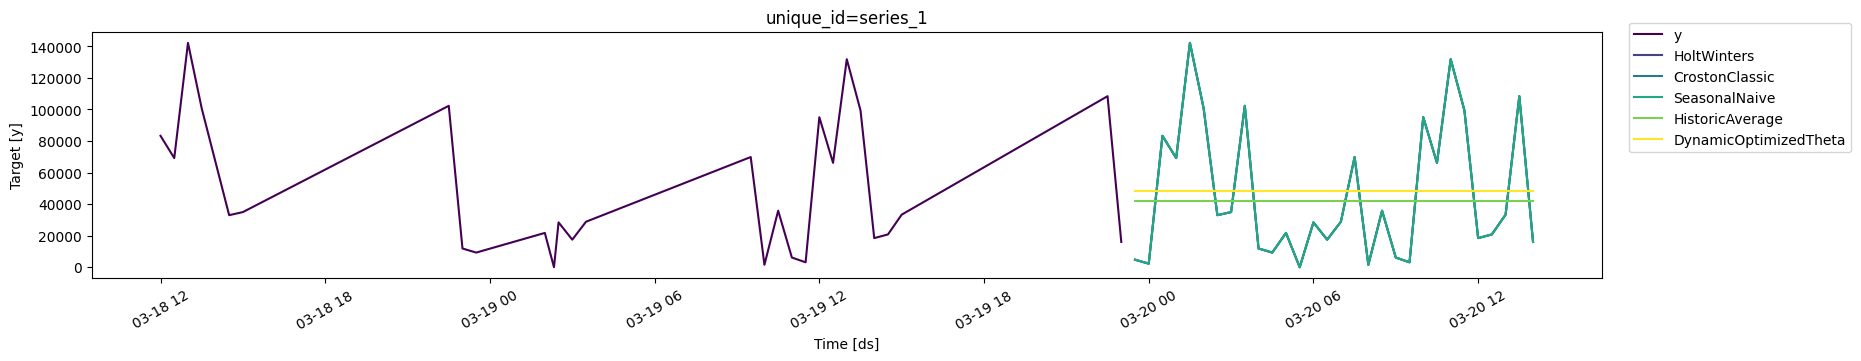

In [ ]:
#Broader view of above prediction
plot_series(
    df= TS_final,
    forecasts_df=future3,
    palette="viridis",
    max_insample_length= 28
)

In [ ]:
ts["CUT OFF TIME"].describe()

,CUT OFF TIME
count,1918
unique,31
top,9:30
freq,286


In [ ]:
ts_.columns

Index(['S.R  NO.', 'Lane', 'DISPATCHED FROM', 'SHIFT', 'GATE PASS NO.',
       'GATE IN DATE', 'GATE IN TIME', 'DOCK IN DATE', 'DOCK IN TIME',
       'DOCK OUT DATE', 'DOCK OUT TIME', 'GATE OUT DATE', 'GATE OUT TIME',
       'CUT OFF TIME', 'COC', 'CM', 'Bag Qty\n(As Per ERP)',
       'Large Shipment \nBag(QTY)', 'IT & STOCK & EKL BAG', 'TOTAL BAGS',
       'SHIPMENT', 'WT.', 'Trip ID', 'SPILL OVER BAG DETAIL', 'Vendor Name',
       'Vehicle No', 'DOCK NO', 'Description', 'SIZE', 'KILO METER',
       'Adhoc/Regular', 'DRIVER NAME', 'Contact No.', 'Seal No.',
       'Prealert Status', 'VEHICLE LOAD BY', 'Report Created By',
       'CUT_OFF_TIME', 'Diff1', 'Diff1_', 'Differen1', 'Diff2', 'Diff2_',
       'Diff3', 'Diff3_', 'Diff1_absolute', 'Diff1_log', 'Diff1_log_',
       'SHIPMENT_', 'Diff1_absolute_', 'Diff1_log_absolute', 'SHIPMENT_linear',
       'SHIPMENT_NA', 'SHIPMENT_0', 'moving_Average', 'Moving_Average',
       'exp_movingaverage', 'ds'],
      dtype='object')

In [ ]:
a= ts_[ts_["CUT OFF TIME"]!= ts_["CUT_OFF_TIME"]]
a.describe()

,S.R NO.,CM,Bag Qty\n(As Per ERP),Large Shipment \nBag(QTY),TOTAL BAGS,SHIPMENT,SPILL OVER BAG DETAIL,DOCK NO,Contact No.,Diff1,...,Diff1_log_,SHIPMENT_,Diff1_absolute_,Diff1_log_absolute,SHIPMENT_linear,SHIPMENT_NA,SHIPMENT_0,moving_Average,Moving_Average,exp_movingaverage
count,1997.000000,1.950000e+03,1950.000000,1950.000000,1997.000000,1949.000000,1950.000000,1950.000000,1.950000e+03,1947.000000,...,1.997000e+03,1.949000e+03,1997.000000,1997.000000,1997.000000,1997.000000,1997.000000,1991.000000,1991.000000,1997.000000
mean,497.838758,2.227152e+08,29.476923,33.556923,65.676515,929.008209,0.097436,32.690769,8.591774e+09,2.023112,...,-1.138576e-16,1.458271e-17,0.000000,0.817442,998.882323,906.678518,906.678518,995.551123,995.551123,981.682249
std,288.690614,1.375631e+05,87.264401,117.735211,139.051585,2769.951722,3.041654,7.709667,2.416036e+09,3773.257506,...,1.000250e+00,1.000257e+00,1.000250,0.576155,2773.561603,2740.141663,2740.141663,1448.439518,1448.439518,1172.002798
min,1.000000,2.224701e+08,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,7.484974e+08,-26684.000000,...,-1.646479e+00,-3.351128e-01,-0.435312,0.000718,1.000000,0.000000,0.000000,11.571429,11.571429,124.227581
25%,250.000000,2.225656e+08,0.000000,0.000000,4.000000,16.000000,0.000000,29.000000,7.895495e+09,-417.500000,...,-6.098165e-01,-3.296962e-01,-0.423892,0.297556,17.000000,14.000000,14.000000,205.357143,205.357143,246.182169
50%,495.000000,2.227364e+08,2.000000,0.000000,18.000000,57.000000,0.000000,33.000000,8.826480e+09,-12.000000,...,-7.954455e-02,-3.148907e-01,-0.324045,0.746281,61.000000,54.000000,54.000000,297.571429,297.571429,341.582000
75%,745.000000,2.227939e+08,17.000000,16.000000,43.000000,571.000000,0.000000,38.000000,9.518272e+09,408.500000,...,8.385299e-01,-1.292803e-01,-0.161829,1.214927,638.000000,559.000000,559.000000,962.928571,962.928571,1305.374315
max,1043.000000,2.229430e+08,786.000000,1001.000000,1001.000000,26964.000000,95.000000,60.000000,7.066518e+10,26809.000000,...,2.361125e+00,9.401490e+00,7.414573,2.361125,26964.000000,26964.000000,26964.000000,8353.714286,8353.714286,5832.786455


In [ ]:
#Overlapping columns between two dataframe
ol= set(TS.columns)and set(future.columns)
ol

{'ARIMA_no_Season',
 'HistoricAverage',
 'Naive',
 'SeasonalNaive',
 'WindowAverage',
 'ds',
 'unique_id'}

In [ ]:
complete= pd.concat([TS, future1],join="outer", keys=["unique_id","ds"])
complete.columns
complete_= complete[complete[['unique_id','ds','y','HoltWinters', 'CrostonClassic','SeasonalNaive','HistoricAverage', 'DynamicOptimizedTheta','AutoARIMA']].notnull()]
complete_.fillna(0)
complete_.head()

unique_id                  ds        y  HoltWinters  \
unique_id 0  series_1 2025-03-17 22:30:00   4034.0          NaN   
          1  series_1 2025-03-18 02:00:00  23475.0          NaN   
          2  series_1 2025-03-18 02:20:00      7.0          NaN   
          3  series_1 2025-03-18 02:30:00  24369.0          NaN   
          4  series_1 2025-03-18 03:00:00  15262.0          NaN   

             CrostonClassic  SeasonalNaive  HistoricAverage  \
unique_id 0             NaN            NaN              NaN   
          1             NaN            NaN              NaN   
          2             NaN            NaN              NaN   
          3             NaN            NaN              NaN   
          4             NaN            NaN              NaN   

             DynamicOptimizedTheta  AutoARIMA  
unique_id 0                    NaN        NaN  
          1                    NaN        NaN  
          2                    NaN        NaN  
          3                    NaN        NaN  
          4                    NaN        NaN

In [ ]:
complete.columns

Index(['unique_id', 'ds', 'y', 'HoltWinters', 'CrostonClassic',
       'SeasonalNaive', 'HistoricAverage', 'DynamicOptimizedTheta',
       'AutoARIMA'],
      dtype='object')

In [ ]:
"""complete["GATE IN DATE"]= complete["GATE IN DATE"].to_numpy()
complete["ds"]= complete["ds"].to_numpy()"""

'complete["GATE IN DATE"]= complete["GATE IN DATE"].to_numpy()\ncomplete["ds"]= complete["ds"].to_numpy()'

In [ ]:
complete.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 70 entries, ('unique_id', np.int64(0)) to ('ds', np.int64(29))
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   unique_id              70 non-null     object        
 1   ds                     70 non-null     datetime64[ns]
 2   y                      40 non-null     float64       
 3   HoltWinters            30 non-null     float64       
 4   CrostonClassic         30 non-null     float64       
 5   SeasonalNaive          30 non-null     float64       
 6   HistoricAverage        30 non-null     float64       
 7   DynamicOptimizedTheta  30 non-null     float64       
 8   AutoARIMA              30 non-null     float64       
dtypes: datetime64[ns](1), float64(7), object(1)
memory usage: 6.6+ KB


In [ ]:
for col in complete.columns:
  print(col)
##complete[["Naive"]]= complete["Naive"].copy()

unique_id
ds
y
HoltWinters
CrostonClassic
SeasonalNaive
HistoricAverage
DynamicOptimizedTheta
AutoARIMA


In [ ]:
#Defining columns according to evaluation metrics
def evaluate_cv(complete_, metric):
    Models = complete_.columns.drop(['unique_id', 'ds', 'y']).tolist()
    Evals = evaluate(complete_, metrics=[metric], models=Models)
    Evals = Evals.drop(columns=['metric'])
    Evals['best_model'] = Evals[Models].idxmin(axis=1)
    return Evals

In [ ]:
from utilsforecast.losses import mse
evaluation_df = evaluate_cv(complete_, mae)
evaluation_df.head()

/tmp/ipykernel_1142/2480173871.py:6: FutureWarning:

The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError



,unique_id,HoltWinters,CrostonClassic,SeasonalNaive,HistoricAverage,DynamicOptimizedTheta,AutoARIMA,best_model
0,series_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Let's evaluate above while splitting the dataset into train and test data

In [ ]:
# Splitting the data into training and testing sets
# The last 'minute' (30) observations will be used for testing
n_test_points = minute
train_df = TS_final.iloc[:-n_test_points].copy()
test_df = TS_final.iloc[-n_test_points:].copy()
print(train_df)

"""# Fit the StatsForecast model on the training data
stat.fit(df=train_df)

# Generate forecasts for the test period
forecast_test = stat.predict(h=n_test_points)

# Merge the actual test values with the forecasts for evaluation
# The 'evaluate' function expects a DataFrame containing 'ds', 'unique_id', 'y' (actuals), and model predictions
evaluation_df = pd.merge(test_df, forecast_test, on=['unique_id', 'ds'], how='left')

# Print head of evaluation_df to inspect (optional)
# print("Evaluation DataFrame Head:")
# print(evaluation_df.head())
# print("\nNumber of missing values in evaluation_df after merge:")
# print(evaluation_df.isnull().sum())
"""

  unique_id                  ds         y
0  series_1 2025-03-17 22:30:00    4034.0
1  series_1 2025-03-18 02:00:00   23475.0
2  series_1 2025-03-18 02:20:00       7.0
3  series_1 2025-03-18 02:30:00   24369.0
4  series_1 2025-03-18 03:00:00   15262.0
5  series_1 2025-03-18 03:30:00   25053.0
6  series_1 2025-03-18 04:00:00  111665.0
7  series_1 2025-03-18 09:30:00   57665.0
8  series_1 2025-03-18 10:00:00    1448.0
9  series_1 2025-03-18 10:30:00   29265.0


'# Fit the StatsForecast model on the training data\nstat.fit(df=train_df)\n\n# Generate forecasts for the test period\nforecast_test = stat.predict(h=n_test_points)\n\n# Merge the actual test values with the forecasts for evaluation\n# The \'evaluate\' function expects a DataFrame containing \'ds\', \'unique_id\', \'y\' (actuals), and model predictions\nevaluation_df = pd.merge(test_df, forecast_test, on=[\'unique_id\', \'ds\'], how=\'left\')\n\n# Print head of evaluation_df to inspect (optional)\n# print("Evaluation DataFrame Head:")\n# print(evaluation_df.head())\n# print("\nNumber of missing values in evaluation_df after merge:")\n# print(evaluation_df.isnull().sum())\n'

In [ ]:
#Removing "unique_id" from index
complete= complete.reset_index(drop=True)
complete.tail()

,unique_id,ds,y,HoltWinters,CrostonClassic,SeasonalNaive,HistoricAverage,DynamicOptimizedTheta,AutoARIMA
65,series_1,2025-03-22 03:00:00,NaN,44191.778754,47866.155962,6203.0,42242.9,48612.020421,41465.041071
66,series_1,2025-03-22 05:00:00,NaN,95689.224756,47866.155962,3179.0,42242.9,48612.020421,41465.041071
67,series_1,2025-03-22 07:00:00,NaN,86712.092289,47866.155962,95103.0,42242.9,48612.020421,41465.041071
68,series_1,2025-03-22 09:00:00,NaN,48350.246237,47866.155962,66168.0,42242.9,48612.020421,41465.041071
69,series_1,2025-03-22 11:00:00,NaN,89982.874780,47866.155962,131850.0,42242.9,48612.020421,41465.041071


In [ ]:
X= cv_df[["cutoff","y"]]
Y= cv_df["SeasonalNaive"]
# The 'complete' DataFrame is empty due to non-overlapping time ranges in the merge.
final= evaluate(
    complete,
    #complete.drop(["GATE IN DATE", "ds"],axis=1),
    metrics=[mae],
)
final.tail()
#X_train.tail()

,unique_id,metric,HoltWinters,CrostonClassic,SeasonalNaive,HistoricAverage,DynamicOptimizedTheta,AutoARIMA
0,series_1,mae,NaN,NaN,NaN,NaN,NaN,NaN


1.

In [ ]:
X= cv_df[["cutoff","y"]]
Y= cv_df["SeasonalNaive"]

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test= train_test_split(X,Y, test_size= 0.3, random_state= 42)

<Axes: >

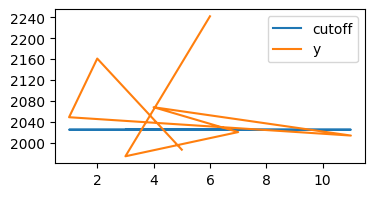

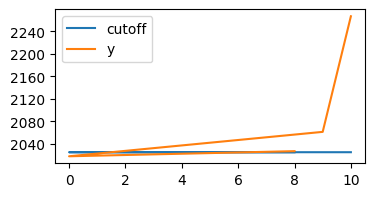

In [ ]:
#Plotting the X_train, X_test
X_train.plot(legend="train_X", figsize=(4,2))
X_test.plot(legend="test_X",figsize=(4,2))

<Axes: >

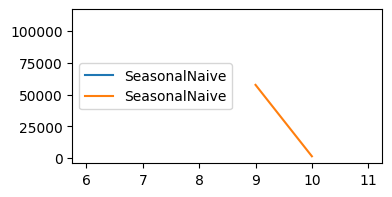

In [ ]:
#Plotting the X_train, X_test
Y_train.plot(legend="train_Y", figsize=(4,2))
Y_test.plot(legend="test_Y",figsize=(4,2))

##2. Parameters "ds" and "y as input and "Seasonal Naive" as output to get patterns for future forecasting.

Further could try with different models as output to get relevant pattern according to the dataset

In [ ]:
#Adding values with duplicate index values using groupby
cv_df['y_tot'] = cv_df.groupby('ds')['y'].transform('sum')

In [ ]:
#Adding values with duplicate index values using groupby
cv_df['SeasonalNaive_tot'] = cv_df.groupby('ds')['SeasonalNaive'].transform('sum')

#Hereby dropping duplicate values from "ds"
cv_df = cv_df.drop_duplicates(subset=['ds'])

In [ ]:
x= cv_df[["ds","y_tot"]]
y= cv_df["SeasonalNaive_tot"]

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(x,y, test_size= 0.3, random_state= 42)

<Axes: >

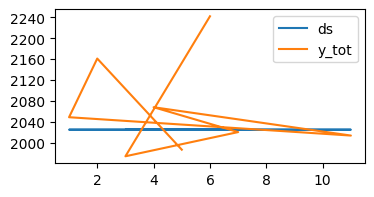

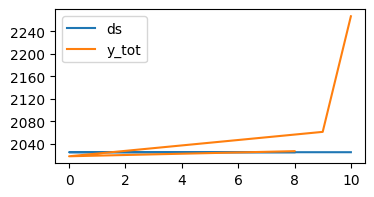

In [ ]:
#Plotting the X_train, X_test
x_train.plot(legend="train_x", figsize=(4,2))
x_test.plot(legend="test_x",figsize=(4,2))

<Axes: >

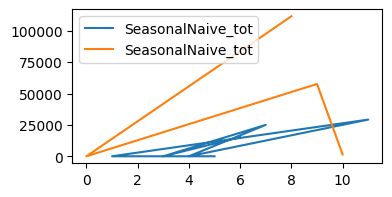

In [ ]:
#Plotting the X_train, X_test
y_train.plot(legend="train_y", figsize=(4,2))
y_test.plot(legend="test_y",figsize=(4,2))

##3. Parameters "cutoff" and "ds" as inputs and "y" as output to get patterns for future forecasting with respect to specific time for other factors like breach.

Further could try with different models as output to get relevant pattern according to the dataset

In [ ]:
X1= cv_df[["cutoff","ds"]]
Y1= cv_df["y"]

In [ ]:
from sklearn.model_selection import train_test_split
X1_train, X1_test, Y1_train, Y1_test= train_test_split(X1,Y1, test_size= 0.3, random_state= 42)

<Axes: >

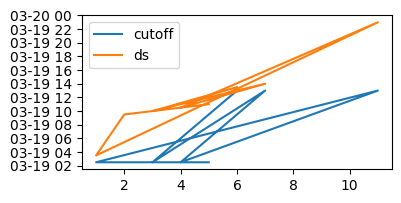

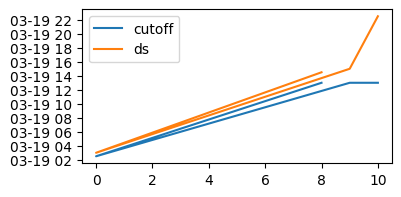

In [ ]:
#Plotting the X1_train, X1_test
X1_train.plot(legend="train_x", figsize=(4,2))
X1_test.plot(legend="test_x",figsize=(4,2))

<Axes: >

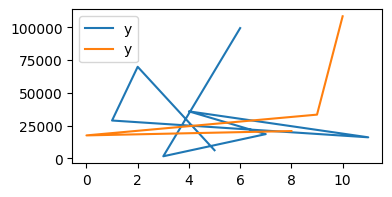

In [ ]:
#Plotting the Y1_train, Y1_test
Y1_train.plot(legend="train_Y1", figsize=(4,2))
#Y1_train.plot(label="train_Y1")
Y1_test.plot(legend="test_Y1",figsize=(4,2))
#Y1_test.plot(label="test_Y1")

##Model 3: AutoARIMA

In [ ]:
from statsforecast.models import AutoARIMA
sf = StatsForecast(
    models=[AutoARIMA(season_length=12)],
    freq='ME',
)
sf.fit(TS_final)
sf.predict(h=12, level=[95])

,unique_id,ds,AutoARIMA,AutoARIMA-lo-95,AutoARIMA-hi-95
0,series_1,2025-03-31 23:00:00,28131.760504,-50107.635867,106371.156875
1,series_1,2025-04-30 23:00:00,41465.041071,-40071.172372,123001.254514
2,series_1,2025-05-31 23:00:00,41465.041071,-40071.172372,123001.254514
3,series_1,2025-06-30 23:00:00,41465.041071,-40071.172372,123001.254514
4,series_1,2025-07-31 23:00:00,41465.041071,-40071.172372,123001.254514
5,series_1,2025-08-31 23:00:00,41465.041071,-40071.172372,123001.254514
6,series_1,2025-09-30 23:00:00,41465.041071,-40071.172372,123001.254514
7,series_1,2025-10-31 23:00:00,41465.041071,-40071.172372,123001.254514
8,series_1,2025-11-30 23:00:00,41465.041071,-40071.172372,123001.254514
9,series_1,2025-12-31 23:00:00,41465.041071,-40071.172372,123001.254514


## TRAJECTORY SIMULATION

In [ ]:
pip install simulate==0.1.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.8/138.8 kB 6.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-3.1.0-py3-none-any.whl.metadata (10 kB)
  Using cached scikit_build-0.19.1-py3-none-any.whl.metadata (21 kB)
Using cached pybind11-3.1.0-py3-none-any.whl (319 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 64.8 MB/s eta 0:00:00
Using cached scikit_build-0.19.1-py3-none-any.whl (86 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.0/146.0 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.7/234.7 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.0/273.0 kB 24.0 MB/s eta 0:00:00
  Created wheel for simulate: filename=simulate-0.1.2-py3-none-any.whl size=220778 sha256=7c7726021765c0d55d5a30cbd4caf19f42ff5ae7f1ede423474d

Trajectory simulation allows to generate multiple possible future realizations of a time series based on the fitted model’s error distribution.

This is particularly useful for: - Risk analysis and stress testing. - Scenario planning (e.g., “what if” analyses). - Calculating complex metrics based on future paths (e.g., probability of breach).

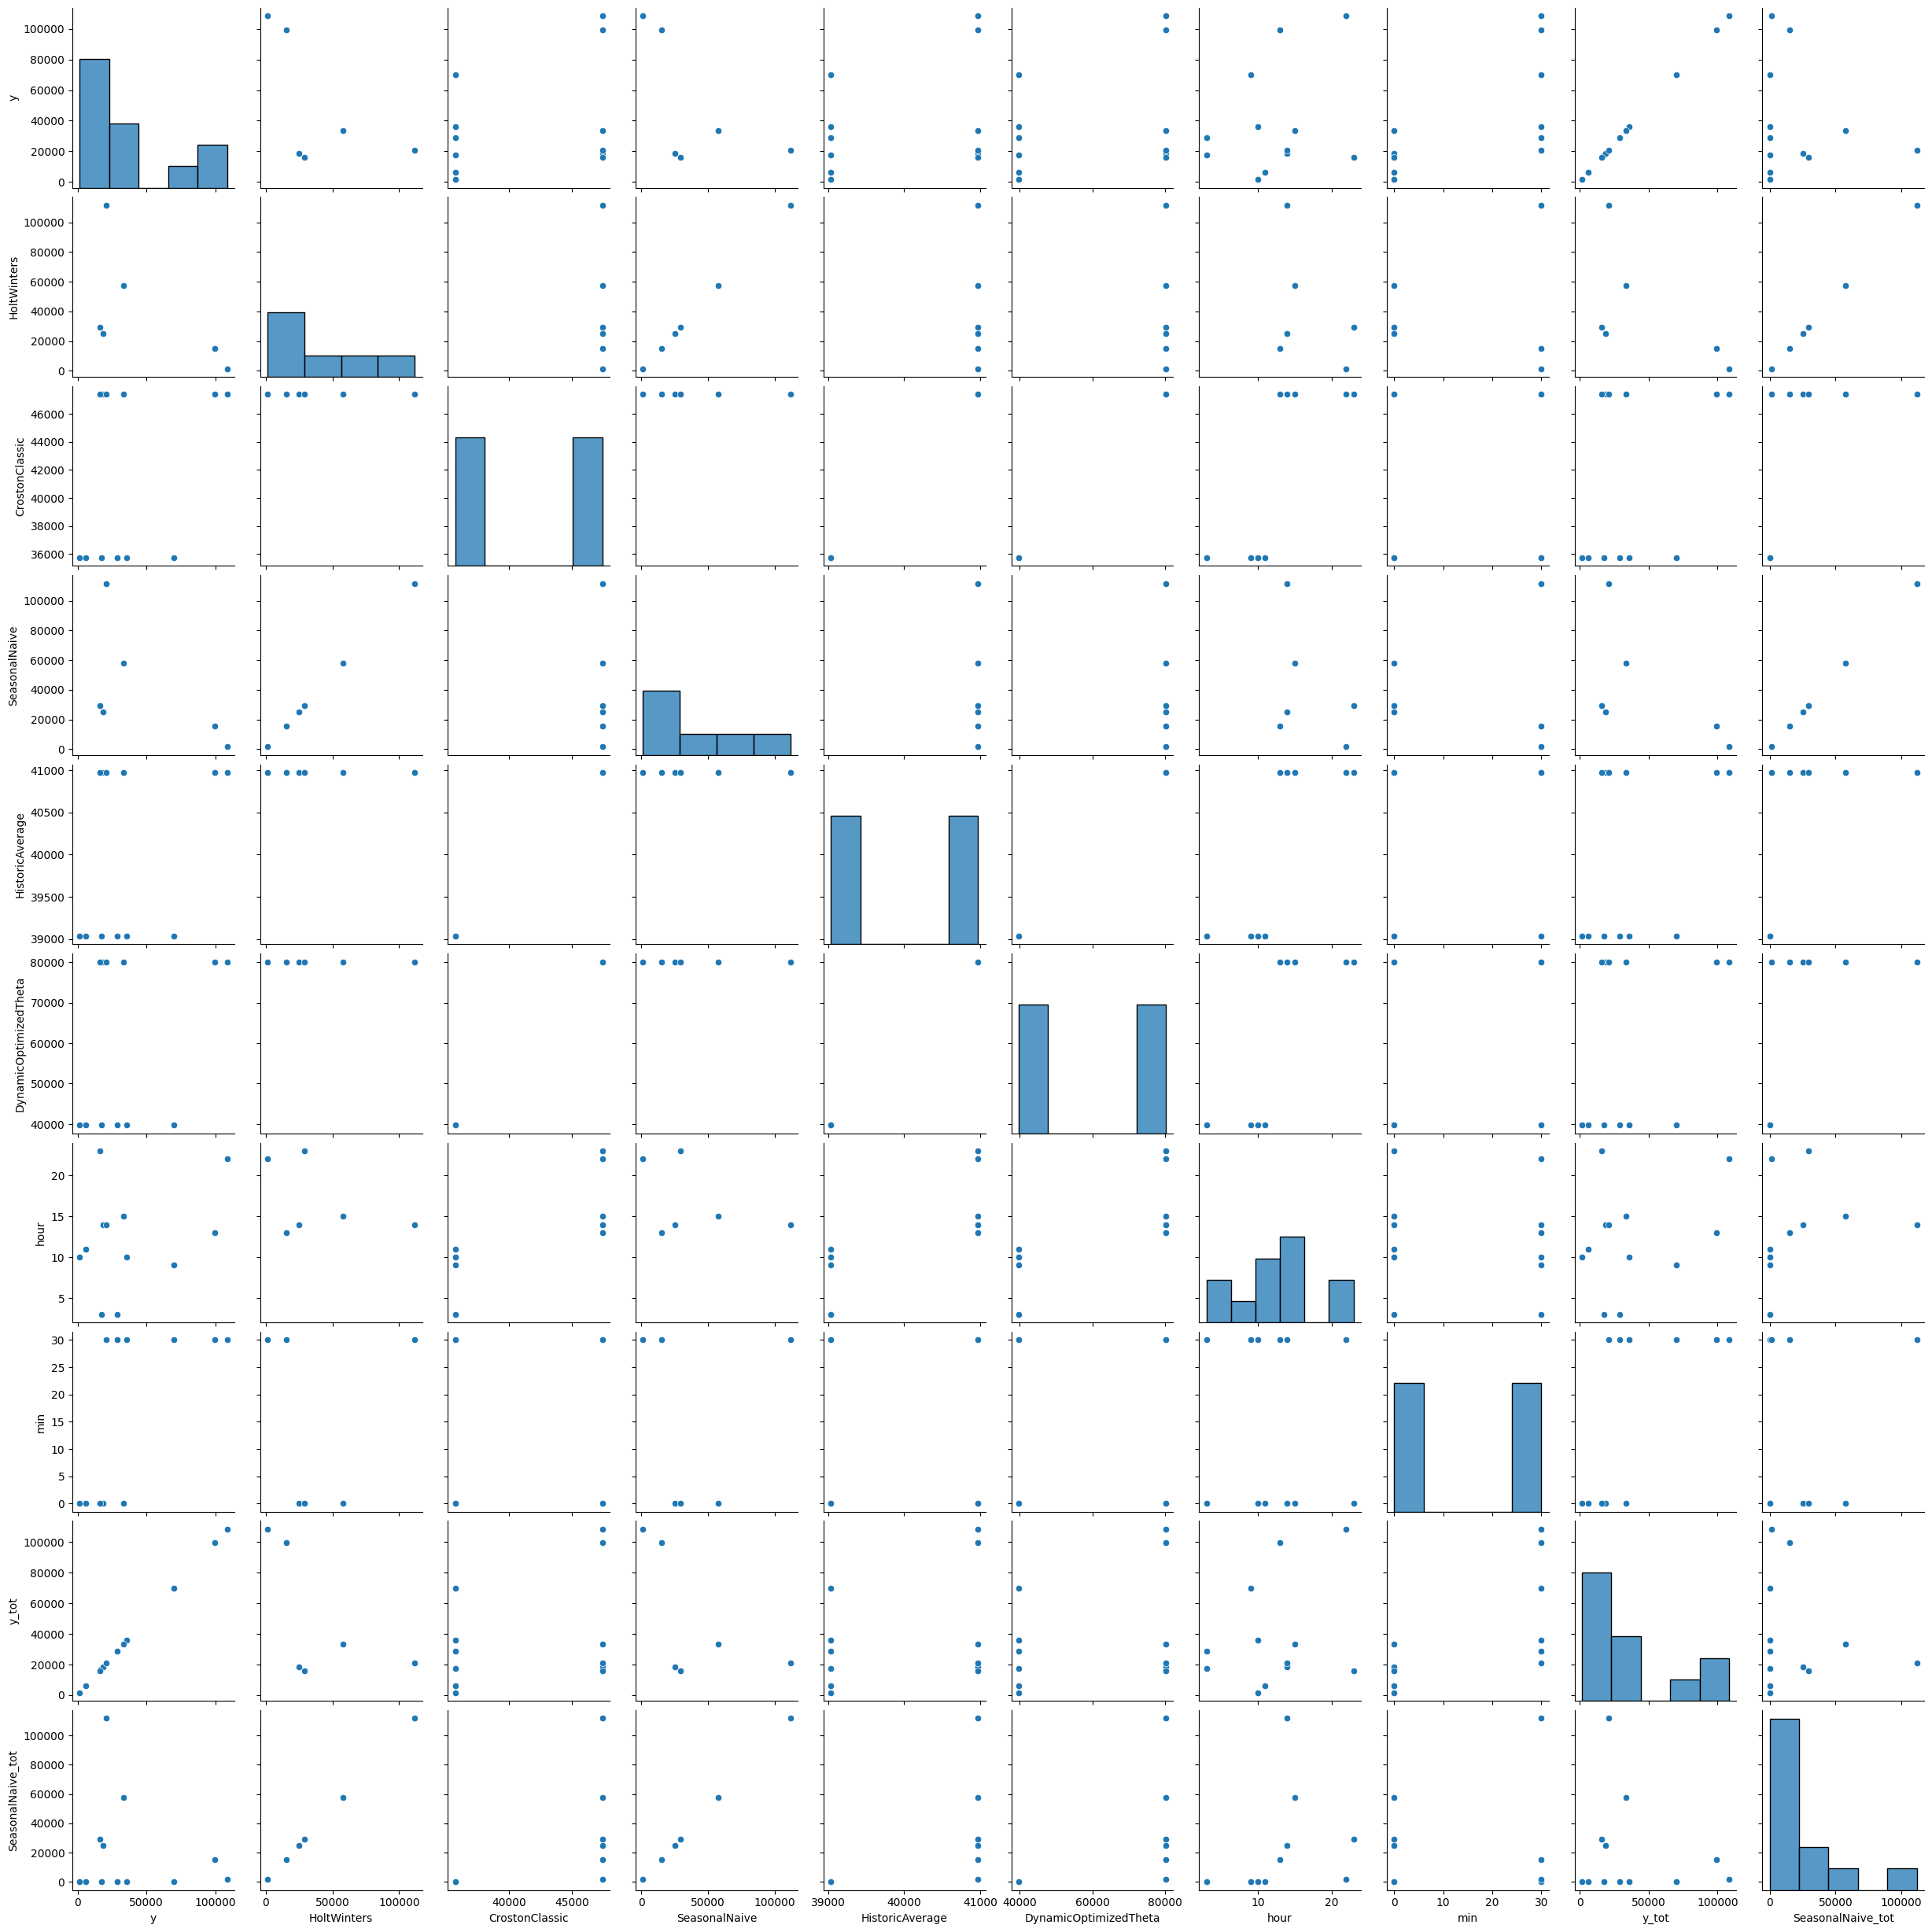

In [ ]:
#import scikit-learn as skl
import seaborn as sns
g = sns.pairplot(cv_df)
g

In [ ]:
pip install huggingface-hub==0.25.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 436.6/436.6 kB 14.8 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.23.0
    Uninstalling huggingface_hub-1.23.0:
      Successfully uninstalled huggingface_hub-1.23.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
diffusers 0.39.0 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 0.25.2 which is incompatible.
transformers 5.13.1 requires huggingface-hub<2.0,>=1.5.0, but you have huggingface-hub 0.25.2 which is incompatible.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.25.2 which is incompatible.


In [ ]:
import huggingface_hub
from huggingface_hub import hf_hub_download
from huggingface_hub import constants
from huggingface_hub.constants import HF_HUB_CACHE

In [ ]:
TS_final1= TS_final.reset_index()
TS_final1= TS_final1.drop(columns=["unique_id"])
TS_final1= TS_final1.to_numpy(dtype=float) # Ensures numeric dtype
TS_final1

array([[0.0000000e+00, 1.7422506e+18, 4.0340000e+03],
       [1.0000000e+00, 1.7422632e+18, 2.3475000e+04],
       [2.0000000e+00, 1.7422644e+18, 7.0000000e+00],
       [3.0000000e+00, 1.7422650e+18, 2.4369000e+04],
       [4.0000000e+00, 1.7422668e+18, 1.5262000e+04],
       [5.0000000e+00, 1.7422686e+18, 2.5053000e+04],
       [6.0000000e+00, 1.7422704e+18, 1.1166500e+05],
       [7.0000000e+00, 1.7422902e+18, 5.7665000e+04],
       [8.0000000e+00, 1.7422920e+18, 1.4480000e+03],
       [9.0000000e+00, 1.7422938e+18, 2.9265000e+04],
       [1.0000000e+01, 1.7422956e+18, 4.8380000e+03],
       [1.1000000e+01, 1.7422974e+18, 2.3300000e+03],
       [1.2000000e+01, 1.7422992e+18, 8.3306000e+04],
       [1.3000000e+01, 1.7423010e+18, 6.9208000e+04],
       [1.4000000e+01, 1.7423028e+18, 1.4219400e+05],
       [1.5000000e+01, 1.7423046e+18, 1.0074200e+05],
       [1.6000000e+01, 1.7423082e+18, 3.3042000e+04],
       [1.7000000e+01, 1.7423100e+18, 3.4999000e+04],
       [1.8000000e+01, 1.742

In [ ]:
from scipy.stats import laplace
##Using laplace distribution for simulation and forecasting the future values
##Estimating location and scaling using Maximum likelihoof estimator(MLE) for laplace forecasting
location, scaling= laplace.fit(TS_final1)
print(location)
print(scaling)

26765.5
1.742335170000031e+18


## INCORPORATING LAPLACE SIMULATION IN ABOVE DATAFRAME:
Laplace simulation is basically use instead of normal distribution when heavy tails are present.
In addition to this, it is mainly used for anomaly detection, Shock modeling, differential privacy, etc.

Here Shock modeling behaves as cyclicity term from time series component, where Shock modeling in time series involves various techniques to account for unexpected events that can disrupt the behavior of a time series. These shocks can be economic downturns, natural disasters, policy changes, pandemics, or market crashes.

In [ ]:
#Feature creation "noise" for laplace simulation
n_points=120
noise = np.random.normal(loc=1, scale=1.0, size=n_points) # can include Heavy tails(due to laplace) for stress testing
noise= noise.flatten()
TS_final1= TS_final1.flatten()
TS_final1_series= pd.Series(TS_final1)
final_Series= TS_final1_series + noise
final_Series= pd.Series(final_Series)

In [ ]:
#Declaring Laplace_noise and converting the above df into a Series for Final Calculation
scale=1
#laplace_noise = np.random.laplace(loc=0, scale=scale, size=len(final_Series))
Total= final_Series
print(Total)

0     -2.199473e-01
1      1.742251e+18
2      4.035520e+03
3      2.117824e+00
4      1.742263e+18
           ...     
115    1.742423e+18
116    1.084269e+05
117    3.990912e+01
118    1.742425e+18
119    1.607065e+04
Length: 120, dtype: float64


In [ ]:
#Fitting ARIMA model on above Laplace simulation
model = ARIMA(Total, order=(1,2,1),trend="n")
fitted_model = model.fit()
forecast = fitted_model.forecast(steps=48)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.



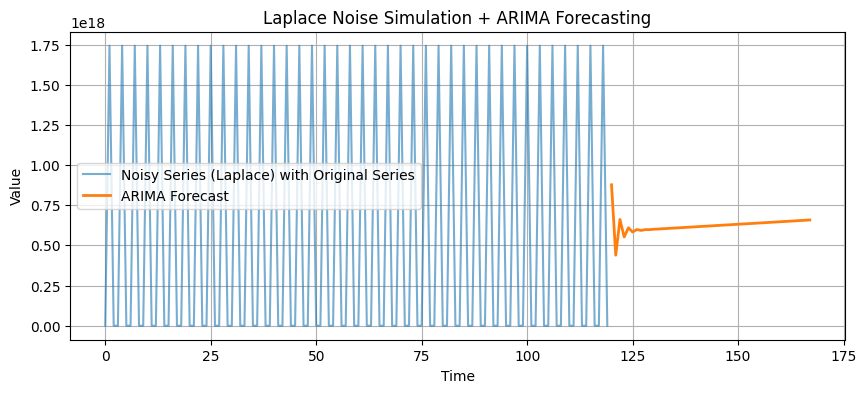

In [ ]:
#Plotting above forecasted model with noise
plt.figure(figsize=(10,4))
plt.plot(Total, label="Noisy Series (Laplace) with Original Series", alpha=0.6)
plt.plot(range(len(Total), len(Total) + len(forecast)), forecast, label="ARIMA Forecast", linewidth=2)
plt.legend()
plt.title("Laplace Noise Simulation + ARIMA Forecasting")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(True)
plt.show()

Above plot shows:

Adding laplace simulation has given non-linear curve as comparison to prediction from ARIMA model that was showing mean or median value as prediction for future steps. Further, using best parameter from ARIMA model using cross-validation, can provide the better forecasting behaviour in addition of above technique.

##Simulation: for more paths related to forecasting or prediction

In [ ]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA

In [ ]:
TS_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   unique_id  40 non-null     object        
 1   ds         40 non-null     datetime64[ns]
 2   y          40 non-null     float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 1.1+ KB


In [ ]:
# Initialize the model
models = [AutoARIMA(season_length=24)]
sf = StatsForecast(models=models, freq="H", n_jobs=1)

# Simulate 100 paths for a horizon of 48 hours
n_paths = 100
h = 48
# The simulation method handles the fitting (if needed) and the simulation
sims = sf.simulate(df=TS_final, h=h,n_paths=n_paths, time_col="ds",target_col="y", seed=42)

sims.head()

/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:406: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.

/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:462: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



,unique_id,ds,sample_id,AutoARIMA
0,series_1,2025-03-20 00:00:00,0,72650.431896
0,series_1,2025-03-20 01:00:00,0,113105.408981
0,series_1,2025-03-20 02:00:00,0,42679.857074
0,series_1,2025-03-20 03:00:00,0,118312.796253
0,series_1,2025-03-20 04:00:00,0,114415.258076


Simulation here refers to the possible different future paths for an observation.


*   Considering error distributions for paths
observability with respect to errors present in the data.

In [ ]:
#sims.predict(h=12, level=[85,95]) #Would calculate along with confidence interval

#Understanding error distribution in dataframe using simulation:

when one don't define any error distribution the model uses Maximum Likelihood Estimator(MLE) to define the distribution in the form of Automatic parameters inference.

This is particularly useful when one wants the simulation to reflect the actual characteristics of the data’s errors.



Supported Distributions

1. ‘normal’: Standard normal distribution (default)
2. ‘t’: Student’s t-distribution (heavy tails, good for financial data)
3. ‘bootstrap’: Resample from empirical residuals (non-parametric)
4. ‘laplace’: Laplace distribution (sharper peak, heavier tails)
5. ‘skew-normal’: Skewed normal distribution (for asymmetric errors)
6. ‘ged’: Generalized Error Distribution (flexible shape)

Considering different distributions according to the relationship between date_column(or input_column as an input) and the target_column(here "y").
Note that parameters are automatically estimated from residuals.

In [ ]:
#Plotting the relationship between "ds" and "y", hover around plot to deeply analyse
fig= px.line(TS_final, x="ds", y="y", height= 300, title="SHIPMENT with respect to CUTOFF")
fig.show()

Here I'm considering 3 cutoffs(09.00am, 14:00pm, 22:00pm) that was present in the organisation and accordingly go ahead with "skew-normal distribution" and "laplace distribution". One can consider according to their respective time(like hourly basis) or some interval of time(like cutoff) to opt for error distribution for automatic parameter inference.

In [ ]:
# Student's t-distribution with automatic parameter inference
# The degrees of freedom, location, and scale are automatically estimated from residuals
simul_skew_norm= sf.simulate(df= TS_final, n_paths= n_paths, h=h, time_col="ds" ,
                        target_col="y",error_distribution="skew-normal", seed= 42)
# No error_params specified - parameters inferred automatically
simul_skew_norm.head()

/usr/local/lib/python3.13/dist-packages/utilsforecast/processing.py:406: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.

/usr/local/lib/python3.13/dist-packages/utilsforecast/processing.py:462: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



,unique_id,ds,sample_id,AutoARIMA
0,series_1,2025-03-20 00:00:00,0,47243.432367
0,series_1,2025-03-20 01:00:00,0,49781.693768
0,series_1,2025-03-20 02:00:00,0,74992.050620
0,series_1,2025-03-20 03:00:00,0,62796.545281
0,series_1,2025-03-20 04:00:00,0,54268.524604


In [ ]:
#Automatic parameter inference using "laplace" error distribution
simul_laplace= sf.simulate(df= TS_final, n_paths= n_paths, h=h, time_col="ds",
                        target_col="y", error_distribution="laplace", seed= 42)
simul_laplace.head()

/usr/local/lib/python3.13/dist-packages/utilsforecast/processing.py:406: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.

/usr/local/lib/python3.13/dist-packages/utilsforecast/processing.py:462: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



,unique_id,ds,sample_id,AutoARIMA
0,series_1,2025-03-20 00:00:00,0,91871.874090
0,series_1,2025-03-20 01:00:00,0,87938.077861
0,series_1,2025-03-20 02:00:00,0,11923.956618
0,series_1,2025-03-20 03:00:00,0,115921.624248
0,series_1,2025-03-20 04:00:00,0,68892.404229


Interpretation:

As one can see from above the forecasted value using the above error distributions defined, resulted in huge difference with each other. Further, one can use interpolation techniques with respect to the forecasted value to come up with the best parameters to consider for overall analysis in terms of mean, median, mode, etc.

In [ ]:
#simul_bootstrap["AutoARIMA_laplace"]= simul_bootstrap["AutoARIMA"]
simulation= simul_laplace["AutoARIMA"]
simulation["skew_normal"]= simul_skew_norm["AutoARIMA"]
simulation["Normal"]= sims["AutoARIMA"]
simulation.head()
#simul= pd.merge(simul_bootstrap["AutoARIMA"],simul_auto["AutoARIMA"],sims["AutoARIMA"], how="outer")
#simul


/tmp/ipykernel_623/2543790512.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,AutoARIMA
0,91871.87409
0,87938.077861
0,11923.956618
0,115921.624248
0,68892.404229


Using this one could get range of values of forecasting, where simulation helps in understanding the variation of forecasted paths and to look for group formation on the base of range of values to consider for future expected result, through analysing error distribution.

In [ ]:
#simulation= simul_bootstrap["AutoARIMA"]
#Replacing column name to plot the above forecasted values
simulation["skew_normal"]= simul_skew_norm["AutoARIMA"]
#simulation["Normal"]= sims["AutoARIMA"]
simulation.head()

,AutoARIMA
0,91871.87409
0,87938.077861
0,11923.956618
0,115921.624248
0,68892.404229


<Axes: >

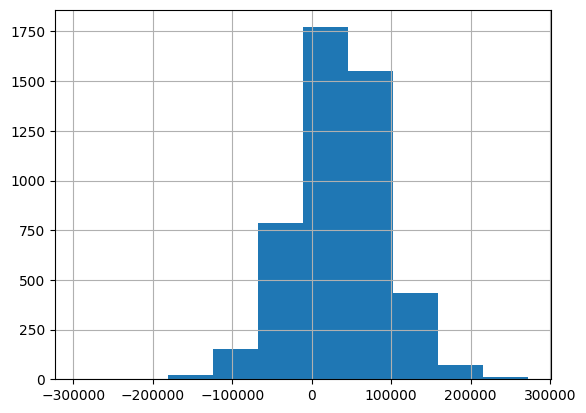

In [ ]:
#Distribution of simulation using Laplace distribution
simul_laplace["AutoARIMA"].hist()

In [ ]:
##To see the unique values after above trajectory simulation
#Forecasted values seem different from each other, so better to go for visualisation

## Trajectory simulation using User defined parameters

This is useful when:
 - There is domain knowledge about the error distribution
 - One wants to stress-test with extreme scenarios
 - One wants to ensure consistency across different datasets.

In [ ]:
# Student's t with very heavy tails (low df = more extreme values)
## Controls tail heaviness (lower = heavier tails)
simul_t_heavy = sf.simulate(
    df=TS_final,
    h=h,
    n_paths=n_paths,
    error_distribution='t',
    error_params={'df': 3},  # Heavy tails for stress testing
    seed=42
)

/usr/local/lib/python3.13/dist-packages/utilsforecast/processing.py:406: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.

/usr/local/lib/python3.13/dist-packages/utilsforecast/processing.py:462: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



In [ ]:
# Skew-normal with right skew (for positively skewed errors)
## Controls asymmetry (negative = left skew, positive = right skew)
simul_skewnorm_custom = sf.simulate(
    df=TS_final,
    h=h,
    n_paths=n_paths,
    error_distribution='skew-normal',
    error_params={'skewness': 3},  # Positive skew
    seed=42
)

/usr/local/lib/python3.13/dist-packages/utilsforecast/processing.py:406: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.

/usr/local/lib/python3.13/dist-packages/utilsforecast/processing.py:462: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



In [ ]:
## GED(Generalized error distribution) with Laplace-like behavior (shape=1)
## Controls tail behavior (1 = Laplace, 2 = Normal, higher = lighter tails)
simul_ged = sf.simulate(
    df=TS_final,
    h=h,
    n_paths=n_paths,
    error_distribution='ged',
    error_params={'shape': 1},  # Laplace-like (sharper peak)
    seed=42
)

/usr/local/lib/python3.13/dist-packages/utilsforecast/processing.py:406: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.

/usr/local/lib/python3.13/dist-packages/utilsforecast/processing.py:462: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



Comparison of the result from automatic inference and user defined parameters in terms of various factors:
1. Normal - The baseline distribution
2. t-distribution (automatic) - Parameters estimated from residuals
3. t-distribution (df=3) - User-specified heavy tails for stress testing
4. Bootstrap - Non-parametric resampling from actual residuals


In [ ]:
#Laplace simulation autodefined
fig= px.histogram(simul_laplace, x="AutoARIMA", title="Laplace distribution simulation",
                  labels={"AutoARIMA":"Laplace AutoARIMA"}, opacity=0.98)
fig.show(figsize=(3,2))

1. Normal Distribution (Baseline)


<Axes: >

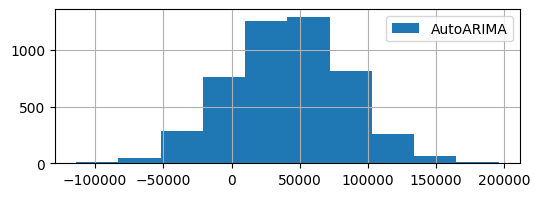

In [ ]:
#Let's check original distribution on plot
print("1. Normal Distribution (Baseline)")
sims["AutoARIMA"].hist(figsize=(6,2),legend="Normal Distribution")

1. Normal Distribution (Baseline)

2. t-Distribution with Heavy Tails (df=3, User-Specified)


<Axes: >

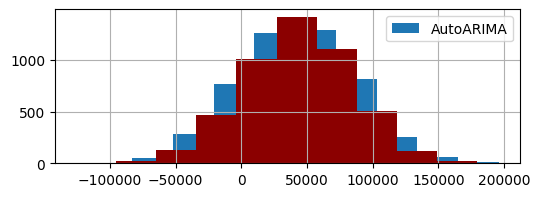

In [ ]:
#Comparing Normal distribution with respect to others
#to the real distribution for further simulation choice
print("1. Normal Distribution (Baseline)")
sims["AutoARIMA"].hist(figsize=(6,2),legend="Normal Distribution")

print("\n2. t-Distribution with Heavy Tails (df=3, User-Specified)")
simul_t_heavy["AutoARIMA"].hist(label='t-Distribution (df=3, Heavy Tails)', color='darkred')

1. Normal Distribution (Baseline)

2. Skew normal with Automatic Parameter Inference


<Axes: >

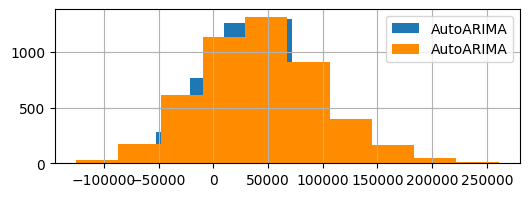

In [ ]:
#Comparing Normal distribution with respect to others
#to the real distribution for further simulation choice

print("1. Normal Distribution (Baseline)")
sims["AutoARIMA"].hist(figsize=(6,2),legend="Normal Distribution")

print("\n2. Skew normal with Automatic Parameter Inference")
simul_skew_norm["AutoARIMA"].hist(legend='skew normal(Automatic)', color='darkorange')


1. Normal Distribution (Baseline)

4. Laplace predefined


<Axes: >

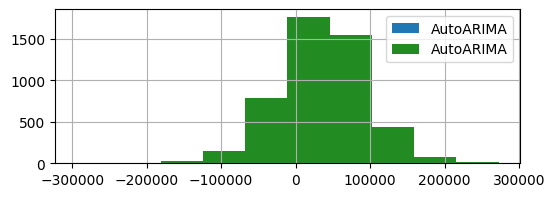

In [ ]:
#Comparing Normal distribution with respect to
#the real distribution for further simulation choice
print("1. Normal Distribution (Baseline)")
sims["AutoARIMA"].hist(figsize=(6,2),legend="Normal Distribution")

print("\n4. Laplace predefined")
simul_laplace["AutoARIMA"].hist(legend='Laplace(Autodefined)', color='forestgreen')

1. Normal Distribution (Baseline)

5. Generalized Error distribution predefined


<Axes: >

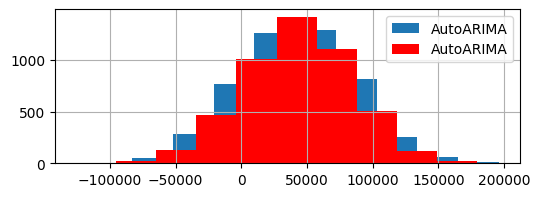

In [ ]:
#Comparing Normal distribution with respect to
#the real distribution for further simulation choice
print("1. Normal Distribution (Baseline)")
sims["AutoARIMA"].hist(figsize=(6,2),legend="Normal Distribution")

print("\n5. Generalized Error distribution predefined")
simul_ged["AutoARIMA"].hist(legend="Generalized Error Distribution", color="red")

1. Normal Distribution (Baseline)

 2. Skew-Norm custom Error distribution predefined


<Axes: >

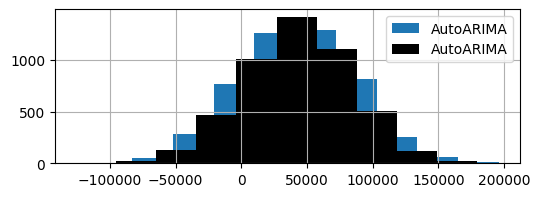

In [ ]:
#Comparing Normal distribution with respect to
#the real distribution for further simulation choice
print("1. Normal Distribution (Baseline)")
sims["AutoARIMA"].hist(figsize=(6,2),legend="Normal Distribution")

print("\n 2. Skew-Norm custom Error distribution predefined")
simul_skewnorm_custom["AutoARIMA"].hist(legend="skew-norm custom error distribution", color="black")


1. Normal Distribution (Baseline)

2. Skew normal with Automatic Parameter Inference

 3. Skew-Norm custom Error distribution predefined

4. Laplace predefined

5. Generalized error distribution custom

6. t-distribution Error through custom predefined


<Axes: >

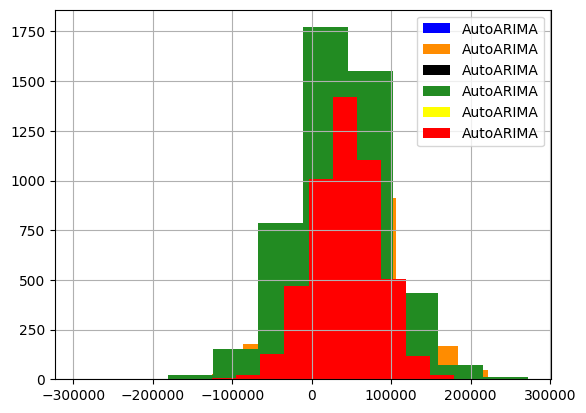

In [ ]:
# Comparing different approaches
print("\n1. Normal Distribution (Baseline)")
sims["AutoARIMA"].hist(legend="Normal distribution", color="Blue")

print("\n2. Skew normal with Automatic Parameter Inference")
simul_skew_norm["AutoARIMA"].hist(legend='skew normal(Automatic)', color='darkorange')

print("\n 3. Skew-Norm custom Error distribution predefined")
simul_skewnorm_custom["AutoARIMA"].hist(legend="skew-norm custom error distribution", color="black")

print("\n4. Laplace predefined")
simul_laplace["AutoARIMA"].hist(legend='Laplace(Autodefined)', color='forestgreen')

print("\n5. Generalized error distribution custom")
simul_ged["AutoARIMA"].hist(legend= "Generalized Error Distribution", color="yellow")

print("\n6. t-distribution Error through custom predefined")
simul_t_heavy["AutoARIMA"].hist(legend="t-distribution by user with heavy tails", color="Red")

Interpretation:

One could find that the laplace automatic inference has captured the original distribution very well, on the other hand skew-normal-auto also passed the way to grasp or capture the normal distribution data.

Moreover, the error distribution with user defined parameters are fail to generalize the original error distribution.

This could lead to identify  or to opt for other simulation for further forecasting or prediction, if distribution is going to alter.

## Signature Transformation method:
Using for Data Augmention and to find more relevant patterns in new transformation even if the dataset is small.

In [ ]:
!pip install esig

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 40.1 MB/s eta 0:00:00


In [ ]:
!pip install sktime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.6/37.6 MB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 16.7 MB/s eta 0:00:00


In [ ]:
#To ensure maximum purity of information
#using log-signature
from sklearn.ensemble import RandomForestClassifier
#import iisignature
import esig as esig
#from esig import tosig as tsg
import sktime as skt
from sktime.classification.feature_based import SignatureClassifier
from sktime.transformations.signature_based import SignatureTransformer

In [ ]:
##Converting Sequential Data of Time Series into Signature features
##Where [num_of_batch, series_length, number_of_features] -> [num_of_batch, signature_features]
# First building a very simple signature transform module
signature_transform = SignatureTransformer(
    augmentation_list=("addtime",),
    window_name="global",
    window_depth=None,
    window_length=None,
    window_step=None,
    rescaling=None,
    sig_tfm="signature",
    depth=3,
)

# The simply transform the stream data
print(f"Raw data shape is: {X_train.shape}")

Raw data shape is: (8, 2)


In [ ]:
X_train= pd.DataFrame(X_train)
for i in X_train.columns:
  print(i)

cutoff
y


In [ ]:
##Equating cutoff values as time specified variable "ds"
X_train["ds"]= X_train["cutoff"].values
X_train= X_train.set_index("ds")
X_train["ds"]= X_train["ds"].sort_values()

KeyError: 'ds'

In [ ]:
X_train.head()

In [ ]:

X_train= X_train.set_index("ds")
X_train= X_train.sort_index()
X_train["y"]= pd.DataFrame(X_train["y"])
#train_signature_x = signature_transform.fit_transform(X_train["y"])

In [ ]:
##Converting Sequential Data of Time Series into Signature features
##Where [num_of_batch, series_length, number_of_features] -> [num_of_batch, signature_features]
# First building a very simple signature transform module
signature_transform = SignatureTransformer(
    augmentation_list=("addtime",),
    window_name="global",
    window_depth=None,
    window_length=None,
    window_step=None,
    rescaling=None,

train_signature_x = signature_transform.fit_transform(X_train["y"])
print(f"Signature shape is: {train_signature_x.shape}")

In [ ]:
#Converting above transformed series into classification problem
import RandomForestClassifier
rf= RandomForestClassifier()
rf_pred= rf.fit(train_signature_x, y_train)
rf_pred

# Evaluation after above classification defined
test_signature_x = signature_transform.transform(x_test)
test_pred = model.predict(test_signature_x)
print(f"Accuracy: {accuracy_score(y_test, test_pred):.3f}%")


In [ ]:
###Hyperparameter search for best parameters
from sklearn.metrics import accuracy, precision_recall_curve
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
##StratifiesKFold CV is used here to consider all the series with specific time series for cross validation
##Timeseriessplit cross validation for time series defines the above statement more accurately.

# Some params
n_cv_splits = 5
n_gs_iter = 20

# Random forests found to perform very well in general
estimator = RandomForestClassifier()

# The grid to be passed to an sklearn gridsearch
signature_grid = {
    # Signature params
    "depth": [1, 2, 3, 4, 5],
    "window_name": ["dyadic"],
    "augmentation_list": [["basepoint", "addtime"]],
    "window_depth": [1, 2, 3, 4],
    "rescaling": ["post"],
    # Classifier and classifier params
    "estimator": [estimator],
    "estimator__n_estimators": [50, 100, 500],
    "estimator__max_depth": [2, 4, 6, 8, 12, 16, 24, 32, 45, 60],
}

In [ ]:
# Initialising the estimator
estimator = SignatureClassifier()

# Running a random grid search
cv = StratifiedKFold(n_splits=n_cv_splits)
rsc = RandomizedSearchCV(estimator, signature_grid, cv=n_cv_splits, n_iter=n_gs_iter)
rsc.fit(x_train,y_train)

# Get the best classifier
best_classifier = rsc.best_estimator_

In [ ]:
# Evaluation
train_preds = best_classifier.predict(x_train)
test_preds = best_classifier.predict(x_test)
train_score = accuracy_score(y_train, train_preds)
test_score = accuracy_score(y_test, test_preds)
print(f"Train acc: {train_score * 100:.3f}%  |  Test acc: {test_score * 100:.3f}%")

##Model 2. ARIMA and its family

In [ ]:
# Fit the ARIMA model
model = ARIMA(ts_['SHIPMENT_linear'], order=(1, 1, 1))
model_fit = model.fit()

# Forecasting next steps
forecast = model_fit.forecast(steps=80)

In [ ]:
# Plotting the results
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
# Plot observed data
plt.plot(ts_['SHIPMENT_linear'].index, ts_['SHIPMENT_linear'], label='Observed')
# Plot forecasted data
plt.plot(forecast.index, forecast, label='Forecast', color='red')
plt.title('ARIMA Forecast')
plt.xlabel('Index') # Assuming index is numerical, not date
plt.ylabel('SHIPMENT')
plt.legend()
plt.show()

##SARIMAX

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
sarimax= SARIMAX(endog=TS["y"],order=(1,0,0), seasonal_order=(0,0,0,12), simple_differencing= True, hamilton_representation= True)

In [ ]:
sarimax_model= sarimax.fit()
forecast_sarimax= sarimax_model.forecast(steps=30)
forecast_sarimax.head()

In [ ]:
#Confidence intervals of above forecasted model
sarimax_model.get_forecast(steps=len(TS)).conf_int(alpha=0.94).head()

In [ ]:
 TS["y"].plot(label="Observed")
 forecast_sarimax.plot(label="Forecast", color="red")
 plt.legend()
 plt.show()

## SARIMAX USING SKFORECAST

In [ ]:
pip install skforecast==0.13.0

In [ ]:
pip install pmdarima

In [ ]:
from skforecast.Sarimax import Sarimax
from skforecast.ForecasterSarimax import ForecasterSarimax
from skforecast.model_selection_sarimax import backtesting_sarimax, grid_search_sarimax

In [ ]:
#X_train=X_train[~X_train.index.duplicated()]
#X_train
X_train.columns

In [ ]:
#Setting index=cutoff and removing duplicate values
X_train= X_train.set_index("cutoff",drop= True)

In [ ]:
#Resetting index and removing duplicates by setting drop= True
X_train.index = pd.to_datetime(X_train.index,errors="coerce")
#X_train = X_train.set_index("cutoff",drop=True)

#### Defining forecasterSarimax from Skforecast with variables to implement SARIMAX model

In [ ]:
forecast = ForecasterSarimax(transformer_exog= X_train.index,regressor=Sarimax(order=(2, 1, 1), seasonal_order=(2, 1, 1, 12)))
"""X_train_series= X_train['y']
#X_train_series= pd.Series(X_train)
forecast.fit(X_train_series, suppress_warnings=True)

# Prediction
predict = forecast.predict(steps=np.meshgrid(X_test))"""

In [ ]:
#Fitting the data with mentioned model above
X_train["y"]= X_train["y"].fillna(0) #Imputation with 0
forecast.fit(y=X_train["y"])

In [ ]:
#Removing the duplicate values from index and converting into a datetime format.
X_train = X_train[~X_train.index.duplicated(keep='first')]
X_train.index = pd.to_datetime(X_train.index,errors="coerce")

X_train= X_train.asfreq("30min") #here, set freq to 30 min, as cutoff has gap of 30 min
X_train["y"]= X_train["y"].fillna(0) #Imputation with 0

#Fit and prediction process using above model
forecast.fit(y=X_train["y"])
forecast.predict(steps= 12)

#### Evaluating SARIMAX result using Backtesting, where Backtesting is use for evaluating the performance of the SARIMAX model

In [ ]:
#Forecaster sarimax with number of iterations defined
forecast= ForecasterSarimax(transformer_exog= X_train.index,regressor= Sarimax(order=(2,1,2), seasonal_order=(1,1,2,12), maxiter= 300, enforce_stationarity= False))

In [ ]:
#To identify missing values present in the Y_train dataset.
Y_train.info()

In [ ]:
#Imputation of missing value with 0
Y_train= Y_train.fillna(0)

In [ ]:
cv_df.columns

In [ ]:
cv_Df= cv_df[["y","SeasonalNaive"]]
#To flatten the above dataframe to make it possible
#to colnclude under y variable in grid search sarimax method
#cv_Df= pd.Series(cv_Df).flatten()

In [ ]:
#Metrics and backtesting description
TS_Series= pd.Series(TS["y"])
cv_df_Series= pd.Series(cv_df["y"])
#cv_df_Series= cv_df_Series.fillna(0)
X_test_Series= pd.Series(X_test["y"])
metric, predictions_backtest = backtesting_sarimax(
                               forecaster=forecast,
                               y=cv_df_Series,
                               initial_train_size=5,
                               fixed_train_size=False,
                               steps=12,
                               metric='mean_absolute_error',
                               refit=True,
                               n_jobs="auto",
                               suppress_warnings_fit=True,
                               verbose=True,
                               show_progress=True
                           )

print(f"Metric (mean absolute error): {metric}")

Here we got high MAE than previous ones that shows model is less likely to fit with the test data volatility, while considering steps= 12.

In [ ]:
# Backtesting Predictions on SARIMAX from skforecast
fig, ax = plt.subplots(figsize=(6, 3))
Y_test.plot(ax=ax, label='Test Data')
predictions_backtest.plot(ax=ax)
ax.set_title('Backtesting Predictions with a SARIMAX Model')
ax.legend()

As one can see from above, SARIMAX model is fail to capture seasonality as well as other factors.
Let's find the best hyperparameters for SARIMAX Model to best capture with the test data. For this:
1. One can go through with train-valid-test data to get more narrower view of data and further can know the optimal hyperparameters or patterns.
2. Here, I am using Grid Search for finding the most suitable hyperparameters from above model, as dataset is relatively small to implement above method.

In [ ]:
# Initialising Forecast for Grid Search
forecast = ForecasterSarimax(regressor=Sarimax(order=(1, 1, 1), maxiter=300, enforce_stationarity= False))

In [ ]:
X_train.info()

In [ ]:
# Describing different values or parameters for Grid search
parameter_grid = {
    'order': [(0, 1, 0), (0, 1, 1), (1, 1, 0), (1, 1, 1), (2, 1, 1)],
    'seasonal_order': [(0, 0, 0, 0), (0, 1, 0, 12), (1, 1, 1, 12)],
    'trend': [None, 'n', 'c'],
    #"enforce_stationarity":False,
    #"initialization":"approximate_diffuse"
}


In [ ]:
cv_df.head(3)

In [ ]:
#cv_df_Series=cv_df_Series.astype("int")
cv_df_Series.dtypes
cv_df_Series= cv_df_Series.reset_index(drop= True)
cv_df_Series.index= pd.to_numeric(cv_df_Series.index, errors="coerce")
print(cv_df_Series.size)
#cv_df_Series.isna().any()

In [ ]:
cv_df_Series.head()
cv_df_Series= pd.DataFrame(cv_df_Series)
cv_df_Series.info()

##GRID SEARCH IMPLEMENTATION

In [ ]:
for x in TS.columns:
  print(x)
TS["unique_id"]="Series1"
ts.shape
ts["unique_id"]="Series1"
for b in ts.columns:
  print(b)

In [ ]:
#1. Imputation using linear method of finding suitable parameters
'''cv_df_= TS.copy()
cv_df_= pd.DataFrame({"unique_id":ts["unique_id"], "ds": ts["CUT OFF TIME"], "y": ts["SHIPMENT"]})
#cv_df_= cv_df_.to_numpy().reshape(-1,1)
cv_df_= pd.DataFrame(cv_df_)
cv_df_linear= cv_df_.interpolate(method='linear', limit_direction='forward')
cv_df_linear[cv_df_linear.index.duplicated()]
cv_Df_linear= cv_df_linear.reset_index(drop=True)
cv_df_linear= cv_df_linear.asfreq("1min")
cv_df_linear.info()
ts["CUT OFF TIME"].head()'''

In [ ]:
cv_df_raw = pd.DataFrame({
    "unique_id": ts["unique_id"],
    "date_part": ts["GATE IN DATE"],
    "time_part": ts["CUT OFF TIME_"] ,
    "y": ts["SHIPMENT"]
})
# Combine date and time parts into a single datetime column 'ds'
cv_df_raw["ds"] = pd.to_datetime(cv_df_raw["date_part"] + ' ' + cv_df_raw["time_part"], format='%d-%b-%Y %H:%M', errors="coerce")

# Drop rows where 'ds' could not be parsed (NaT) or 'y' is NaN initially
cv_df_raw = cv_df_raw.dropna(subset=['ds', 'y', 'unique_id'])

# Sort by unique_id and ds, then set ds as index
cv_df_raw = cv_df_raw.sort_values(by=['unique_id', 'ds'])

# If unique_id is constant, we can proceed with a single series.
# If there are multiple unique_ids, apply imputation and asfreq per group.
# For simplicity, assuming a single unique_id for now as implied by many subsequent steps.

# Create the final Series for linear interpolation
# We want 'y' to be the target for interpolation and 'ds' to be the index.
# First, ensure 'ds' is unique to avoid issues with asfreq. If there are duplicates, group and aggregate.
if cv_df_raw[['unique_id', 'ds']].duplicated().any():
    print("Warning: Duplicate 'ds' values found for 'unique_id'. Aggregating 'y' by 'ds' (sum).")
    cv_df_raw = cv_df_raw.groupby(['unique_id', 'ds'], as_index=False)['y'].sum()

# Set 'ds' as index for time series operations
cv_df_raw = cv_df_raw.set_index('ds')

# Resample to a 30-minute frequency. This might introduce NaNs for missing time steps.
# 'asfreq' fills missing datetime indices with NaNs for the value columns.
cv_df_linear_ = cv_df_raw.groupby('unique_id')['y'].resample('30min').mean()
cv_df_linear_ = cv_df_linear_.reset_index(level='unique_id', drop=True) # If we only need 'y' series

# Linearly interpolate missing values
cv_df_linear = cv_df_linear_.interpolate(method='linear', limit_direction='both')

print("Info of cv_df_linear after processing:")
cv_df_linear.info()
print("\nHead of cv_df_linear:")
cv_df_linear.head()

In [ ]:
#cv_df_mean= pd.Series(cv_df_mean)
##Grid search on SARIMAX with above parameters defined
final_grid_result = grid_search_sarimax(
    forecaster=forecast,
    param_grid=parameter_grid,
    steps=24,
    metric='mean_absolute_error',
    y=cv_df_linear,
    initial_train_size=18,
    fixed_train_size=False,
    return_best=True,
    n_jobs='auto',
    suppress_warnings_fit=True,
    verbose=False,
    show_progress=True
)

`Forecaster` using SARIMAX Model refitted using the best-found parameters with the whole data set, where the best:
  1. order: (2, 1, 1)
  2. seasonal_order: (0, 0, 0, 0)
  3. trend: None
  4. Backtesting metric(mean absolute error): 5557.123034986284


In [ ]:
#Let's check the last rows of the above grid search model
final_grid_result.tail()

In [ ]:
#Row with lowest mae for considering best parameters
#With above imputation technique
"""for i in final_grid_result["mae"]:
    best_parameters= final_grid_result["mae"].min
    best_parameters"""

##2. Imputation with Mean value

In [ ]:
#2. Imputation with mean value
from sklearn.impute import SimpleImputer
imputer= SimpleImputer(strategy="mean")
cv_fill_mean = cv_df_linear_.fillna(cv_df_linear_.mean(numeric_only=True))
#cv_df_mean= imputer.fit_transform(cv_df_Series)
#cv_df_mean= pd.DataFrame(cv_df_mean)
#cv_df_mean= pd.Series(cv_df_mean)
#cv_df_mean= cv_df_mean.fillna(0)
cv_fill_mean= cv_fill_mean.asfreq("30min")
cv_fill_mean.isna().sum()

In [ ]:
print(type(cv_fill_mean))
print(len(cv_fill_mean))

In [ ]:
#2. Executing Grid Search with values using mean

final_grid_result = grid_search_sarimax(
                    forecaster=forecast,
                    param_grid=parameter_grid,
                    steps=24,
                    metric='mean_absolute_error',
                    y=cv_fill_mean,
                    initial_train_size=18,
                    fixed_train_size=False,
                    return_best=True,
                    n_jobs='auto',
                    suppress_warnings_fit=True,
                    verbose=False,
                    show_progress=True
               )

final_grid_result.head(5)

`Forecaster` using SARIMAX refitted using the best-found parameters, and the whole data set with the best parameters:
1. order: (0, 1, 0)
2. seasonal_order: (0, 0, 0, 0)
3. trend: None
4. Backtesting metric(Mean_Absolute_Error): 2336.625

##3. Imputation with polynomial of order=2

In [ ]:
##3. imputation according to
#suitable degree from polynomial regression
cv_df_poly= cv_df_linear_.interpolate(method="polynomial", order= 2)
cv_df_poly = cv_df_poly.asfreq("30min")
cv_df_poly.info()

In [ ]:
#3. Imputation with values from non-linear models-1
cv_df_poly = cv_df_poly.asfreq("30min")

final_grid_result = grid_search_sarimax(
                    forecaster=forecast,
                    param_grid=parameter_grid,
                    steps=24,
                    metric='mean_absolute_error',
                    y=cv_df_poly,
                    initial_train_size=18,
                    fixed_train_size=False,
                    return_best=True,
                    n_jobs='auto',
                    suppress_warnings_fit=True,
                    verbose=False,
                    show_progress=True
               )

final_grid_result.head(5)

'Forecaster` using SARIMAX refitted using the best-found parameters, and the whole data set with best Parameters:
  1. order: (0, 1, 0)
  2. seasonal_order: (0, 0, 0, 0)
  3. trend: None
  4. Backtesting metric(mean absolute error): 198355.2749324948

One can also use elbow method to consider the best order of polynomial to get minimum metric (here mean absolute error) on above SARIMAX model with grid search

## 4. Imputation of missing value with 0

In [ ]:
#5. Imputation using 0
cv_df_zero = cv_df_linear_.replace(np.nan, 0).fillna(0)# Replacing nan with 0
cv_df_zero = cv_df_zero.asfreq("30min")
cv_df_zero

In [ ]:
# Executing Grid Search with imputation using 0
#cv_df_mean= pd.Series(cv_df_mean.flatten())
#cv_df_Series= np.meshgrid(cv_df_Series)

cv_df_1= cv_df_linear.reset_index(drop= True) ##Resetting index to consider the imputation with 0
cv_df_zero= cv_df_1.replace(np.nan,0)
final_grid_result = grid_search_sarimax(
                    forecaster=forecast,
                    param_grid=parameter_grid,
                    steps=24,
                    metric='mean_absolute_error',
                    y=cv_df_zero,
                    initial_train_size=18, # Increased initial_train_size for better model fitting
                    fixed_train_size=False,
                    return_best=True,
)

`Forecaster` refitted from SARIMAX model using the best-found parameters, and the whole data set with best parameters:
1. order: (2, 1, 1)
2. seasonal_order: (0, 0, 0, 0)
3. trend: None
4.  Backtesting metric(mean absolute error): 5557.123034986284

##5 Non-Imputation when dropping missing values

In [ ]:
cv_df_linear_.info()

With total 58 entries, here I got 40 rows with null values in series "y"

After dropping missing values, remaining 18 non-null values.

In [ ]:
##Dropping the rows where all the elements in series are missing.
cv_df_temp_= cv_df_linear_.reset_index()
cv_df_temp = cv_df_temp_.dropna(subset=["ds","y"])
#cv_df_temp= pd.Series(cv_df_temp)
# After dropna, the frequency might be lost. Re-establish the desired frequency
#cv_df_temp = cv_df_temp.asfreq('30min')
cv_df_temp= cv_df_temp.iloc[:]
cv_df_temp["ds"]= pd.to_datetime(cv_df_temp["ds"])
cv_df_temp= cv_df_temp.set_index("ds")
cv_df_temp
#cv_df_temp=pd.Series(cv_df_temp)

#cv_df_temp= cv_df_temp.ix[:,1]


From above,
The missing values present after 14:00pm and before 09:00 am, shows that one was unable to get the value or observe the value after and before the above time, shows seasonality(if values also present in other dates) , else comes under cyclicity.

In [ ]:
#cv_df_temp_= cv_df_temp_.values.reshape(-1,1)

In [ ]:
#Converting "y" dataframe into series
#cv_df_temp["y"]= pd.Series(cv_df_temp["y"])
#Converting into datetime format
"""cv_df_temp.index = pd.to_datetime(cv_df_temp.index, format='%d-%b-%Y %H:%M', errors="coerce")

#setting frequency of 30minutes
#cv_df_temp.index = pd.date_range(start=cv_df_temp.index[0], end=cv_df_temp.index[-1], freq='D')
cv_df_temp= cv_df_temp.asfreq("30min")
cv_df_temp.tail(10)"""

In [ ]:
cv_df_temp_= cv_df_temp.asfreq("30min")
cv_df_temp_= cv_df_temp_.fillna(0)
cv_df_temp_.head(10)

In [ ]:
#Replacing NaN values and converting "ds" or index into datetime feature
cv_df_temp = cv_df_temp[~np.isnan(cv_df_temp)]
cv_df_temp.index= pd.to_datetime(cv_df_temp.index, errors="coerce")
cv_df_temp["y"]= pd.Series(cv_df_temp["y"]) # Series from DataFrame

In [ ]:
##Imputation while dropping missing values of y and respective rows
import warnings
warnings.filterwarnings("ignore")
#cv_df_temp= np.array(cv_df_temp)
#cv_df_temp = pd.DataFrame(cv_df_temp.flatten())
#cv_df_temp= cv_df_temp.reshape(18,1)
#cv_df_temp= pd.Series(cv_df_temp)
#cv_df_temp= cv_df_temp.reshape(18,1)
cv_df_temp.index= pd.to_datetime(cv_df_temp.index, errors="coerce")
cv_df_temp= cv_df_temp.asfreq("30min")
cv_df_temp= cv_df_temp.reset_index(drop=True)
cv_df_temp= cv_df_temp.dropna()
cv_df_temp= cv_df_temp.asfreq("30min")

final_grid_result = grid_search_sarimax(
                    forecaster=forecast,
                    param_grid=parameter_grid,
                    steps=5,
                    metric='mean_absolute_error',
                    y=cv_df_temp["y"],
                    initial_train_size=4,
                    fixed_train_size=False,
                    return_best=True,
                    n_jobs='auto',
                    suppress_warnings_fit=False,
                    verbose=False,
                    show_progress=True,
                    refit= True
)

final_grid_result.head(5)

In [ ]:
#Executing Grid Search with imputation using polynomial regression
#cv_df_poly= pd.Series(cv_df_poly)
#cv_df_Series= np.meshgrid(cv_df_Series)
final_grid_result = grid_search_sarimax(
                    forecaster=forecast,
                    param_grid=parameter_grid,
                    steps=10,
                    metric='mean_absolute_error',
                    y=cv_df_poly,
                    initial_train_size=8,
                    fixed_train_size=False,
                    return_best=True,
)

##6. Imputation using Nearest Interpolation

In [ ]:
df_near= cv_df_linear.interpolate(method="nearest")
df_near.index.min()
df_near= df_near.asfreq("30min")
df_near.head()

In [ ]:
# Executing Grid Search
final_grid_result = grid_search_sarimax(
                    forecaster=forecast,
                    param_grid=parameter_grid,
                    steps=24,
                    metric='mean_absolute_error',
                    y=df_near,
                    initial_train_size=18,
                    fixed_train_size=False,
                    return_best=True,
                    n_jobs='auto',
                    suppress_warnings_fit=True,
                    verbose=False,
                    show_progress=True
               )

final_grid_result.head(5)

`Forecaster` using Nearest Imputation refitted using the best-found parameters, and the whole data set, and the best Parameters are :
  1. 'order': (2, 1, 1),
  2. 'seasonal_order': (0, 0, 0, 0),
  3. 'trend': None

  Backtesting metric(mean_absolute_error here): 5557.123034986284

##7. Imputation using Multiple Imputation

Multiple imputation is a robust statistical strategy that addresses uncertainty by generating multiple imputed datasets. Each is analyzed separately, and the final results are pooled to reflect the variability stemming from the imputation process.


In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
cv_df_linear.head()

In [ ]:
cv_Df_linear=pd.DataFrame(cv_df_linear.reset_index())
cv_Df_linear.head()
cv_Df_linear["ds_time"]= cv_Df_linear["ds"].dt.time
cv_Df_linear[["ds","ds_time"]]= cv_Df_linear[["ds","ds_time"]].astype("str")
cv_Df_linear.head()
cv_Df_linear= cv_Df_linear.drop("ds", axis= 1)
cv_Df_linear= cv_Df_linear.set_index("ds_time")
cv_Df_linear.head()

In [ ]:
multiple = IterativeImputer(random_state=42, sample_posterior=True, max_iter=10)
#cv_Df_linear= pd.DataFrame(cv_df_linear)
cv_df_multiple = multiple.fit_transform(cv_Df_linear)
#df_imputed= df_imputed.asfreq("30min")
#cv_df_multiple= cv_df_multiple.reshape(58,1)
df_imputed = pd.DataFrame({"values": cv_df_multiple.ravel()})
#df_imputed= df_imputed.asfreq("30min")
df_imputed= df_imputed.values.reshape(58,1)
df_imputed= pd.DataFrame(df_imputed)
df_imputed["y"]= df_imputed[0]
df_imputed= df_imputed.drop(columns=[0])
df_imputed.info()

The use of `sample_posterior=True` in the Iterative Imputer allows for incorporating randomness in the imputation process, which is a key step in creating multiple imputations. Running this multiple times and pooling the results can significantly boost the robustness of downstream analyses.

In [ ]:
# Executing Grid Search
final_grid_result = grid_search_sarimax(
                    forecaster=forecast,
                    param_grid=parameter_grid,
                    steps=24,
                    metric='mean_absolute_error',
                    y=df_imputed["y"],
                    initial_train_size=18,
                    fixed_train_size=False,
                    return_best=True,
                    n_jobs='auto',
                    suppress_warnings_fit=True,
                    verbose=False,
                    show_progress=True
               )

final_grid_result.head(5)

`Forecaster` using SARIMAX using multiple imputation refitted using the best-found parameters, and the whole data set, while best paramters:
1. order: (2, 1, 1)
2. seasonal_order: (0, 0, 0, 0)
3. trend: None

  Backtesting metric(using Mean Absolute Error here): 5557.123034986284

##. Imputation using non-linear models

In [ ]:
import scipy.stats as stats

In [ ]:
#4. Imputation with values from non-linear models
cv_df_Series= cv_df_Series.asfreq("30min")

final_grid_result = grid_search_sarimax(
                    forecaster=forecast,
                    param_grid=parameter_grid,
                    steps=10,
                    metric='mean_absolute_error',
                    y=cv_df_Series["y"],
                    initial_train_size=5,
                    fixed_train_size=False,
                    return_best=True,
                    n_jobs='auto',
                    suppress_warnings_fit=True,
                    verbose=False,
                    show_progress=True
               )

final_grid_result.head(5)

##Autoencoder for data generation

In [ ]:
cv_df2.head()

In [ ]:
#Taking only predicted relevant columns for generation and prediction
enc= cv_df[["ds", "y"]]
enc= enc.set_index("ds")
enc= enc.dropna()    ##Missing values drop
enc

In [ ]:
#Data for autoencoder for prediction and generation of new data
cv_df.head()
enc= enc.reset_index()
#enc= pd.to_datetime(enc["ds"], errors="coerce")
enc= pd.DataFrame(enc)
enc

##1. Rescaling on dataset including prediction from various time related models.

In [ ]:
#Minmax scaling to make range varies between 0 and 1
from sklearn.preprocessing import MinMaxScaler
minsc= MinMaxScaler()
cv_df_min= minsc.fit_transform(cv_df2)
cv_df_min= pd.DataFrame(cv_df_min)
cv_df_min.head()

In [ ]:
X3= cv_df2.drop(columns=["SeasonalNaive"])
Y3= cv_df2["SeasonalNaive"]
from sklearn.model_selection import train_test_split
X3_train, X3_test, Y3_train, Y3_test= train_test_split(X3,Y3, test_size= 0.3, random_state= 42)
X3.columns

In [ ]:

print(X3_train, X3_test)
print(X3_train.info())

In [ ]:
X3_train = X3_train.values

In [ ]:
print(Y3_train, Y3_test)
print(Y3_train.info())

In [ ]:
#Columns in new dataframe
enc.columns

In [ ]:
# Initial and target for autoencoder prediction and generation of new data
X3_= enc.drop(columns=['y'], axis=1)
Y3_= enc["y"]
X3_

In [ ]:
# Splitting X_ and Y3_ to training and testing for prediction
#enc= enc.reset_index()
X3_train_, X3_test_, Y3_train_, Y3_test_= train_test_split(X3_,Y3_, test_size= 0.3, random_state= 42)
X3_train_= X3_train_.astype("str")
Y3_train_= Y3_train_.astype("str")
X3_train_.info(), Y3_train_.info()

In [ ]:
#Convert to custom integer format
X3_["ds"]= pd.to_datetime(X3_["ds"])
X3_['ds'] = X3_['ds'].dt.strftime('%H:%M:%S')
X3_["ds"]= pd.DataFrame(X3_["ds"])

In [ ]:
X3_["ds"]= X3_["ds"].astype("str")
X3_["ds"]= X3_["ds"].str.split(":")

X3_["ds"]=''.join(''.join(map(str, l)) for l in X3_["ds"]) #Converting list into string
#X3_["ds"]= X3=_["ds"].str.split(",")
X3_["ds"]= np.array(X3_["ds"], dtype="float") #Converting into array and datatype into float

In [ ]:
def list_to_numeric(x):
  a=[]
  for i in x:
      i= int(i or 0)
      a.append(i)
  return a
  list_to_numeric(X3_["ds"])
X3_train= pd.DataFrame(X3_train)
X3_train.info()


In [ ]:
# Defining autoencoder model for prediction
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# input dimension
input_dim = 7

# encoder
input_layer = Input(shape=(input_dim,))

encoded = Dense(4, activation='relu')(input_layer)
latent = Dense(10, activation='relu')(encoded)

# decoder
decoded = Dense(4, activation='relu')(latent)
output_layer = Dense(input_dim, activation='linear')(decoded)

# autoencoder
autoencoder = Model(input_layer, output_layer)

# compile
autoencoder.compile(optimizer='adam', loss='mse')

# summary
autoencoder.summary()

In [ ]:
# 2. Compiling  on training data(X_train) and proceeding to training
autoencoder.compile(optimizer='adam', loss='mean_squared_error', metrics=["accuracy"])
autoencoder.fit(
    X3_train, X3_train,
    epochs=34,
    batch_size=64,
)

In [ ]:
X3_train_.columns

In [ ]:
X3

In [ ]:
scaling= StandardScaler()
X3_train_= pd.DataFrame(X3_train_)
X3_train_scaling= scaling.fit_transform(X3_train_)
X3_train_scaling= pd.DataFrame(X3_train_scaling)
X3_train_scaling= X3_train_scaling.dropna()
X3_train_scaling
#X3_train_scaling.fillna(X3_train_scaling[''].mean(), method='mean')


Using standardzing the values present in the X3_train, there is no presence of values except np.nan.

In [ ]:
# The original error indicates an input shape mismatch.
# The autoencoder was defined with an input dimension of 7 features.
# However, the current code is attempting to train it with 'X3_train_["ds"]',
# which is effectively a 1-dimensional series/array (only the 'ds' column),
# leading to the `expected axis -1 of input shape to have value 7, but received input with shape (None, 1)` error.

# This cell's intent seems to be training the autoencoder on the features
# represented by the 'X3_train' DataFrame that has 7 columns (y, HoltWinters,
# CrostonClassic, HistoricAverage, DynamicOptimizedTheta, hour, min).
# We need to ensure we use that specific 'X3_train' and handle its NaN values.

# Based on cell '9RoqOOFoikkb', X3_train is a DataFrame with 8 entries and 7 columns, containing NaNs.
# Impute NaN values in X3_train before feeding it to the autoencoder.
# Using mean imputation for numerical columns.
if X3_train.isnull().any().any():
    X3_train_imputed = X3_train.fillna(X3_train.mean())
else:
    X3_train_imputed = X3_train.copy()

# Convert to numpy array for Keras, ensuring it's float type
X3_train_for_ae = X3_train_imputed.values.astype('float32')

# Now, compile and fit the autoencoder with the correctly shaped and prepared data
autoencoder.compile(optimizer='adam', loss='mean_squared_error', metrics=["accuracy"])
autoencoder.fit(
    X3_train_for_ae, X3_train_for_ae, # Autoencoders train to reconstruct their input
    epochs=34,
    batch_size=8, # Adjusted batch size to match the number of samples for small dataset
    verbose=0 # Suppress verbose output during training
)

print("Autoencoder training completed successfully with corrected input shape.")

In [ ]:
#Prediction using autoencoder
pred= autoencoder.predict(X3_test)
pred

In [ ]:
#Evaluation using "mean_absolute_error"
from sklearn.metrics import mean_absolute_error
eval_auto= mean_absolute_error(X3_test, pred)
eval_auto

The "mean_absolute error" using Autoencoder is 34513.183 that's less than using polynomial regression.

In [ ]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
import numpy as np # Import numpy for random_latent_vec

# The latent dimension (from the autoencoder's latent layer which is 2).
# The `latent` variable in the kernel state is already 2, so we use it directly.
latent_dim = latent

# The latent dimension is 10, as established by the autoencoder's latent layer
latent_dim = 20

# Define the decoder model
# It takes the latent vector as input
decoder_input = Input(shape=(latent_dim,), name='decoder_input')

# Re-use the existing decoder layer structure from the autoencoder definition
# The original autoencoder's decoder had a Dense(4, activation='relu') followed by Dense(input_dim, activation='linear')
# We need to access the layers from the existing autoencoder model or redefine them with matching weights.
# For simplicity, we redefine layers with matching structure, assuming weights will be loaded if needed later.
# For now, we are just defining the architecture for the decoder.
decoder_layer1 = Dense(4, activation='relu', name='decoder_dense_1_reuse') # Renamed to avoid conflicts if autoencoder layers are still active
decoder_output_layer = Dense(input_dim, activation='linear', name='decoder_output_reuse') # Renamed

# Connect the layers to build the decoder model
x = decoder_layer1(decoder_input)
decoder_output = decoder_output_layer(x)
decoder_model = Model(decoder_input, decoder_output, name='decoder_model')

# Note: Data generation using decoder_model is now handled in cell fLXtHFiSNV


In [ ]:
import numpy as np
#New data generation from latent space using the decoder model
latent_dim = 20# The dimension of the latent space

# Generate random latent vectors
random_latent_vec = np.random.normal(size=(20, latent_dim))

# Use the decoder_model to transform latent vectors back into data space
# autoencoder = Model(decoded, decoded)
generated_time_Df = decoder_model.predict(random_latent_vec)

In [ ]:
#Newly generated dataset using autoencoder with size=10
generated_time_Df= pd.DataFrame(generated_time_Df)
generated_time_Df

In [ ]:
generated_time_Df.info()

In [ ]:
X3["hour"]= X3["hour"].astype("float64")
X3["min"]= X3["min"].astype("float64")

In [ ]:

#Defining column names similar to above input columns
X3= minsc.fit_transform(X3)
X3= pd.DataFrame(X3)
generated_time_Df= pd.DataFrame(generated_time_Df)
generated_time_Df.columns = X3.columns
total_columns= pd.merge(generated_time_Df, X3, how="outer") #Concatenation of above generated dataframe and X3 dataframe
total_columns


In [ ]:
total_columns= pd.concat([generated_time_Df, X3], join='inner')
total_columns

In [ ]:
total_columns.columns=["y", "HoltWinters", "CrostonClassic", "HistoricAverage", "DynamicOptimizedTheta", "hour", "min"]
total_columns= pd.DataFrame(total_columns)
total_columns= total_columns.dropna()
total_columns.head()

In [ ]:
#Adding new column "Date" to compute the crossvalidation measure between y and Date
total_columns["Date"]= total_columns["hour"] + total_columns["min"]
total_columns.columns=["y", "HoltWinters", "CrostonClassic", "HistoricAverage", "DynamicOptimizedTheta", "hour", "min","Date"]
#total_columns.index= total_columns.index(pd.range(0, len(total_columns)))
total_columns.index = range(0, 0 + len(total_columns))
total_columns["Date"][31]= 1.000001
total_columns["Date"][20]=0.00001
total_columns

In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=total_columns)

In [ ]:
# Finding duplicate values in "Date" column
dup= total_columns[total_columns["Date"].duplicated()]
dup.head()

From above,
The "Date" column doesn't contain any duplicate values.

In [ ]:
#Dropping all rows containing nan or missing values from dataframe
total_columns= total_columns[total_columns!=np.nan]
total_columns.info()

In [ ]:
#Dropping missing values and converting the index into "Datetime" format
total_columns= total_columns.dropna()
total_columns_= total_columns[total_columns!=0]
#total_columns_= total_columns.set_index("Date")
total_columns_["Date"]= pd.to_datetime(total_columns_["Date"], errors="coerce")
#total_columns_= total_columns.set_index("Date")
#total_columns_= total_columns.reset_index()

#Adding date and time to not to delete the duplicates create by above method
total_columns_["Date"]= total_columns_["Date"].asfreq("30min")
total_columns_

In [ ]:
cv_df.info()

In [ ]:
#Keeping Duplicate values with difference in terms of second and microsecond for further metrics
total_columns_["Date"]= total_columns_["Date"].dt.second
total_columns_["Date"]= total_columns_["Date"].dt.microsecond
total_columns_["Date"]= total_columns["Date"].asfreq("30min")

In [ ]:
total_columns_= total_columns_.dropna(subset=["y"])
total_columns_

In [ ]:
##Imputation while dropping missing values of y and respective rows
total_columns_["y"]= total_columns_["y"].dropna()
import warnings
warnings.filterwarnings("ignore")
#cv_df_temp= np.array(cv_df_temp)
#cv_df_temp = pd.DataFrame(cv_df_temp.flatten())
#cv_df_temp= cv_df_temp.reshape(18,1)
#cv_df_temp= pd.Series(cv_df_temp)
#cv_df_temp= cv_df_temp.reshape(18,1)

#total_columns.index= pd.to_datetime(total_columns.index, errors="coerce")
#total_columns= total_columns.asfreq("30min")
#total_columns= total_columns.set_index()

final_grid_result = grid_search_sarimax(
                    forecaster=forecast,
                    param_grid=parameter_grid,
                    steps=5,
                    metric='mean_absolute_error',
                    y=total_columns_["y"],
                    initial_train_size=4,
                    fixed_train_size=False,
                    return_best=True,
                    n_jobs='auto',
                    suppress_warnings_fit=False,
                    verbose=False,
                    show_progress=True,
                    refit= True
)

final_grid_result.head(5)

##Variational AutoEncoder for Time Series Analysis

Variational Autoencoder architecture include interpretable components of time-series data: level, trend, and seasonality along with the architecture of autoencoder. Additionally, it provides two other baseline models:

1. Dense VAE: A simple VAE with dense layers in the encoder and decoder, as defined above.
2. LSTM VAE: A VAE with LSTM layers in the encoder and decoder, referred to as the base model.


In [ ]:
    # Prepare sequences for VAE-LSTM
def make_sequences(cv_df_min, time_steps):
  X = []
  for i in range(len(cv_df_min) - time_steps):
       X.append(cv_df_min[i:i + time_steps])
       return np.array(X)

time_steps = 10
predi = make_sequences(cv_df_min, time_steps)

The reparameterization trick addresses the issue with respect to problems arise by AutoEncoder, by separating the stochastic component from the learned parameters, allowing gradients to flow through the model during backpropagation.

In [ ]:
# VAE Architecture
latent_dim = 2

# Encoding achitecture for vae
inputs = Input(shape=(time_steps, 8))
encoded = LSTM(64, return_sequences=False)(inputs)
z_mean = Dense(latent_dim)(encoded)
z_log_var = Dense(latent_dim)(encoded)

In [ ]:
from tensorflow.keras.layers import Lambda
import tensorflow.keras.backend as K
def probab(args):
  z_mean, z_log_var = args
  epsilon = K.random_normal(shape=(K.shape(z_mean)[0], latent_dim))
  return z_mean + K.exp(0.5 * z_log_var) * epsilon

# Call the sampling layer with its inputs to get the output KerasTensor
z = Lambda(probab)([z_mean, z_log_var])

In [ ]:
from tensorflow.keras.layers import Lambda

#Decoder architecture
decoder_inputs = Input(shape=(latent_dim,))
decoded = Dense(time_steps * 64, activation='relu')(decoder_inputs)
decoded = Dense(time_steps, activation='relu')(decoded)
decoded_outputs = Lambda(lambda x: K.reshape(x, (-1, time_steps, 1)))(decoded)

In [ ]:
# Models
encoder = Model(inputs, [z_mean, z_log_var, z], name="encoder")
decoder = Model(decoder_inputs, decoded_outputs, name="decoder")

outputs = decoder(encoder(inputs)[2])
vae = Model(inputs, outputs, name="vae")
decoder.summary()

In [ ]:
'''class MyLayer(Layer):
    def call(self, x):
        return tf_fn(inputs)


x = MyLayer()(x)'''

In [ ]:
from tensorflow.keras.layers import Lambda
import tensorflow.keras.backend as K
from tensorflow.keras.losses import MeanAbsoluteError
mae= tf.keras.losses.MeanAbsoluteError()
#1. Reconstruction loss for backpropagation
flat_inputs = Lambda(lambda x: K.flatten(x))(inputs)
flat_outputs = Lambda(lambda x: K.flatten(x))(outputs)
reconstruction_loss = mae(flat_inputs, flat_outputs)
reconstruction_loss *= time_steps # Scaling the loss with time_steps as per original code

#2. KL Loss
kl_loss = 1 + z_log_var - Lambda(K.square)(z_mean) - Lambda(K.exp)(z_log_var)
kl_loss = Lambda(lambda x: K.sum(x, axis=-1))(kl_loss)
kl_loss *= -0.5
#Loss = Kl loss+ reconnstruction loss
vae_loss = Lambda(lambda x: K.mean(x))(reconstruction_loss + kl_loss)

vae.compile(optimizer='adam',loss= vae_loss)

vae.summary()

In [ ]:
#Defining the VAE as a Model with a custom train_step
import keras as keras
from keras import ops
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(predi)
            reconstruction = self.decoder(z)
            reconstruction_loss = ops.mean(
                ops.sum(
                    keras.losses.MeanAbsoluteError(predi, reconstruction),
                    #xis=(1, 2),
                )
            )
            kl_loss = -0.5 * (1 + z_log_var - ops.square(z_mean) - ops.exp(z_log_var))
            kl_loss = ops.mean(ops.sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }


In [ ]:
# Placeholder function for plot_reconstructions to avoid NameError
def plot_reconstructions(original_sequences, reconstructed_sequences, latent_dim):
    print(f"Plotting reconstructions for latent_dim={latent_dim} is not yet implemented.")
# Generating reconstructions_time_series with varying latent dimensions
for latent_dim in [2, 10, 50]:
    # Defining and training the VAE
    # Using the same encoder and decoder but update the latent_dim
    print(f"Training VAE with latent dimension: {latent_dim}")
    # After training, visualizing the reconstructed outputs
    reconstructed_time_series = vae.predict(predi[:10])  # Predicting 10 test time series
    # Plotting the original vs reconstructed time series
plot_reconstructions(predi[:10], reconstructed_time_series, latent_dim)

In [ ]:
#Training the model
import tensorflow as tf
from tensorflow.keras.losses import MeanAbsoluteError

#Mean Absolute Error
mae= tf.keras.losses.MeanAbsoluteError()

#Replacing None values by 0
for item in predi:
    if item is None:
      item = 0
predi = np.nan_to_num(predi, nan=0.0)

vae.compile(optimizer="adam", loss= vae_loss)
print(predi.shape)
print(inputs.shape)

In [ ]:
import keras as kr
latent_dim = 2 # Ensure latent_dim is 2 as the model was built with this dimension
#vae= VAE(encoder, decoder)
vae.compile(optimizer="adam", loss="mae") # Temporarily replace vae_loss with 'mae' to resolve the compilation error.
vae.fit(predi, predi, epochs= 20, batch_size= 20)

# Generating predictions    ##Autograph
latent_space_samples = encoder.predict(predi)[2]
predicted_sequences = decoder.predict(latent_space_samples)

In [ ]:
#Inverse transform predictions to original scale
#predicted_sequences_rescaled = scaler.inverse_transform(predicted_sequences.reshape(-1, 1))

#Predicted Time series
print("Predicted Time Series:", predicted_sequences)

In [ ]:
## Adding predicted series with the above dataframe
total_df = pd.concat([total_columns,], how="inner")

In [ ]:
#imputation according to
#suitable degree from polynomial regression
cv_df_poly= cv_df_Series.interpolate(method="polynomial", order= 5)
cv_df_poly = cv_df_poly.asfreq("30min")
cv_df_poly.info()

In [ ]:
# Executing Grid Search
final_grid_result = grid_search_sarimax(
                    forecaster=forecast,
                    param_grid=parameter_grid,
                    steps=10,
                    metric='mean_absolute_error',
                    y=cv_df_Series,
                    initial_train_size=5,
                    fixed_train_size=False,
                    return_best=True,
                    n_jobs='auto',
                    suppress_warnings_fit=True,
                    verbose=False,
                    show_progress=True
               )

## State Space models for smoothing, Filtering and Prediction process:
involves probabilistic model to proceed:
1. with smoothing process for historical analysis, report generation, or understanding what happened in the past.
2. with Filtering for online Anomaly Detection or trading.
3. with Prediction for predicting the future patterns using above methods.

In [ ]:
from statsmodels.tsa.statespace.structural import UnobservedComponents

In [ ]:
#Defining components to include the dataframe for the above Modeling procedure.
# Generating data from a local level model
np.random.seed(42)
n = 58
sigma_eta = 0.5   # State noise (level changes)
sigma_eps = 2.0   # Observation noise

# True hidden level
true_level = np.zeros(n)
for t in range(1, n):
     true_level[t] = true_level[t-1] + np.random.normal(0, sigma_eta)

# Noisy observations
observations = true_level + np.random.normal(0, sigma_eps, n)

"""dates = pd.date_range(df_near.index, freq="30min")
df = pd.DataFrame({'y': observations}, index=dates)"""

# Fit local level model using statsmodels
local_level = UnobservedComponents(
    cv_df_poly,
    level='local level',# Random walk level,
)
result = local_level.fit(disp=False)
print(result.summary())

In [ ]:
"""cv_df_linear_= pd.DataFrame(cv_df_linear_)
cv_df_linear_= cv_df_linear_.rest_index()
cv_df_linear_.head()"""

In [ ]:
#cv_df_linear.columns
cv_df_poly= pd.DataFrame(cv_df_poly)
cv_df_poly= cv_df_poly.reset_index()
cv_df_poly.head()

In [ ]:
#Extracting only time from "ds" column
import datetime as dt
cv_df_poly["ds_time"]= cv_df_poly["ds"].dt.time
cv_df_poly["ds_time"]= cv_df_poly["ds_time"].astype("str")
cv_df_poly.head()

In [ ]:
# Linearly interpolate missing values
#cv_df_linear = cv_df_linear_.interpolate(method='linear', limit_direction='both')
cv_df_poly.head()

In [ ]:
#Reset index and then pass for visualisation
#cv_df_linear= pd.DataFrame(cv_df_linear)
#cv_df_linear = cv_df_linear.values.reshape((-1,1))
observations= observations.reshape((-1,1))
observations.shape

In [ ]:
##Reshaping while padding the axis where the data is unmatchable with another axis
#or truncating

In [ ]:
# Extract filtered and smoothed states
filtered_level = result.filtered_state[0]  # One-sided (causal)
smoothed_level = result.smoothed_state[0]  # Two-sided (uses all data)

# Plot comparison
plt.figure(figsize=(28, 14))
plt.plot(cv_df_poly["ds"], observations, '.', alpha=0.4, color='gray',
         label='Observations', markersize=4)
plt.plot(cv_df_poly["ds"], true_level, color='black', linewidth=3.5,
         label='True Level')
plt.plot(cv_df_poly["ds"], filtered_level, color='steelblue', linewidth=3.5,
         label='Kalman Filtered')
plt.plot(cv_df_poly["ds"], smoothed_level, color='coral', linewidth=3.5,
         label='Kalman Smoothed')
plt.legend()
plt.title('Local Level Model: Filtering vs Smoothing')
plt.tight_layout()
plt.savefig('kalman_filter.png', dpi=150)
plt.show()

In [ ]:
# Extract filtered and smoothed states for time related variable only

filtered_level = result.filtered_state[0]  # One-sided (causal)
smoothed_level = result.smoothed_state[0]  # Two-sided (uses all data)

# Plot comparison
plt.figure(figsize=(39, 14))
plt.plot(cv_df_poly["ds_time"], observations, '.', alpha=0.4, color='gray',
         label='Observations', markersize=4)
plt.plot(cv_df_poly["ds_time"], true_level, color='black', linewidth=3.5,
         label='True Level')
plt.plot(cv_df_poly["ds_time"], filtered_level, color='steelblue', linewidth=3.5,
         label='Kalman Filtered')
plt.plot(cv_df_poly["ds_time"], smoothed_level, color='coral', linewidth=3.5,
         label='Kalman Smoothed')
plt.legend()
plt.title('Local Level Model: Filtering vs Smoothing(including time only)')
plt.tight_layout()
plt.savefig('kalman_filter_time.png', dpi=150)
plt.show()

Above shows:

1. During Polynomial of order=2(current):

The Kalman Smoothed as well as filtered curves have almost difference to 0 or coinciding over each other, shows same result for analysis or reporting as well as for online anomaly detection or other factors.

2. During Linear interpolation(earlier):

while there are few locations or instances where both the smoothed and filtered parameters are close to each other or almost difference with 0.

Apart from this, Kalman Smoothed as well as filtered state space models show mostly linearity in nature, with little curves on the starting point and at the final point.

In [ ]:
# Signal-to-noise ratio
q_ratio = result.params[0] / result.params[1]  # sigma2_eta / sigma2_eps
print(f"\nSignal-to-noise ratio (q): {q_ratio:.4f}")
if q_ratio>=50.0:
  print("High q -> level changes rapidly (noisy state)")
else:
  print("Low q -> level is smooth (observations are noisy)")

The signal to noise ratio during polynomial imputation(0.03%) almost ideal, that is way more lesser than signal to noise ratio while linear interpolation(almost 22-23%), shows better method of maintaining signal to noise ratio for forecasting.

In [ ]:
# Forecasting using above model
forecast = result.get_forecast(steps=12)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int(alpha=0.05)
forecast_ci.head()

In [ ]:
#Plot showing above Forecasting result
plt.figure(figsize=(14, 6))
plt.plot(cv_df_poly["ds"], cv_df_poly['y'], color='steelblue',
         label='Observed')
plt.plot(forecast_mean.index, forecast_mean, color='coral',
         linewidth=2, label='Forecast')
plt.fill_between(forecast_ci.index,
                 forecast_ci.iloc[:, 0],
                 forecast_ci.iloc[:, 1],
                 alpha=0.3, color='coral')
plt.legend()
plt.title('Local Linear Trend: 12-Day Forecast')
plt.tight_layout()
plt.show()

Above Forecasting interprets:

 the forecasted result for steps to predict for future(or horizon) with 12, gives almost mean or median(constant in nature) as forecasted result while values obtained using confidence interval of 95% shows slightly higher curve as well as lower too.
  
  It is mainly due to presence of missing values  in the real dataset.

## Adding Seasonality and Regression Components

In [ ]:
# Full structural model: trend + seasonal + regression
np.random.seed(42)
n = 48  # 2 years of daily data
t = np.arange(n)

In [ ]:
# Defining components for having structural model
trend = 0.0001 * t + 0.05 * t**2
two_seasonal = 3 * np.sin(2 * np.pi * t / 2)
#yearly_seasonal = 10 * np.sin(2 * np.pi * t / 365.25)

#noise = np.random.normal(0, 2, n)
Total_noise = sigma_eta + sigma_eps


In [ ]:
##Defing Strctural model using above parameters
#y_structural = 100 + trend + weekly_seasonal + yearly_seasonal + noise
y_structural = 7 + trend + two_seasonal + Total_noise

In [ ]:
# Fitting structural time series model
freq=30
#cv_df_poly["y"]=pd.DataFrame(cv_df_poly['y'].values.reshape(1,-1))
structural_model = UnobservedComponents(
    cv_df_poly["y"],
    level='local linear trend',
    seasonal=2,             # for weekly seasonality
    #freq_seasonal= [{"period":2, "harmonics": int(0.625)}] #for period of 2 days and for freq of 30 min under harmonics
        #{'period': 365.25 for whole year
  )

In [ ]:
#Fitting while observing result using the defined variable
struct_model_result = structural_model.fit(
    disp=False,
    maxiter=120
)
print(struct_model_result.summary())

In [ ]:
# Signal-to-noise ratio
q_ratio = struct_model_result.params[0] / struct_model_result.params[1]  # sigma2_eta / sigma2_eps
print(f"\nSignal-to-noise ratio (q): {q_ratio:.4f}")
if q_ratio>=50.0:
  print("High q -> level changes rapidly (noisy state)")
else:
  print("Low q -> level is smooth (observations are noisy)")

Here, the signal-to-noise-ratio is bit higher than above state space model, i.e., local trend model.

In [ ]:
# Forecasting using above model
forecast_struct = struct_model_result.get_forecast(steps=12)
forecast_mean_struct= forecast_struct.predicted_mean
forecast_ci_struct = forecast_struct.conf_int(alpha=0.05)
forecast_ci_struct.head()

In [ ]:
cv_df_poly.head()

In [ ]:
#Plot showing above Forecasting result
plt.figure(figsize=(64, 14))
plt.plot(cv_df_poly["ds_time"], cv_df_poly['y'], color='steelblue',
         label='Observed')
plt.plot(forecast_mean_struct.index, forecast_mean_struct, color='coral',
         linewidth=2, label='Forecast')
plt.fill_between(forecast_ci_struct.index,
                 forecast_ci_struct.iloc[:, 0],
                 forecast_ci_struct.iloc[:, 1],
                 alpha=0.3, color='coral')
plt.legend()
plt.title('Forecasting using Structural Time Series Model: 12-Day Forecast')
plt.tight_layout()
plt.show()

With high AIC and BIC, and further visualization using structural model, shows the need to adapt with different parameters  to relate to observed behavior or values present in the dataset.

##Studying impact of Exogenous variables

In [ ]:
##Columns
for i in cv_df.columns:
  print(i)

In [ ]:
#Creating exogenous variables
var_exog= cv_df[["ds"]]
#Train_Test_Split
from sklearn.model_selection import train_test_split
x= cv_df["ds"]
y=cv_df["y"]
x_train,x_test,y_train, y_test= train_test_split(x,y,test_size=0.3,random_state= 42)

In [ ]:
import pandas as pd
# We combine these with a 'unique_id' to form the required DataFrame structure.
train_data_for_sf = pd.DataFrame({
    'unique_id': 'series_1', # Assuming a single time series
    'ds': x_train,
    'y': y_train
})

models4= [
    AutoARIMA(season_length= 28, alias="ARIMA_Exog")
]
sf= StatsForecast(models=models4, freq="30min")

# Fit the model using the correctly structured DataFrame
sf.fit(df=train_data_for_sf, id_col='unique_id', time_col='ds', target_col='y')

# For prediction, AutoARIMA from statsforecast usually doesn't take 'X_df' directly for exogenous variables
arim_preds= sf.predict(h=6)

In [ ]:
#Broader view of above prediction for ARIMA including exogenous
plot_series(
    df= TS_final,
    forecasts_df=arim_preds,
    palette="viridis",
    max_insample_length= 28
)

In [ ]:
#SARIMAX Model for Exogenous variables
"""models5= [
    SARIMAX(season_length= 28, alias="SARIMA_Exog")
]
sf= StatsForecast(models=models5, freq="30min")
sf.fit(df= train_data_for_sf)
sarimax_pred= sf.predict(h=6)"""

Including Exogenous variables in AutoARIMA model doesn't affect the shape of prediction that is average (here constant) in nature, signifies it fail to identify seasonality and other time related factors, can be understood through observing additive model of ETS.

###FEATURE ENGINEERING USING FREQUENCY-DOMAIN FEATURES.

In [ ]:
#Feature engineering on above dataset
from functools import partial
from utilsforecast.feature_engineering import fourier, time_features, pipeline

In [ ]:
#Feature generation using fourier transformation
features_gen= partial(fourier, season_length= 28, k=3)
#features= features_gen(df= TS_final, freq="30min")
first_exog_df, second_exog_df= pipeline(
    df= TS_final,
    features= [features_gen],
    freq="30min",
    h= 12
)

In [ ]:
##AutoARIMA after feature engineering using fourier transformation
##using frequency methods
from statsforecast.models import AutoARIMA
sf = StatsForecast(
    models=[AutoARIMA(season_length=12)],
    freq='30min',
)
cross_val_exog_df= sf.cross_validation(
    h=4,
    df= first_exog_df,
    n_windows=3,
    step_size= 4,
    refit= True
)
cross_val_exog_df_evaluation= evaluate(cross_val_exog_df, metrics=[mae])
cross_val_exog_df_evaluation

##Evaluation after Cross validation on exogenous features

## Relevant features using tsfresh

In [ ]:
cv_df.columns

In [ ]:
from tsfresh import extract_features
cv_df["time"]= range(len(cv_df))
cv_df["HoltWinters"]= cv_df["HoltWinters"].fillna(cv_df["HoltWinters"].mean())
cv_df["SeasonalNaive"]= cv_df["SeasonalNaive"].fillna(cv_df["SeasonalNaive"].mean())

# Create a copy of cv_df and drop non-numerical columns before feature extraction
cv_df_numerical = cv_df.drop(columns=["ds", "cutoff"])

##Extracting features using extract_features
features_ext= extract_features(cv_df_numerical, column_id= "time")


In [ ]:
features_ext= pd.DataFrame(features_ext)
features_ext.head()

In [ ]:
#Extracting columns with non-null values from above feature extraction method
features_ext = features_ext.loc[:, (features_ext != 0).any(axis=0)] #Dropping all the columns containing 0
features_ext = features_ext.dropna(axis=1, how='all') #Dropping all the columns containing np.nan
features_ext = features_ext.loc[:, (features_ext != 1).any(axis=0)] #Dropping all the columns containing 1

#features_ext= features_ext.drop(columns=[["y__variance_larger_than_standard_deviation","y__has_duplicate_max","y__has_duplicate_min","y__has_duplicate"]])
features_ext.head()

##ENSEMBLE LEARNING- BOOSTING TECHNIQUE FOR TIME SERIES FORECASTING

In [ ]:
#from sklearn.ensemble import XGBRegressor
import xgboost as xgb

In [ ]:
xgb_reg= xgb.XGBRegressor(base_score=0.5, booster='gbtree',
                           n_estimators=1000,
                           early_stopping_rounds=50,
                           objective='reg:linear',
                           max_depth=3,
                           learning_rate=0.01)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Define features (X_xgb) and target (Y_xgb) specifically for XGBoost.
# Using relevant numerical columns from cv_df. The 'SeasonalNaive' and 'HoltWinters'
# columns should already have NaNs filled from previous steps (cell 65t9QJhZYoCv).
# 'y_tot' was also created and filled.
features_for_xgb = [
    'y',
    'HoltWinters',
    'CrostonClassic',
    'HistoricAverage',
    'DynamicOptimizedTheta',
    'hour',
    'min',
    'y_tot'
]
X_xgb_original = cv_df[features_for_xgb]
Y_xgb_original = cv_df['SeasonalNaive']

# Ensure no NaNs remain in the features or target for XGBoost.
# While previous steps should have handled this, it's good practice to re-verify or fill if necessary.
X_xgb_original = X_xgb_original.fillna(X_xgb_original.mean())
Y_xgb_original = Y_xgb_original.fillna(Y_xgb_original.mean())

# Perform a fresh train-test split specifically for XGBoost to ensure size consistency.
X_train_xgb, X_test_xgb, Y_train_xgb, Y_test_xgb = train_test_split(
    X_xgb_original, Y_xgb_original, test_size=0.3, random_state=42
)

# Now, fit the XGBoost model with the newly split and aligned data
xgb_reg.fit(X_train_xgb, Y_train_xgb,
            eval_set=[(X_train_xgb, Y_train_xgb), (X_test_xgb, Y_test_xgb)],
            verbose=100)

## Prediction using XGB regressor
Y_xgbpred = xgb_reg.predict(X_test_xgb)

In [ ]:
# Mean squared error and Mean_absolute error between predicted and actual
#mse_xgbreg = mean_squared_error(Y_test, Y_xgbpred)
#print("mse_xgbreg", mse_xgbreg)
from sklearn.metrics import mean_absolute_error
mae_xgbreg= mean_absolute_error(Y_test, Y_xgbpred)
print("mae_xgbreg", mae_xgbreg)

Using XGBOOSTClassifier to get mean absolute error of 29263.92 on the real dataset.

##Neural Forecasting

In [ ]:
!pip install ray

In [ ]:
!pip install neuralforecast

In [ ]:
from ray import tune
from neuralforecast import NeuralForecast
from neuralforecast.auto import AutoNHITS, AutoLSTM
from neuralforecast.losses.pytorch import MQLoss

In [ ]:
config_nhits = {
    "input_size": tune.choice([2,3]),              # Length of input window
    "start_padding_enabled": True,
    "n_blocks": 3*[1],                                              # Length of input window
    "mlp_units": 2 * [[2, 2]],                                  # Length of input window
    "n_pool_kernel_size": tune.choice([3*[1], 3*[2], 3*[4],
                                      [ 2, 2, 1]]),            # MaxPooling Kernel size
    "n_freq_downsample": tune.choice([[5, 2, 1],
                                      [1, 1, 1]]),            # Interpolation expressivity ratios
    "learning_rate": tune.loguniform(1e-4, 1e-2),                   # Initial Learning rate
    "scaler_type": tune.choice([None]),                             # Scaler type
    "max_steps": tune.choice([180]),                               # Max number of training iterations
    "batch_size": tune.choice([1, 3, 5]),                          # Number of series in batch
    "windows_batch_size": tune.choice([2, 4, 5]),             # Number of windows in batch
    "random_seed": tune.randint(1, 6),                             # Random seed
}

config_lstm = {
    "input_size": tune.choice([2, 3]),                     # Length of input window
    "start_padding_enabled": True,
    "encoder_hidden_size": tune.choice([8, 16]),            # Hidden size of LSTM cells
    "encoder_n_layers": tune.choice([2,4]),                   # Number of layers in LSTM
    "learning_rate": tune.loguniform(1e-4, 1e-2),             # Initial Learning rate
    "scaler_type": tune.choice(['robust']),                   # Scaler type
    "max_steps": tune.choice([70, 180]),                    # Max number of training iterations
    "batch_size": tune.choice([1, 3]),                        # Number of series in batch
    "random_seed": tune.randint(1, 6),                       # Random seed
}

In [ ]:
#seeds=42
#np.random.seed=seeds #To make result reproducible or same every time
neural_model = NeuralForecast(
    models=[
        AutoNHITS(h=24, config=config_nhits, loss=MQLoss(), num_samples=4),
        AutoLSTM(h=24, config=config_lstm, loss=MQLoss(), num_samples=4),
    ],
    freq='30min'
)

In [ ]:
TS_interpolated = TS.copy()
TS_interpolated['y'] = TS_interpolated['y'].interpolate(method='linear')
neural_model.fit(df=TS_interpolated)

In [ ]:
##Prediction using above predicted model
forecast_neural_df = neural_model.predict()
#fcst_df.columns = fcst_df.columns.str.replace('-median', '')
#fcst_df.head()

In [ ]:
## Plotting TS and predicted Neural_df

forecast_neural_df_cleaned = forecast_neural_df.copy()
if 'AutoNHITS-median' in forecast_neural_df_cleaned.columns:
    forecast_neural_df_cleaned = forecast_neural_df_cleaned.rename(columns={'AutoNHITS-median': 'AutoNHITS'})
if 'AutoLSTM-median' in forecast_neural_df_cleaned.columns:
    forecast_neural_df_cleaned = forecast_neural_df_cleaned.rename(columns={'AutoLSTM-median': 'AutoLSTM'})

# The available prediction intervals are including, and between 80 to 90
StatsForecast.plot(
    TS_interpolated,
    forecast_neural_df_cleaned,
    engine='matplotlib',
    max_insample_length=10 * 10,
    level=[80, 90]
)

In [ ]:
# Plot using AutoLSTM with confidence level
StatsForecast.plot(TS_interpolated, forecast_neural_df_cleaned, models=["AutoLSTM"], level=[90], engine='matplotlib')

In [ ]:
# Plot using AutoNHITS with confidence level
StatsForecast.plot(TS, forecast_neural_df_cleaned, models=["AutoNHITS"], level=[80, 90], engine='matplotlib')

In [ ]:
##Cross validation on above prediction
cross_val_neural_df = neural_model.cross_validation(df=TS_interpolated, h=24, n_windows=2, filter_nan_and_inf= False)

In [ ]:
for ds in TS['ds'].unique():
    StatsForecast.plot(
        TS_interpolated,
        TS_interpolated.query('ds == @ds').drop(columns=['y', 'cutoff']),
        max_insample_length=5 * 3,
        engine='matplotlib'
    )

In [ ]:
##Evaluation on above cross validated model
from datasetsforecast.losses import mse, mae, rmse
from datasetsforecast.evaluation import accuracy
eval = accuracy(TS_interpolated, [mse, mae, rmse])
eval['best_model'] = eval.drop(columns=['metric', 'unique_id']).idxmin(axis=1)
eval.head()

In [ ]:
##Creating a summary dataframe
summ = eval.groupby(['metric', 'best_model']).size().sort_values().to_frame()
summ = summ.reset_index()
summ.columns = ['metric', 'model', 'nr. of unique_ids']
summ

In [ ]:
#Based on MSE, the summary dataframe:
summ.query('metric == "mse"')

In [ ]:
##Results by plotting the unique_id where a specific model wins.
autonhit_ids = eval.query('best_model == "AutoNHITS" and metric == "mse"')['unique_id'].unique()
StatsForecast.plot(TS_interpolated, forecast_neural_df, unique_ids=autonhits_ids, engine='matplotlib')

## ANOMALY DETECTION
1. Distance profile plot for identifying commom recurring subsequences(motifs) and unique subsequences(discords) that could show normal and anomolous behaviour.

In [ ]:
!pip install stumpy
import stumpy as st

In [ ]:
# Parameters
m = 3  # subsequence length
query_index = 1  # starting index of the query subsequence

# Extract the query subsequence
query = cv_df["y"][query_index:query_index + m]

In [ ]:
# Computing the distance profile
distance_profile = st.mass(query, cv_df["y"])
##stumpy.mass(query, time_series):
##Computes the distance profile between the query subsequence and every subsequence of length m in the time series.

# Plotting the time series and highlight the query
plt.figure(figsize=(12, 6))

axis= plt.subplot(2, 1, 1)
plt.plot(cv_df["y"], label="Time Series")
plt.axvspan(query_index, query_index + m, color='orange', alpha=0.5, label="Query Window", animated= True)
plt.title("Time Series with Query Highlighted")
plt.legend()
plt_slider= plt.axes([0.12, 1, 0.79,0.03])
#slider_def= Slider(plt_slider, "Smoothing factor", valmin=0.1, valmax=6, valimit=6, valstep=0.2 )

#### The orange shaded area shows the subsequence we are comparing against the rest of the series.


In [ ]:
# Plotting the distance profile
plt.subplot(2, 1, 2)
plt.plot(distance_profile, color='red', label="Distance Profile")
plt.title("Distance Profile")
plt.xlabel("Index")
plt.ylabel("Distance")
plt.legend()

plt.tight_layout()
plt.show()

Above Distance Profile Plot, where:
1. Peaks = dissimilar subsequences
2. Valleys = similar subsequences (motifs)

In [ ]:
mp = st.stump(cv_df["y"], m)  # mp is an array: [distance, index, left_idx, right_idx]
matrix_profile = mp[:, 0]
profile_index = mp[:, 1]

##Finding motif (lowest distance)
motif_idx = np.argmin(matrix_profile)
motif_pair_idx = profile_index[motif_idx]

##Find discord (highest distance)
discord_idx = np.argmax(matrix_profile)

## Visualising results
plt.figure(figsize=(12, 6))

# Original time series
plt.subplot(2, 1, 1)
plt.plot(cv_df["y"], label="Time Series")
plt.axvspan(motif_idx, motif_idx+m, color='green', alpha=0.3, label="Motif 1")
plt.axvspan(motif_pair_idx, motif_pair_idx+m, color='lime', alpha=0.3, label="Motif 2")
plt.axvspan(discord_idx, discord_idx+m, color='red', alpha=0.3, label="Discord")
plt.legend()
plt.title("Motif and Discord Detection")

Matrix Profile stores the distance between each subsequence and its nearest neighbor.

1. Motif = subsequences with the lowest distance
(most similar).
2. Discord = subsequence with the highest distance (most unusual).

In [ ]:
# Matrix profile
plt.subplot(2, 1, 2)
plt.plot(matrix_profile, label="Matrix Profile")
plt.axvline(motif_idx, color='green', linestyle='--', label="Motif")
plt.axvline(discord_idx, color='red', linestyle='--', label="Discord")
plt.legend()
plt.title("Matrix Profile")
plt.tight_layout()
plt.show()
mp = st.stump(cv_df["y"], m)  # mp is an array: [distance, index, left_idx, right_idx]
matrix_profile = mp[:, 0]
profile_index = mp[:, 1]

In [ ]:
!pip install adtk

In [ ]:
## shift anomaly detection algorithm
from adtk.data import validate_series
from adtk.detector import LevelShiftAD
# Create a pandas Series from the 'y' column of TS_final, using 'ds' as the datetime index
# Ensuring ts_ uses the longer TS_final (21 data points) as discussed in the context.
ts1 = pd.Series(TS_final['y'].values, index=TS_final['ds'])
ts_ = validate_series(ts1)
print(f"Length of time series (ts_) for ADTK: {len(ts_)}")

In [ ]:
# Initialize and fit the LevelShiftAD detector
# window: number of points in each sliding window
# c: sensitivity factor (smaller = more sensitive)
detector = LevelShiftAD(window=3, c=6.0)

In [ ]:
#Detect anomalies
anomalies = detector.fit_detect(ts_)

In [ ]:
plt.figure(figsize=(14, 4))
plt.plot(ts_, label="Time Series", color="blue")
# Filter anomalies to only include True values for plotting
anomalies_to_plot_indices = anomalies[anomalies == True].index
plt.scatter(ts_.loc[anomalies_to_plot_indices].index, ts_.loc[anomalies_to_plot_indices], color="red", label="Detected Shift", zorder=12)
plt.title("Level Shift Anomaly Detection")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.show()

In [ ]:
#Print anomaly time
print("Detected shift anomaly times:")
print(anomalies[anomalies == True].index.tolist())

From above, there was 0 possibility of observing anomaly/anomalies in the form of shift detection.

In [ ]:
##Contextual anomaly detection algorithm
from sklearn.ensemble import IsolationForest
import plotly.express as px
contex_plot= px.line(TS_final, x="ds", y="y", title="Contextual Anomaly")
contex_plot.update_xaxes(rangeslider_visible= True,)
contex_plot.update_yaxes(range=len(TS_final["y"]))
contex_plot.show()

In [ ]:
#defining IsolationForest tree for anomaly
anomaly_model= IsolationForest(n_estimators= 20, contamination=0.005, max_samples=0.4)
anomaly_model.fit(cv_df)

In [ ]:
#Outlier definition with some definied values fr
cv_df["outliers"]= anomaly_model.predict(cv_df).apply(lambda x: "yes" if (x==-1) else "No" )
cv_df.query('outliers=="yes"')

In [ ]:
#plotly representation to detect outliers
figure= px.scatter(cv_df, x='ds', y="y", color="outliers",title="Anomaly detection")
figure.update_xaxes(rangeslider_visible= True,)
figure.show()

In [ ]:
scores= anomaly_model.decision_function(cv_df)
scores

In [ ]:
cv_df.shape

In [ ]:
##Drift anomaly detection algorithm
from skforecast.drift_detection import PopulationDriftDetector
from scipy.stats import ks_2samp
cv_df_train= cv_df.loc[:].copy()
cv_df_test= cv_df.loc[:].copy()

In [ ]:
drift_detector= PopulationDriftDetector(
    chunk_size=None,
    threshold=3,
    threshold_method="std",
    max_out_of_range_proportion=0.1,
)
drift_detector.fit(cv_df_train)
drift_detector

Once the detector has been fitted, it can be used to evaluate new data using the predict method. This method returns two DataFrames:

Detailed results: Contain information about the computed statistics, thresholds, and drift status for each data chunk.

Summary results: Provide an overview showing the number and percentage of chunks where drift was detected.

In [ ]:
#Detect Drift in new data
drift_results, drift_summary = drift_detector.predict(cv_df_test)
drift_results

In [ ]:
#Representing Drift summary
drift_summary

In [ ]:
#Highlighting chunks with Detected Drift
fig, ax = plt.subplots(figsize=(8, 4))
cv_df_train.loc[:, 'y'].plot(ax=ax, label='Train')
#data_new_drift.loc[:, 'temp'].plot(ax=ax, label='New data with drift', color='red')
cv_df_test.loc[:, 'y'].plot(ax=ax, label='New data', color='green')
ax.axhline(cv_df_train['temp'].max(), color='white', linestyle=':', label='Max Train')
ax.axhline(cv_df_train['temp'].min(), color='white', linestyle=':', label='Min Train')
for row in drift_results.query('drift_detected == True').itertuples():
    chunk_start = row.chunk_start
    chunk_end = row.chunk_end
    drift_detected = row.drift_detected
    if drift_detected:
        ax.axvspan(chunk_start, chunk_end, color='red', alpha=0.3, label='Drift detected')

# Removing repetitive labels in legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())
ax.set_xlabel("Frequency")
plt.show()

In [ ]:
##Findiings motifs and discords using 3d plot
from mpl_toolkits.mplot3d import Axes3D


In [ ]:
##Stuck value anomaly detection algorithm
#1. Through Isolation Forest
from sklearn.ensemble import IsolationForest
ifo= IsolationForest(contamination= 0.4)
ifo.fit(cv_df)
if_pred= ifo.predict(cv_df)

In [ ]:
#Predictions using Isolation forest anomaly detection
if_pred_outlier= if_pred[if_pred==-1]
if_pred_outlier.describe()

In [ ]:
##Finding index of those outliers in our dataset
ifo_index= np.where(if_pred<0)
ifo_index

In [ ]:
##Plotting real data points along with outliers from above prediction
plt.scatter(cv_df["y"],cv_df["ds"])
plt.scatter(cv_df.iloc[ifo_index]["y"], cv_df.iloc[ifo_index]["ds"],color="red")
plt.show()

In [ ]:
#2. Through DBSCAN Clustering
from sklearn.cluster import DBSCAN
dbscan_cluster_pred= DBSCAN(eps=0.4, min_samples=10).fit_predict(cv_df)
dbscan_cluster_pred.labels_
# labels_ represent the Cluster numbers for each point. -1 means the point is considered noise.

In [ ]:
#Visualizing clusters formed by dbscan and the outliers seggregated
fig, ax= plt.subplots(figsize=(5,6))
plt.scatter(cv_df["y"], cv_df["ds"], c= dbscan_cluster_pred.labels_)
plt.show()

In [ ]:
#3. Local outlier detection
## Separates global anomaly and local anomaly formed by the clusters
from sklearn.neighbors import LocalOutlierFactor
loc_outlier= LocalOutlierFactor(n_neighbors=10, contamination=0.1)
pred_loc_outlier= loc_outlier.fit_predict(cv_df)
lof_scores= pred_loc_outlier.negative_outlier_factor_
print(lof_scores)

In [ ]:
##Plotting the clusters as well as anomalies separated using above algorithm
radius = (lof_scores.max() - lof_scores) / (lof_scores.max() - lof_scores.min())
plt.scatter(cv_df["ds"]), cv_df["y"], color='k', s=3.0, label='Data points')
scatter = plt.scatter(cv_df["ds"], cv_df["y"], s=1000 * radius, edgecolors='r', facecolors='none', label='Outlier scores')
plt.axis('tight')
plt.xlim((-5, 5))
plt.ylim((-5, 5))
plt.xlabel('prediction errors: %d' % (pred_loc_outlier!= np.ones(len(cv_df), dtype=int)).sum())
plt.legend()
plt.title("Local Outlier Factor (LOF)")
plt.show()

##ANOMALY DETECTION WITH LAPLACE DISTRIBUTION

In [ ]:
#Converting ts_ series into dataframe format
ts_= pd.DataFrame(ts_)

In [ ]:
#Laplace ditribution considers heavier tails as representation
##hence can be used as a technique to find anomaly detection
import scipy
from scipy import stats

arr = cv_df.to_numpy(dtype=float) # Ensures numeric dtype


#Fitting Laplace distribution
location, scaling = stats.laplace.fit(arr)

# Calculate probabilities
probability = stats.laplace.pdf(arr, location, scaling)

# Identify anomalies (e.g., bottom 1% of probabilities)
threshold = np.percentile(probability, 1)
anomalies = arr[probability < threshold]

# Plot results
plt.figure(figsize=(12, 6))
plt.hist(arr, bins=50, density=True, alpha=0.7)
plt.plot(np.sort(arr), stats.laplace.pdf(np.sort(arr), location, scaling),
         'r-', lw=2, label='Fitted Laplace PDF')
plt.scatter(anomalies, [0]*len(anomalies), color='red', s=50, label='Anomalies')
plt.title('Anomaly Detection using Laplace Distribution')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

Above plot shows there is a presence of anomaly while the data is left skewed on the other half of "Value" at x-axis.

## TRANFORMER MODEL FOR LONG HORIZON PREDICTION

In [ ]:
!pip install neuralforecast datasetsforecast utilsforecast

In [ ]:
from datasetsforecast.long_horizon import LongHorizon

In [ ]:
##Splitting into validation and test set,
##With unique values of above dataframe in variable time2
time2 = len(cv_df.ds.unique())
valid = int(0.5 * time2)
test = int(0.5 * time2)

In [ ]:
from neuralforecast.core import NeuralForecast
from neuralforecast.models import Informer, Autoformer, FEDformer, PatchTST

In [ ]:
horizon = 3
models = [Informer(h=horizon,                 # Forecasting horizon
                input_size=2,           # Input size
                max_steps=3,               # Number of training iterations
                val_check_steps=3,
                start_padding_enabled=True,  # Compute validation loss every 12 steps
                early_stop_patience_steps=3), # Stop training if validation loss does not improve
          Autoformer(h=horizon,
                input_size=2,
                max_steps=3,
                val_check_steps=3,
                start_padding_enabled=True,  # Compute validation loss every 12 steps
                early_stop_patience_steps=3),
          PatchTST(h=horizon,
                input_size=2,
                max_steps=3,
                val_check_steps=3,
                start_padding_enabled=True,  # Compute validation loss every 12 steps
                early_stop_patience_steps=3),
         ]

In [ ]:
cv_df["ds"]= pd.to_numeric(cv_df["ds"],errors="coerce")
cv_df["cutoff"]= pd.to_numeric(cv_df["cutoff"],errors="coerce")
cv_df["unique_id"]="Series1"
cv_df.info()

In [ ]:
#Defining variable nf with NeuralForecast while covering above models
#and frequency of 30 min
nf = NeuralForecast(models=models,freq=30)
valid=24
test=48
#unique_id= cv_df["unique_id"] # This was incorrect, unique_id should be a string column name.

Y_hat_df = nf.cross_validation(df=cv_df,
                               val_size=valid,
                               test_size=test,
                               n_windows=None)

In [ ]:
##Evaluation:
cv_df_plot = cv_df[cv_df['unique_id']=='series1']
cutoffs = cv_df['cutoff'].unique()[::horizon]
cv_df_plot = cv_df_plot[cv_df['cutoff'].isin(cutoffs)]

plt.figure(figsize=(20,5))
plt.plot(cv_df_plot['ds'], cv_df_plot['y'], label='True')
plt.plot(cv_df_plot['ds'], cv_df_plot['Informer'], label='Informer')
plt.plot(cv_df_plot['ds'], cv_df_plot['Autoformer'], label='Autoformer')
plt.plot(cv_df_plot['ds'], cv_df_plot['PatchTST'], label='PatchTST')
plt.xlabel('Datestamp')
plt.ylabel('OT')
plt.grid()
plt.legend()

In [ ]:
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae

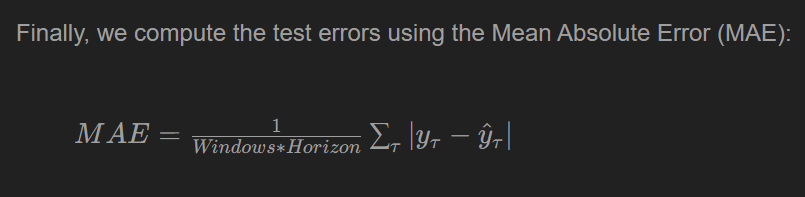

In [ ]:
#Evaluation using Mean Absolute Error
eval_df = evaluate(
    df=cv_df.drop(columns=["cutoff"]),
    metrics=[mae],
    agg_fn="mean"
)

print('Informer: ', eval_df.iloc[0]["Informer"])
print('Autoformer: ', eval_df.iloc[0]["Autoformer"])
print('PatchTST: ', eval_df.iloc[0]["PatchTST"])

## HYBRID FORECASTING MODEL


In [ ]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from keras.models import Sequential
from keras.layers import LSTM, Dense
import numpy as np

# Fit ARIMA
arima_model = ARIMA(series, order=(0,3,2))
arima_fit = arima_model.fit()
arima_pred = arima_fit.forecast(steps=15)


In [ ]:
"""# Preparing data for LSTM
values = series.values.reshape(-1, 1)
X, y = values[:-1], values[1:]
X = X.reshape((X.shape[0], 1, X.shape[1]))"""

In [ ]:
#LSTM FOR SECOND MODEL FOR HYBRID ARCHITECTURE
lstm_model = Sequential()
lstm_model.add(LSTM(5, input_shape=(1, 1)))
lstm_model.add(Dense(1))
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X, y, epochs=50, batch_size=72, verbose=0)

In [ ]:
#for prediction of X using LSTM
lstm_pred = lstm_model.predict(X)

In [ ]:
# Hybrid architecture where
hybrid_pred = []
actual = series[-15:].values
for a, l, act in zip(arima_pred, lstm_pred.flatten(), actual):
hybrid_pred.append(a if abs(a - act) < abs(l - act) else l)

###Volatility CLustering and Garch+ARCH on variance prediction

Volatility is a key metric in time series analysis which measures the variations present in the dataset to better understand the future fluctuations. It can be used in various domains like Weather, customer sales, financial analysis, etc.

Here, I'm calculating monthly fluctuations of shipments or bags, with days= 30/31 or 28/29 for february, that is,monthly count without any holiday.

For financial analysis, one can consider monthly count of 21 days and total of 252 for annual count.

In [ ]:
#For daily fluctuations
std_cv_df= cv_df["y"].std()
print("Daily Fluctuations are ", round(std_cv_df, 1)"%")

#For monthly fluctuations through above standard deviation
month_std_cv_df= np.sqrt(31)*std_cv_df
#For trading, there are approximately 21 trading days in a month, replace 31 with 21
print("Monthly Fluctuations are ", round(month_std_cv_df,1)"%")

#For annual fluctuations through above standard deviation
annual_std_cv_df= np.sqrt(365)* month_std_cv_df
#For trading, there are approximately 252 trading days in an year, replace 365 with 252
print("Annual Fluctuations are ", round(annual_std_cv_df,1)"%")

In [ ]:
!pip install arch

####Understanding the volatility dynamics from the above dataset using below models.

In [ ]:
#Defining the Arch model with q=0
arch= arch_model(cv_df["y"], p=1, q=0, vol="ARCH", dist="normal")

#Fitting the model
arch_fit= arch.fit(update_freq=4) #Fitting process upgrades with 4 iterations

#Displaying the necessary details
print(arch_fit.summary())

Above,

--dist='normal': Assumes that the residuals follow a normal distribution.


In [ ]:
#Defining the Garch model with p=1, q=1 i.e. GARCH(1,1)
garch= arch_model(cv_df["y"], p=1, q=1, vol="GARCH", dist="skewed")

#Fitting the model
garch_fit= arch.fit(update_freq=4) #Ftting process upgrades with 4 iterations

#Displaying the necessary details
print(garch_fit.summary())

In [ ]:
# Defining and fitting the EGARCH(1, 1) model
# includes exponential and considers the logarithm of volatility,
# allowing for asymmetric negative and positive shock effects
egarch = arch_model(returns, vol='EGARCH', p=1, q=1)
egarch_fit = egarch.fit()

# Displaying the necessary details
print(egarch_fit.summary())

In [ ]:
# Defining and fitting the TARCH(1, 1) model-
# that includes threshold along with previous parameters from above model
tarch = arch_model(returns, vol='TARCH', p=1, q=1)
tarch_fit = tarch.fit()

# Printing the model summary
print(tarch_fit.summary())

This process provides insights into the volatility structure of the financial returns data and allows us to understand how past returns and past volatility influence current volatility. The model results will include key statistics and diagnostics that can be used to assess the fit and validity of the model.

It can be use in various applications like risk management, portfolio optimization, and forecasting future volatility.

In [ ]:
#Visualization of fitted model to understand the volatility dynamics(ARCH)
arch_plot= arch_fit.plot(annualize="D")
arch_plot.set_dpi(750)  # Setting the DPI for the entire figure
plt.show()

In [ ]:
#Visualization of fitted model to understand the volatility dynamics(GARCH)
garch_plot= garch_fit.plot(annualize="D")
garch_plot.set_dpi(750)
plt.show()

In [ ]:
#Visualization of fitted model to understand the volatility dynamics(GARCH)
egarch_plot= egarch_fit.plot(annualize="D")
egarch_plot.set_dpi(750)
plt.show()

In [ ]:
#Visualization of fitted model to understand the volatility dynamics(GARCH)
tarch_plot= tarch_fit.plot(annualize="D")
tarch_plot.set_dpi(750)
plt.show()

##Getting volatility forecasts from ARCH, GARCH, EGARCH and TARCH Model

In [ ]:
# Get volatility forecasts using ARCH fitted model
arch_forecast_volatility = arch_fit.forecast(horizon=7)

# Print the forecast variance
print(arch_forecast_volatility.variance)

In [ ]:
# Get volatility forecasts using GARCH fitted model
garch_forecast_volatility = garch_fit.forecast(horizon=7)

# Print the forecast variance
print(garch_forecast_volatility.variance)

In [ ]:
# Get volatility forecasts using EGARCH fitted model
egarch_forecast_volatility = egarch_fit.forecast(horizon=7)

# Print the forecast variance
print(egarch_forecast_volatility.variance)

In [ ]:
# Get volatility forecasts using TARCH fitted model
tarch_forecast_volatility = tarch_fit.forecast(horizon=7)

# Print the forecast variance
print(tarch_forecast_volatility.variance)

###Comparison of volatility using above models

In [ ]:
# Conditional volatility of the ARCH(1) model
arch_model_fit = arch_model(returns, vol='ARCH', p=1).fit()
arch_vol = arch_model_fit.conditional_volatility

# Conditional volatility of the GARCH(1, 1) model
garch_model_fit = arch_model(returns, vol='GARCH', p=1, q=1).fit()
garch_vol = garch_model_fit.conditional_volatility

# Conditional volatility of the EGARCH(1, 1) model
egarch_model_fit = arch_model(returns, vol='EGARCH', p=1, q=1).fit()
egarch_vol = egarch_model_fit.conditional_volatility

# Conditional volatility of the EGARCH(1, 1) model
tarch_model_fit = arch_model(returns, vol='TARCH', p=1, q=1).fit()
tarch_vol = tarch_model_fit.conditional_volatility

# Visualizing the volatilities
plt.figure(figsize=(10, 6))
plt.plot(arch_vol, label='ARCH(1)')
plt.plot(garch_vol, label='GARCH(1,1)')
plt.plot(egarch_vol, label='EGARCH(1,1)')
plt.plot(tarch_vol, label="TARCH(1,1)")
plt.legend()
plt.title('Volatility Forecasts using ARCH, GARCH, EGARCH  and TARCH Models')
plt.show()

## Transformations and adjustments in Time series data:
1. Calendar adjustment
2. Population adjustment
3. Inflation adjustment
4. Mathematical adjustment

## LLM for time series analysis and prediction

In [ ]:
!pip install openai

In [ ]:
import os
from openai import OpenAI
def conclude_llm(prompt, model="gpt-4.1-mini"):
    """
    Sends a single-user-message prompt to the Responses API and returns text.
    Switching 'model' to any available text model in your account.
    """
    api_key = os.getenv("OPENAI_API_KEY")
    if not api_key:
        print("Set OPENAI_API_KEY to enable LLM calls. Skipping.")
        return None
    client = OpenAI(api_key=api_key)
    resp = client.responses.create(
        model=model,
        input=[{"role": "user", "content": prompt_text}]
    )
    return getattr(resp, "output_text", None)

In [ ]:
diagnose= f"""
Perform well diagnostic exploratory analysis on my above forecasts
Provide Explaination on:
1. Business Validation:
   - Economic significance of forecasts
   - Directional accuracy
   - Peak/trough prediction capability
   - Trend change detection
2. Interpretability:
   - Feature importance (for ML models)
   - Component analysis (for decomposition models)
   - Attention weights (for transformer models)"""
llm_summary = conclude_llm(diagnose)
print(llm_summary or "(LLM call skipped)")

### Trial tips to consider in time series dataset:
1. If one is modeling things like sales, with a natural maximum, consider either using the SME Forecast tools of <b>put bounds</b> on the forecast,

e.g., Model the Series as: Sales[t]= MIN(S[t], Max[t])

2. If one want to model a shock(e.g., a competitor enters the market), make a flag using a <b>multinomial (1,{p}) </b>, to show where the shock will occur and add its effect.

3. To add seasonality, take a mean trend with volatility, and multiply by seasonal factors that <b>average to 1</b>. To estimate them(bit rough manner), take:

e.g., the average of historic January values and divide by the average of all values.

####*** Lead indicators are variables that change faster to the underlying independent variable that two series are affected by. One can use them to give a short-term advantage in forecasting.***

# Summary on Time Series forecasting process

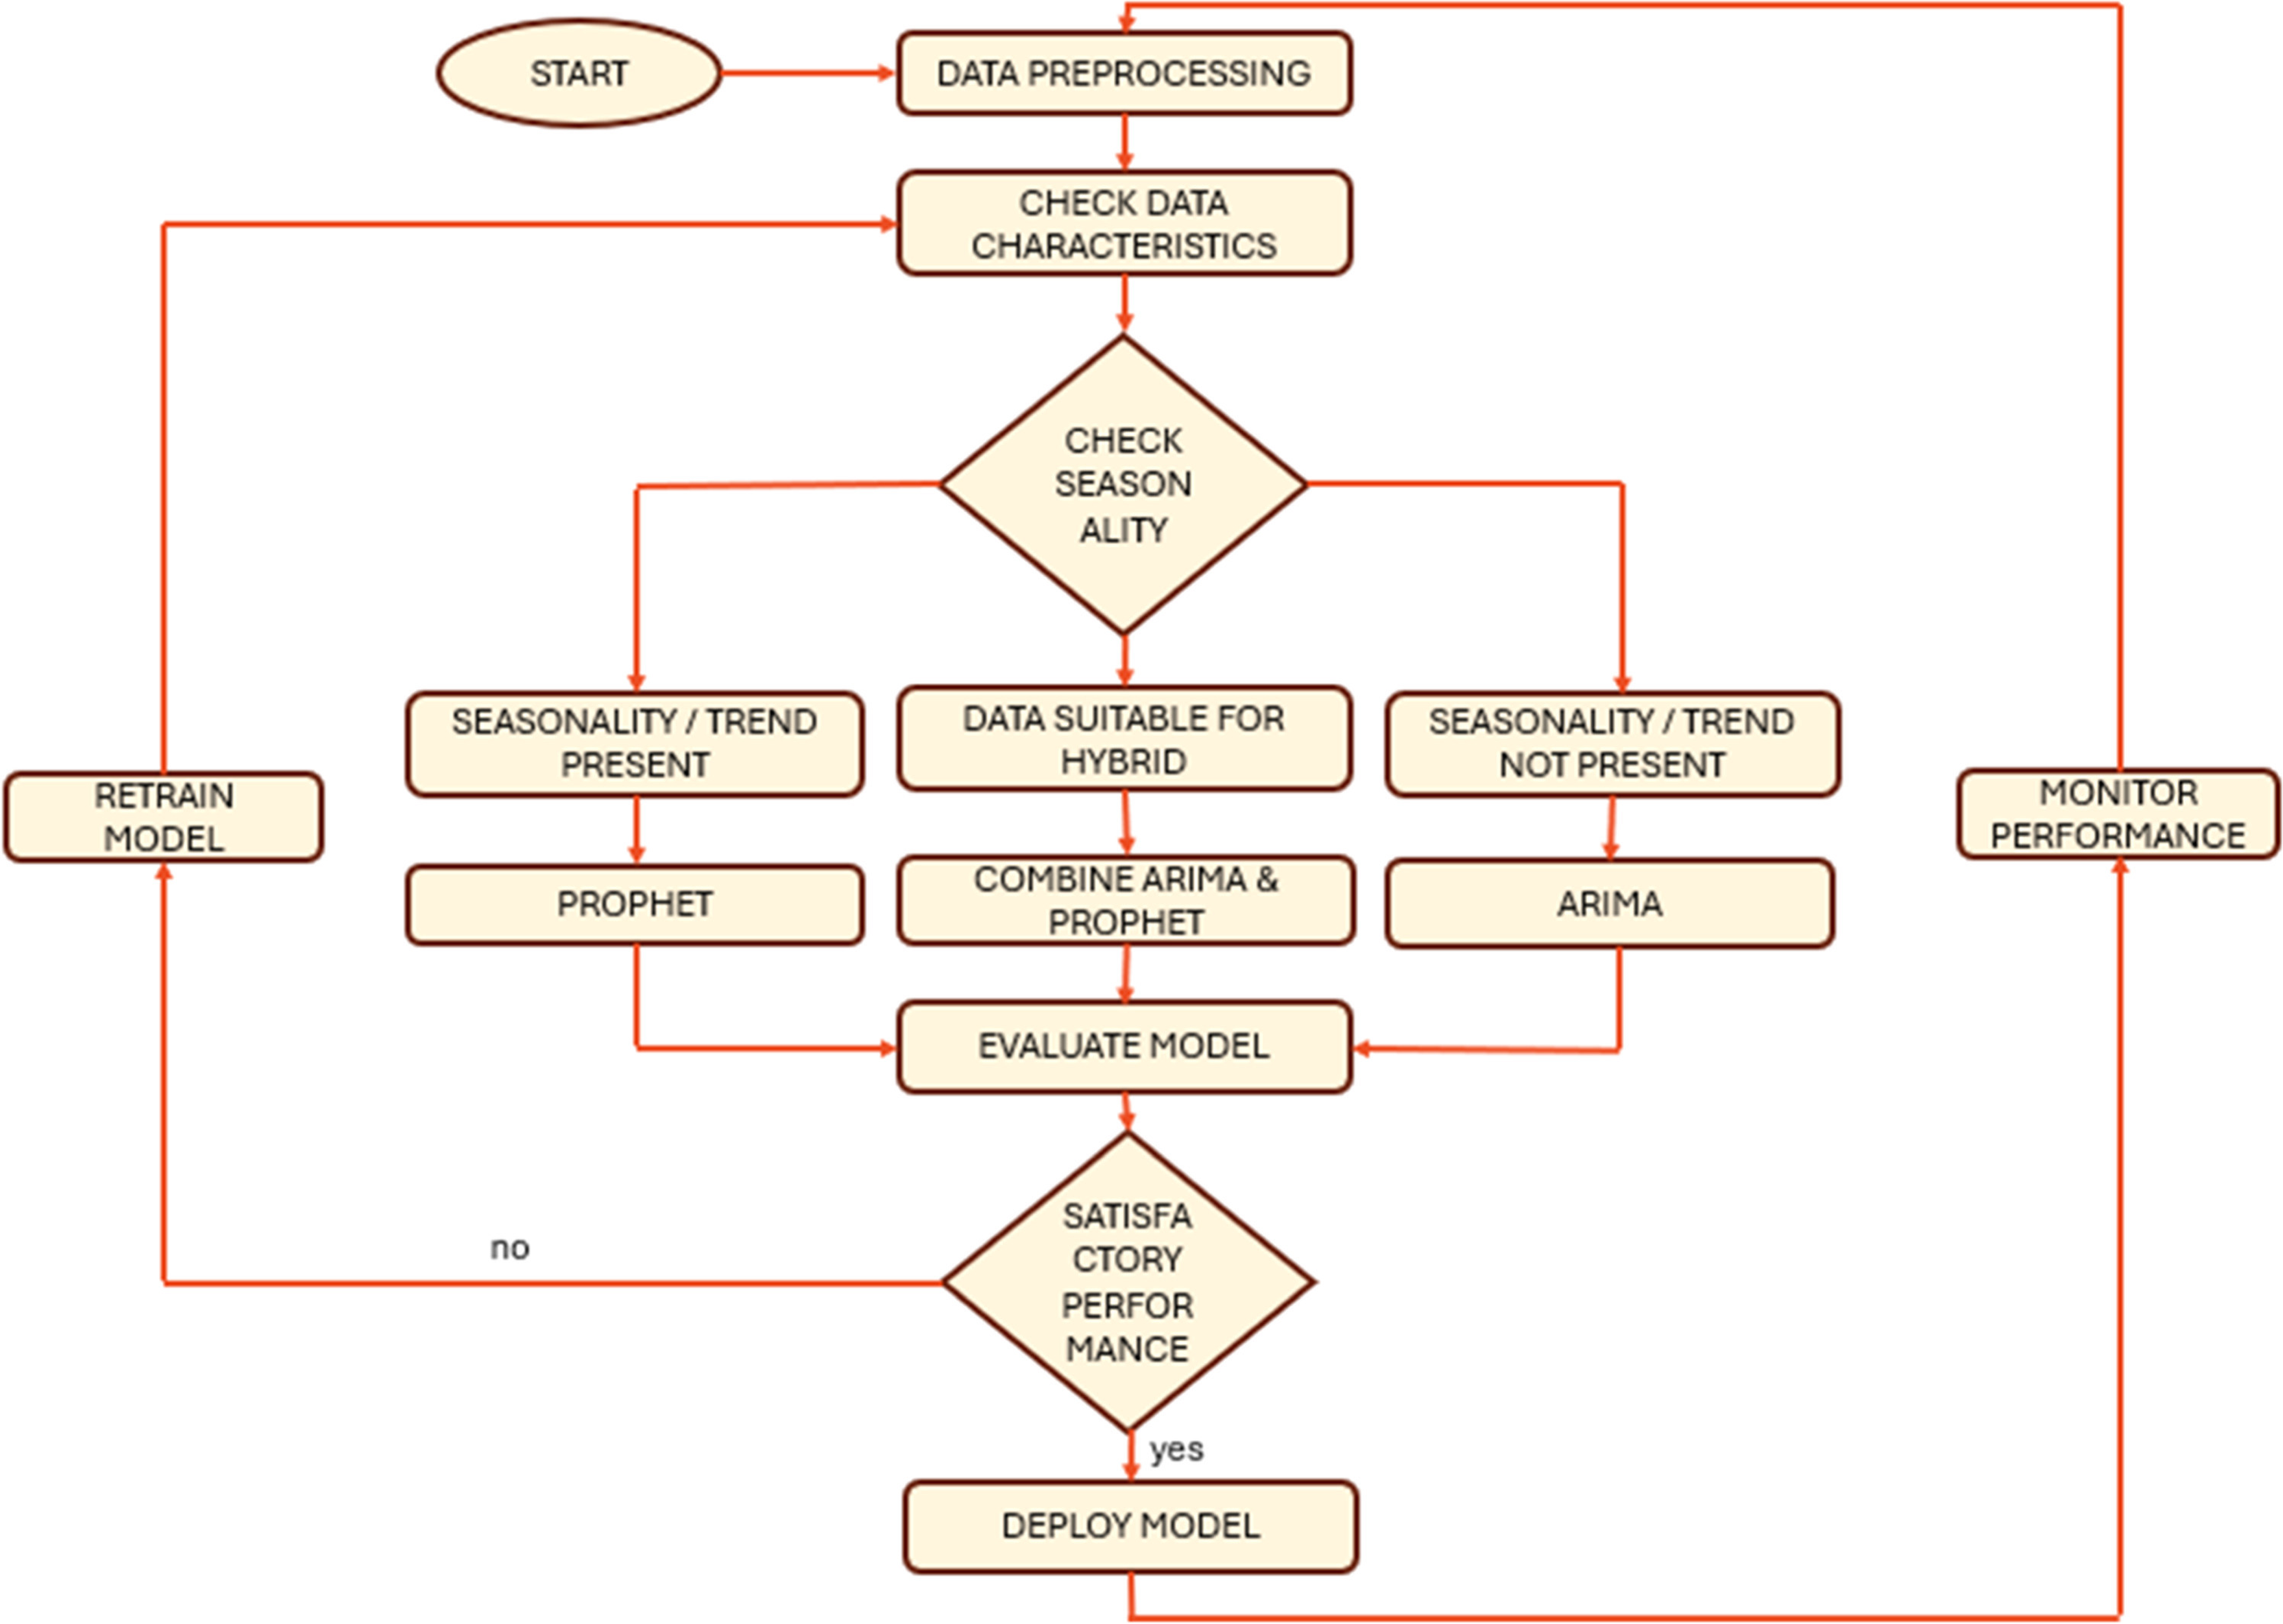